#Advanced Analytics & MAchine Learning using IQVIA EGYPT Market DATA (2021-2025)

In [203]:
import pandas as pd

In [204]:
import numpy as np

pd.set_option ("display.max_columns" ,None)

In [205]:
df=  pd.read_excel ("IMS (2021-2025).xlsx")

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909922 entries, 0 to 909921
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Sector         909922 non-null  object        
 1   ATC4           909922 non-null  object        
 2   Corporation    909922 non-null  object        
 3   Product        909922 non-null  object        
 4   Pack           909922 non-null  object        
 5   Launch Date    909922 non-null  object        
 6   Strength       909922 non-null  object        
 7   Retail Price   909922 non-null  float64       
 8   NFC3           909922 non-null  object        
 9   Period         909922 non-null  datetime64[ns]
 10  Calendar Year  909922 non-null  int64         
 11  Units          909922 non-null  float64       
 12  LC Value       909922 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 90.2+ MB


In [217]:
df.columns

Index(['Distribution Channel', 'Therapeutic Class', 'Manufacturer',
       'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength',
       'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units',
       'Sales Value'],
      dtype='object')

In [218]:
df.shape

(909922, 13)

In [219]:
df.head()

,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value
0,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-01-01,2021,124790.0,1871850.0
1,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-02-01,2021,112962.0,1694430.0
2,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-03-01,2021,108014.0,1620210.0
3,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-04-01,2021,88090.0,1321350.0
4,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-05-01,2021,76111.0,1141665.0


In [220]:
df.tail()

,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value
909917,STORES,V07A0 OTHER NON-THERAPEUTIC,WESTE.MEDICAL CA*,NO CAL,SACHETS POWD 50 1G,2010/05,000,76.0,DEP ORAL L ORD UNIT DOSE POWDERS,2023-04-01,2023,1.0,57.0
909918,STORES,V07A0 OTHER NON-THERAPEUTIC,WESTE.MEDICAL CA*,NO CAL,SACHETS POWD 50 1G,2010/05,000,76.0,DEP ORAL L ORD UNIT DOSE POWDERS,2023-05-01,2023,6.0,342.0
909919,STORES,V07A0 OTHER NON-THERAPEUTIC,WESTE.MEDICAL CA*,NO CAL,SACHETS POWD 50 1G,2010/05,000,76.0,DEP ORAL L ORD UNIT DOSE POWDERS,2023-08-01,2023,4.0,228.0
909920,STORES,V07A0 OTHER NON-THERAPEUTIC,WESTE.MEDICAL CA*,NO CAL,SACHETS POWD 50 1G,2010/05,000,76.0,DEP ORAL L ORD UNIT DOSE POWDERS,2023-09-01,2023,1.0,57.0
909921,STORES,V07A0 OTHER NON-THERAPEUTIC,WESTE.MEDICAL CA*,NO CAL,SACHETS POWD 50 1G,2010/05,000,76.0,DEP ORAL L ORD UNIT DOSE POWDERS,2024-02-01,2024,12.0,780.0


In [221]:
df.describe (include ="all")

,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value
count,909922,909922,909922,909922,909922,909922,909922,909922.000000,909922,909922,909922.000000,9.099220e+05,9.099220e+05
unique,2,513,1396,9958,8835,469,459,NaN,209,NaN,NaN,NaN,NaN
top,PHARMACIES,M01A1 ANTIRHEUMATICS NON-S PLN,PHARCO*,HERO BABY FOOD,SYRUP 120ML,No Launch Date,000,NaN,ABC ORAL S ORD FILM-COATED TABS,NaN,NaN,NaN,NaN
freq,540117,24986,34534,2349,10649,9335,280100,NaN,185866,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,652.735979,NaN,2023-06-30 02:11:28.901246208,2023.034219,1.682607e+04,9.702826e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,2021-01-01 00:00:00,2021.000000,3.000000e-02,1.000000e-02
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,2022-04-01 00:00:00,2022.000000,1.020000e+02,6.800000e+03
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.000000,NaN,2023-07-01 00:00:00,2023.000000,1.047000e+03,6.936600e+04
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160.000000,NaN,2024-10-01 00:00:00,2024.000000,7.462000e+03,4.821098e+05
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,375504.000000,NaN,2025-12-01 00:00:00,2025.000000,6.080044e+06,2.679121e+08


In [222]:
df.isnull().sum()

Distribution Channel    0
Therapeutic Class       0
Manufacturer            0
Brand Name              0
Pack Size               0
Product Launch          0
Drug Strength           0
Selling Price           0
Market Category         0
Month                   0
Year                    0
Sales Units             0
Sales Value             0
dtype: int64

In [223]:
df.duplicated().sum()

np.int64(0)

In [224]:
df.nunique()

Distribution Channel         2
Therapeutic Class          513
Manufacturer              1396
Brand Name                9958
Pack Size                 8835
Product Launch             469
Drug Strength              459
Selling Price             1999
Market Category            209
Month                       60
Year                         5
Sales Units             142846
Sales Value             408017
dtype: int64

In [225]:
df = df.rename(columns={
    "Sector": "Distribution Channel",
    "ATC4": "Therapeutic Class",
    "Corporation": "Manufacturer",
    "Product": "Brand Name",
    "Pack": "Pack Size",
    "Launch Date": "Product Launch",
    "Strength": "Drug Strength",
    "Retail Price": "Selling Price",
    "NFC3": "Market Category",
    "Period": "Month",
    "Calendar Year": "Year",
    "Units": "Sales Units",
    "LC Value": "Sales Value"
})

In [226]:
df.columns

Index(['Distribution Channel', 'Therapeutic Class', 'Manufacturer',
       'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength',
       'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units',
       'Sales Value'],
      dtype='object')

# Data Dictionary

The dataset contains monthly pharmaceutical sales data in Egypt (2021–2025).

| Column | Description |
|---------|-------------|
| Distribution Channel | Sales channel (e.g., Pharmacies) |
| Therapeutic Class | ATC therapeutic classification |
| Manufacturer | Pharmaceutical company |
| Brand Name | Drug brand |
| Pack Size | Product package size |
| Product Launch | Product launch date |
| Drug Strength | Active ingredient strength |
| Selling Price | Retail selling price |
| Market Category | Market category |
| Month | Monthly reporting period |
| Year | Calendar year |
| Sales Units | Number of units sold |
| Sales Value | Sales revenue in local currency |

In [227]:
df.describe()

,Selling Price,Month,Year,Sales Units,Sales Value
count,909922.000000,909922,909922.000000,9.099220e+05,9.099220e+05
mean,652.735979,2023-06-30 02:11:28.901246208,2023.034219,1.682607e+04,9.702826e+05
min,0.010000,2021-01-01 00:00:00,2021.000000,3.000000e-02,1.000000e-02
25%,40.000000,2022-04-01 00:00:00,2022.000000,1.020000e+02,6.800000e+03
50%,78.000000,2023-07-01 00:00:00,2023.000000,1.047000e+03,6.936600e+04
75%,160.000000,2024-10-01 00:00:00,2024.000000,7.462000e+03,4.821098e+05
max,375504.000000,2025-12-01 00:00:00,2025.000000,6.080044e+06,2.679121e+08
std,6548.015532,NaN,1.419715,6.995553e+04,3.734752e+06


# Market Overview

The following analysis provides an overview of the Egyptian pharmaceutical market by identifying the largest manufacturers, leading therapeutic classes, and highest-selling products.

In [228]:
top_companies = (
    df.groupby("Manufacturer")["Sales Value"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

top_companies

Manufacturer
PHARCO*             4.286563e+10
SANOFI              3.950244e+10
AMOUN PHARM.CO.*    3.176665e+10
NOVARTIS            2.979254e+10
EIPICO/ACDIMA       2.639026e+10
GLAXOSMITHKLINE*    2.461002e+10
EVA PHARMA*         2.406643e+10
MARCYRL*            2.244227e+10
APEX PHARMA*        2.048389e+10
AUG PHARMA*         2.046888e+10
ASTRAZENECA*        1.979251e+10
HIKMA PLC*          1.976784e+10
MUP/ACDIMA          1.800874e+10
ABBOTT*             1.727482e+10
HALEON*             1.722433e+10
GLOBAL NAPI*        1.643821e+10
RAMEDA*             1.538050e+10
NOVO NORDISK*       1.448079e+10
PFIZER*             1.425342e+10
HORUS*              1.338934e+10
Name: Sales Value, dtype: float64

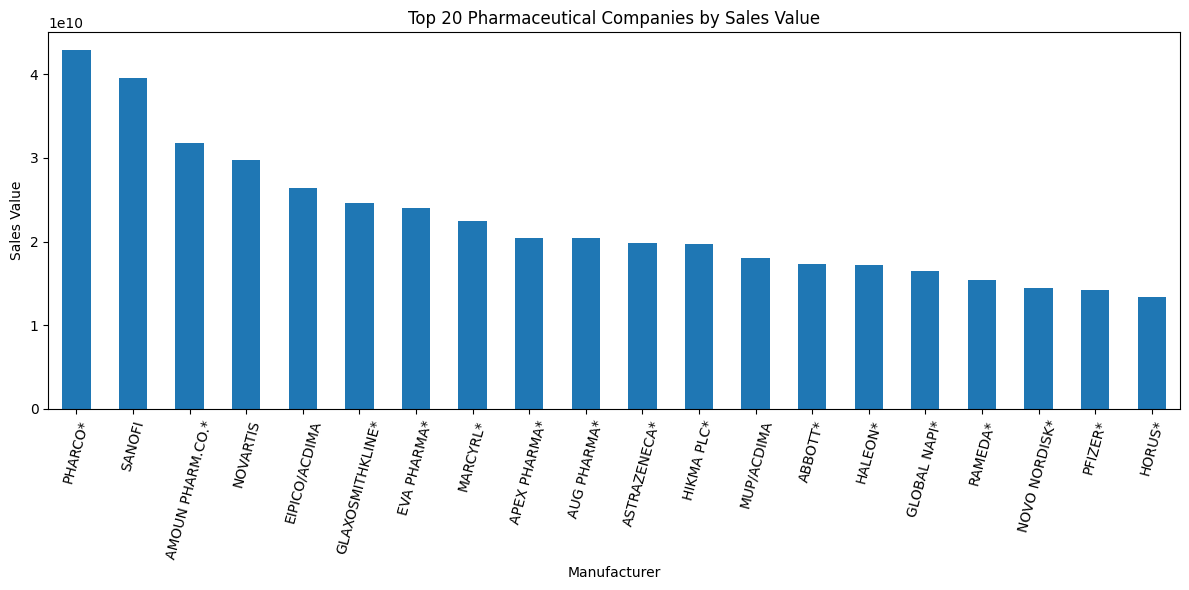

In [229]:
import matplotlib.pyplot as plt

top_companies.plot(kind="bar", figsize=(12,6))

plt.title("Top 20 Pharmaceutical Companies by Sales Value")
plt.xlabel("Manufacturer")
plt.ylabel("Sales Value")

plt.xticks(rotation=75)

plt.tight_layout()

plt.show()

#Manufacture Analysis

In [230]:
manufacturer_sales = (
    df.groupby("Manufacturer", as_index=False)["Sales Value"]
      .sum()
      .sort_values(by="Sales Value", ascending=False)
)

manufacturer_sales.head(20)

,Manufacturer,Sales Value
991,PHARCO*,4.286563e+10
1157,SANOFI,3.950244e+10
97,AMOUN PHARM.CO.*,3.176665e+10
901,NOVARTIS,2.979254e+10
382,EIPICO/ACDIMA,2.639026e+10
498,GLAXOSMITHKLINE*,2.461002e+10
431,EVA PHARMA*,2.406643e+10
759,MARCYRL*,2.244227e+10
105,APEX PHARMA*,2.048389e+10
147,AUG PHARMA*,2.046888e+10


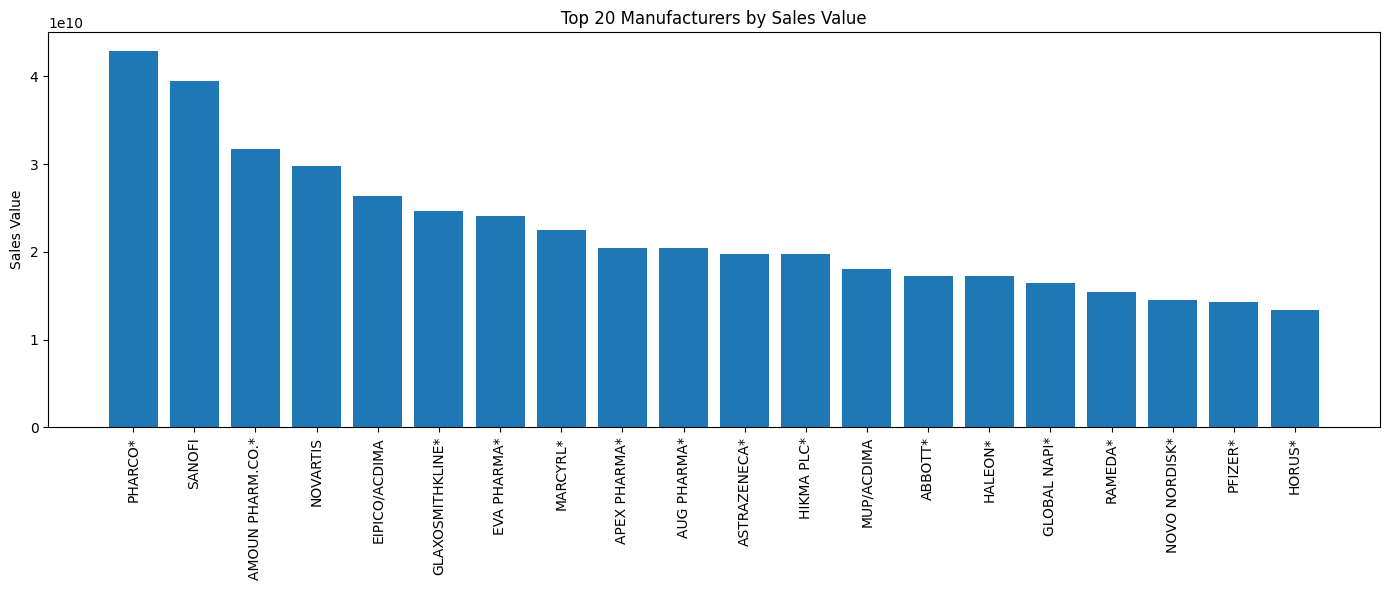

In [231]:
plt.figure(figsize=(14,6))

plt.bar(
    manufacturer_sales.head(20)["Manufacturer"],
    manufacturer_sales.head(20)["Sales Value"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Manufacturers by Sales Value")

plt.ylabel("Sales Value")

plt.tight_layout()

plt.show()

#Market Share

In [232]:
manufacturer_sales["Market Share %"] = (
    manufacturer_sales["Sales Value"]
    / manufacturer_sales["Sales Value"].sum()
) * 100

manufacturer_sales.head(10)

,Manufacturer,Sales Value,Market Share %
991,PHARCO*,4.286563e+10,4.855197
1157,SANOFI,3.950244e+10,4.474263
97,AMOUN PHARM.CO.*,3.176665e+10,3.598065
901,NOVARTIS,2.979254e+10,3.374466
382,EIPICO/ACDIMA,2.639026e+10,2.989105
498,GLAXOSMITHKLINE*,2.461002e+10,2.787465
431,EVA PHARMA*,2.406643e+10,2.725896
759,MARCYRL*,2.244227e+10,2.541935
105,APEX PHARMA*,2.048389e+10,2.320118
147,AUG PHARMA*,2.046888e+10,2.318417


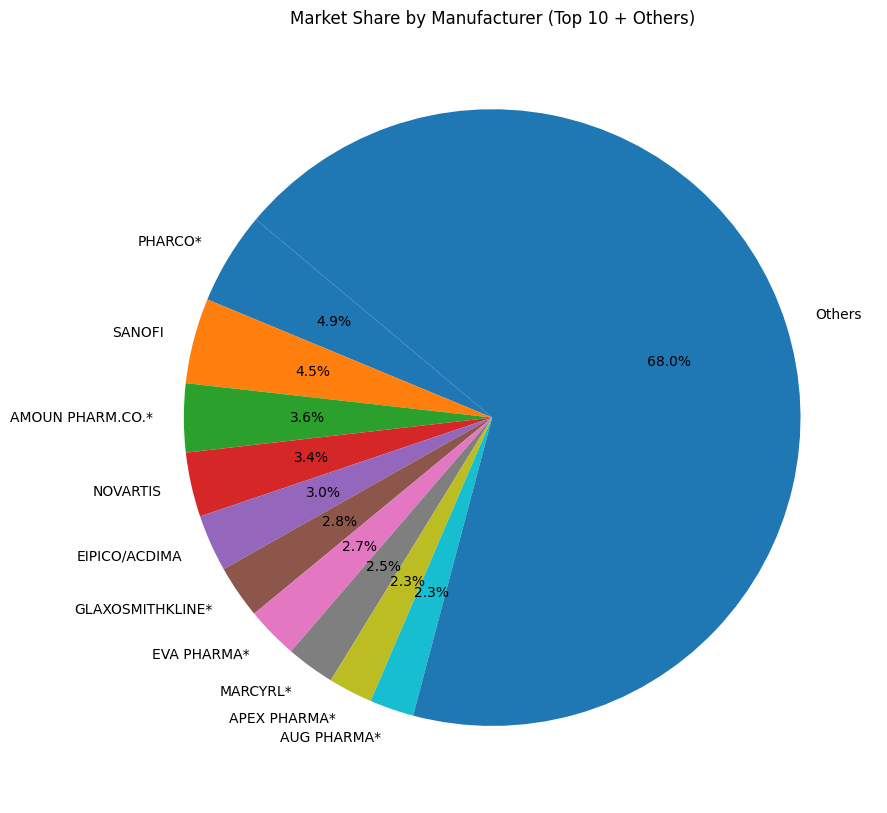

In [233]:
# Top 10 manufacturers
top10 = manufacturer_sales.head(10).copy()

# Others
others = manufacturer_sales["Sales Value"].iloc[10:].sum()

# Add Others row
top10.loc[len(top10)] = ["Others", others, top10["Market Share %"].sum()*0]  # placeholder

# Recalculate market share
top10["Market Share %"] = (
    top10["Sales Value"] /
    top10["Sales Value"].sum()
) * 100

plt.figure(figsize=(9,9))

plt.pie(
    top10["Sales Value"],
    labels=top10["Manufacturer"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Market Share by Manufacturer (Top 10 + Others)")

plt.tight_layout()

plt.show()

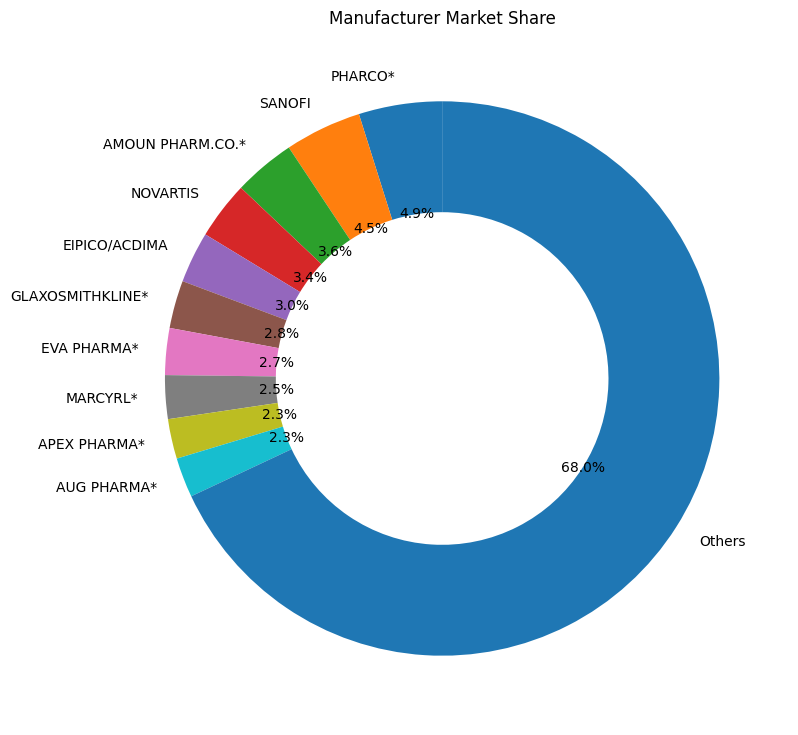

In [234]:
fig, ax = plt.subplots(figsize=(9,9))

wedges, texts, autotexts = ax.pie(
    top10["Sales Value"],
    labels=top10["Manufacturer"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

ax.set_title("Manufacturer Market Share")

plt.show()

### Business Insight

The pharmaceutical market is highly concentrated among a limited number of manufacturers.

The top manufacturers contribute a significant percentage of the total market sales, indicating strong competitive positioning and brand dominance.

#Therapeutic Class Analysis

In [235]:
therapeutic_sales = (
    df.groupby("Therapeutic Class", as_index=False)["Sales Value"]
      .sum()
      .sort_values(by="Sales Value", ascending=False)
)

therapeutic_sales.head(20)

,Therapeutic Class,Sales Value
10,A02B2 PROTON PUMP INHIBITORS,3.972055e+10
368,M01A1 ANTIRHEUMATICS NON-S PLN,3.286719e+10
252,J01C1 BROAD SPECT PENICILL ORAL,2.745757e+10
503,V06C1 INFANT MILKS,2.699717e+10
230,G04E1 ERECT DYS PRD PDE5 INHIB,2.122473e+10
255,J01D2 CEPHALOSPORINS INJECT,2.050337e+10
386,N02B0 NON-NARCOTIC ANALGESICS,1.998536e+10
390,N02D0 GABAPENTINOID PRODUCTS,1.577947e+10
257,J01F0 MACROLIDES & SIMILAR TYPE,1.361351e+10
454,R06A0 ANTIHISTAMINES SYSTEMIC,1.347208e+10


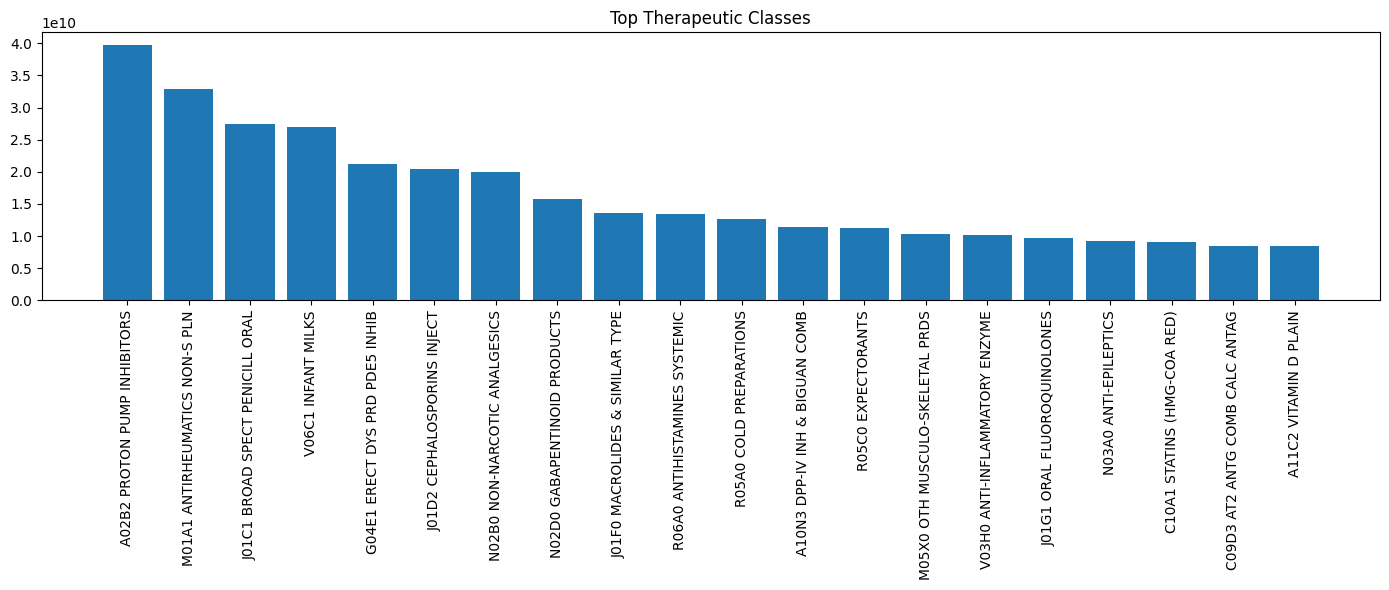

In [236]:
plt.figure(figsize=(14,6))

plt.bar(
    therapeutic_sales.head(20)["Therapeutic Class"],
    therapeutic_sales.head(20)["Sales Value"]
)

plt.xticks(rotation=90)

plt.title("Top Therapeutic Classes")

plt.tight_layout()

plt.show()

### Business Insight

Therapeutic classes are not equally distributed.

A small number of therapeutic categories account for the majority of pharmaceutical market value, highlighting the largest commercial opportunities.### Business Insight

Therapeutic classes are not equally distributed.

A small number of therapeutic categories account for the majority of pharmaceutical market value, highlighting the largest commercial opportunities.

# Commercial Analytics 
# Brand Analysis 

# Brand Performance Analysis

This section evaluates the best-performing pharmaceutical brands based on total sales value.

In [237]:
brand_sales = (
    df.groupby("Brand Name", as_index=False)["Sales Value"]
      .sum()
      .sort_values(by="Sales Value", ascending=False)
)

brand_sales.head(20)

,Brand Name,Sales Value
9941,ZURCAL,7.804095e+09
725,AUGMENTIN,6.813283e+09
2091,CONTROLOC,6.360948e+09
6857,PANADOL,6.048820e+09
1902,CLEXANE,5.555901e+09
3692,GABIMASH,5.308934e+09
1286,BRUFEN,5.189706e+09
4225,HIBIOTIC,5.093675e+09
2094,CONVENTIN,4.798667e+09
316,ALPHINTERN,4.095527e+09


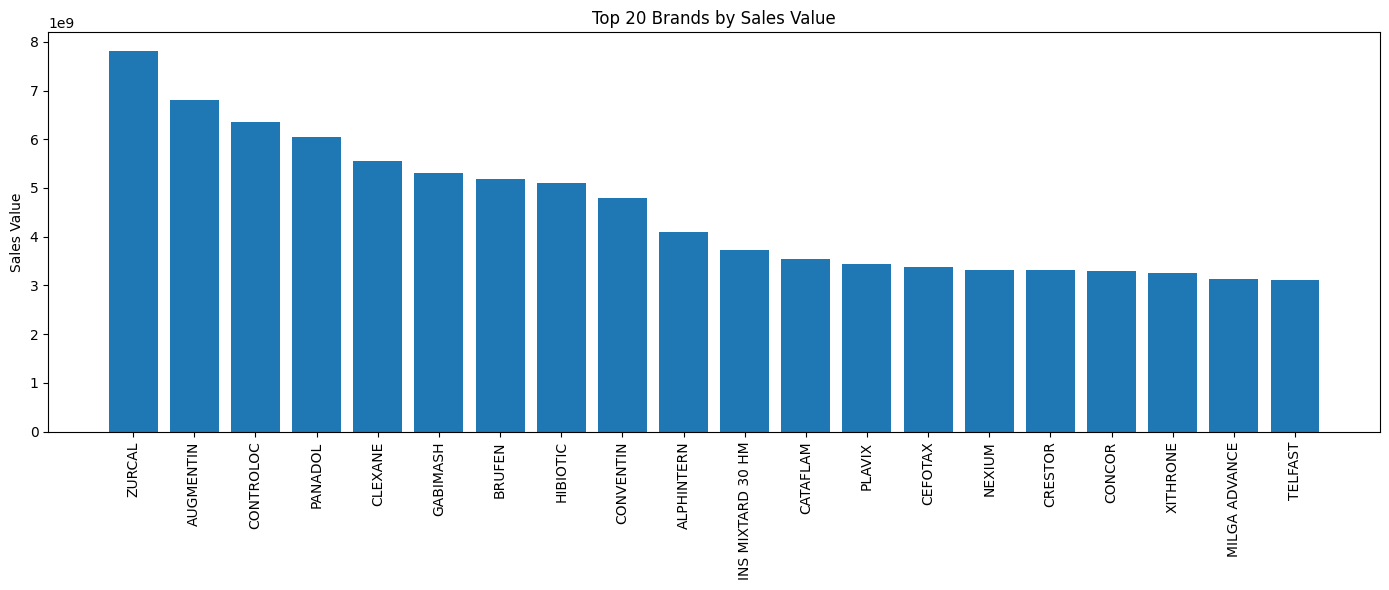

In [238]:
plt.figure(figsize=(14,6))

plt.bar(
    brand_sales.head(20)["Brand Name"],
    brand_sales.head(20)["Sales Value"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Brands by Sales Value")

plt.ylabel("Sales Value")

plt.tight_layout()

plt.show()

### Business Insight

A relatively small number of brands generate a large proportion of the total pharmaceutical market value.

These brands represent strategic products that significantly influence manufacturer performance and market competitiveness.

Distribution Channel Analysis

In [239]:
channel_sales = (
    df.groupby("Distribution Channel", as_index=False)["Sales Value"]
      .sum()
      .sort_values(by="Sales Value", ascending=False)
)

channel_sales

,Distribution Channel,Sales Value
0,PHARMACIES,6.142002e+11
1,STORES,2.686812e+11


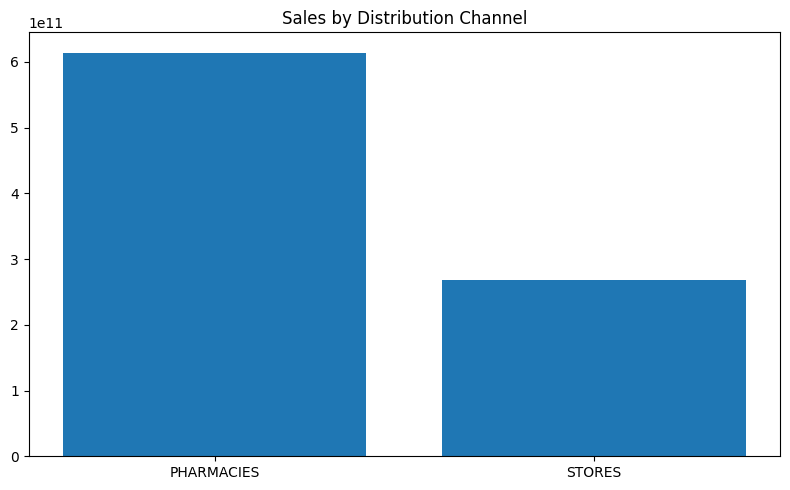

In [240]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_sales["Distribution Channel"],
    channel_sales["Sales Value"]
)

plt.title("Sales by Distribution Channel")

plt.tight_layout()

plt.show()

### Business Insight

Distribution channels contribute differently to pharmaceutical sales.

Understanding channel performance helps optimize sales strategy and resource allocation.

Product launch Analysis

In [241]:
df["Product Launch"].head(10)

0    1990/04
1    1990/04
2    1990/04
3    1990/04
4    1990/04
5    1990/04
6    1990/04
7    1990/04
8    1990/04
9    1990/04
Name: Product Launch, dtype: object

In [242]:
df["Product Launch Date"] = pd.to_datetime(df["Product Launch"], 
                                      format = "%Y/%m",
                                      errors= "coerce")

In [243]:
df["Launch Year"] = df["Product Launch Date"].dt.year

In [244]:
df["Product Launch Date"].value_counts().head(20)

Product Launch Date
2015-08-01    8540
2021-11-01    8010
2019-01-01    7630
2021-08-01    6405
2021-04-01    6367
2024-01-01    5853
2019-10-01    5697
2021-12-01    5681
2020-10-01    5673
2022-09-01    5415
2015-04-01    5254
2014-01-01    5226
2022-06-01    5140
2021-05-01    5001
2023-01-01    4951
2020-08-01    4951
2011-04-01    4891
2021-03-01    4717
2008-11-01    4691
2022-01-01    4680
Name: count, dtype: int64

In [245]:
df["Launch Year"].head()

0    1990.0
1    1990.0
2    1990.0
3    1990.0
4    1990.0
Name: Launch Year, dtype: float64

In [246]:
launches = (
    df.groupby("Launch Year")
      .size()
      .reset_index(name="Number of Products")
)

launches

,Launch Year,Number of Products
0,1977.0,314
1,1978.0,686
2,1979.0,1200
3,1980.0,938
4,1981.0,1363
5,1982.0,1696
6,1983.0,1843
7,1984.0,477
8,1985.0,4245
9,1986.0,2185


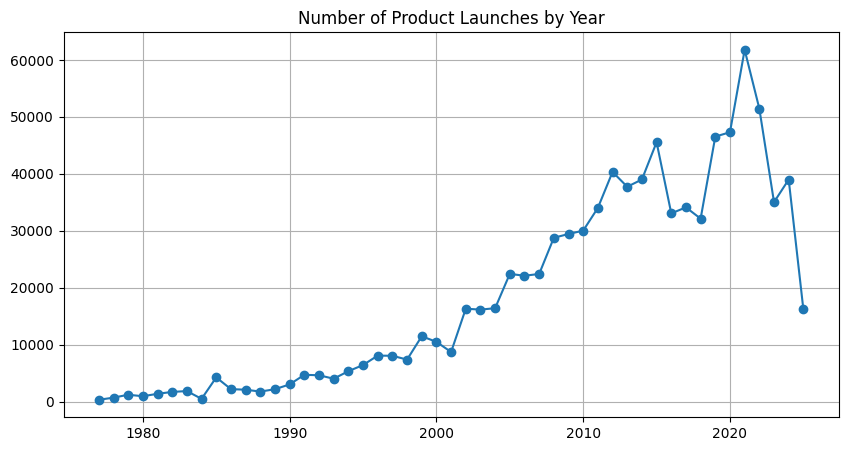

In [247]:
plt.figure(figsize=(10,5))

plt.plot(
    launches["Launch Year"],
    launches["Number of Products"],
    marker="o"
)

plt.title("Number of Product Launches by Year")

plt.grid(True)

plt.show()

### Business Insight

Product launch activity varies across years.

Monitoring launch trends helps evaluate innovation cycles and competitive intensity within the pharmaceutical market.

# Monthly Sales Trend

This analysis evaluates the monthly pharmaceutical market performance over the study period.

The objective is to identify seasonality, growth patterns, and unusual fluctuations in total market sales.

In [248]:
monthly_sales = (
    df.groupby("Month", as_index=False)["Sales Value"]
      .sum()
      .sort_values("Month")
)

monthly_sales.head()

,Month,Sales Value
0,2021-01-01,7.838593e+09
1,2021-02-01,7.254915e+09
2,2021-03-01,8.702145e+09
3,2021-04-01,7.727591e+09
4,2021-05-01,8.863685e+09


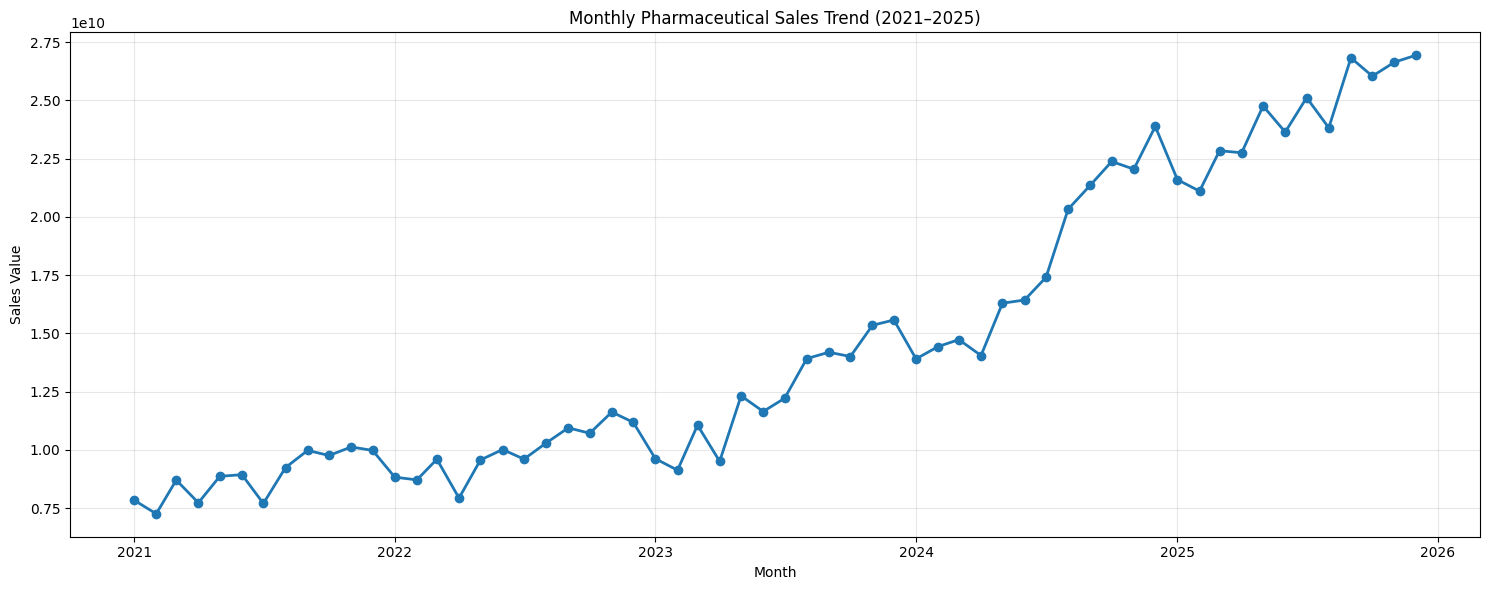

In [249]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales Value"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Pharmaceutical Sales Trend (2021–2025)")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [250]:
monthly_units = (
    df.groupby("Month", as_index=False)["Sales Units"]
      .sum()
      .sort_values("Month")
)

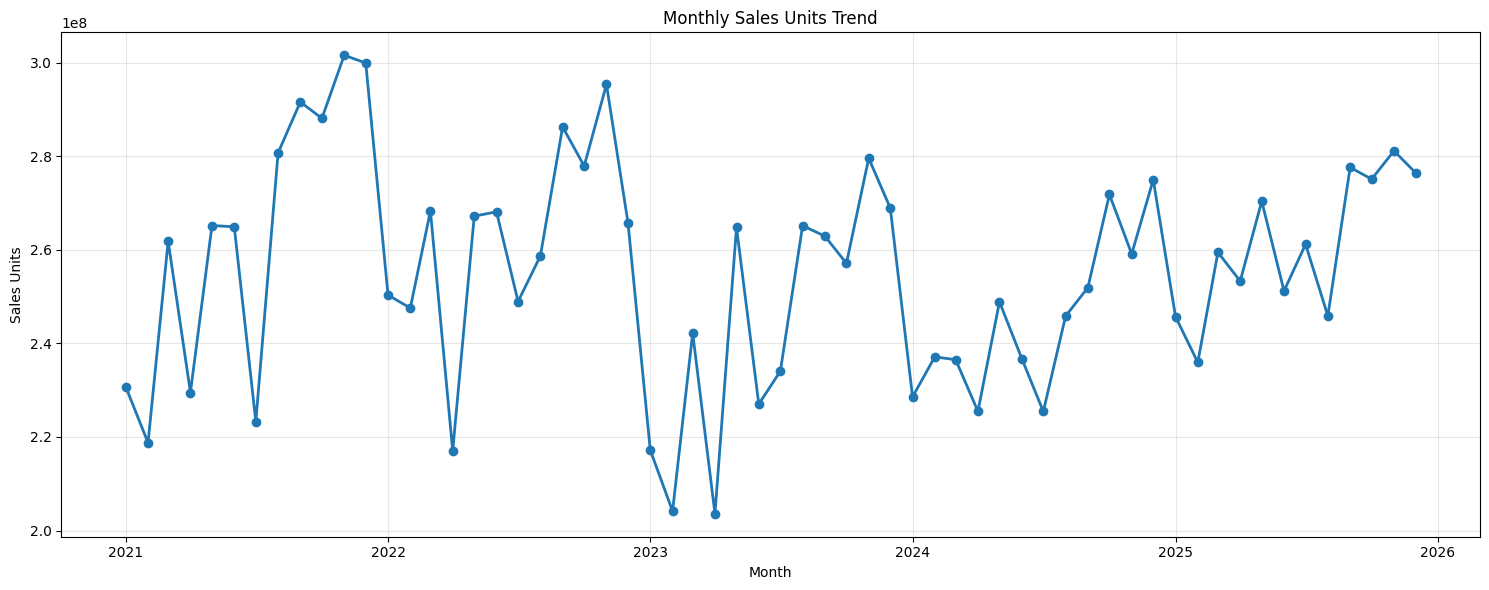

In [251]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_units["Month"],
    monthly_units["Sales Units"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Units Trend")
plt.xlabel("Month")
plt.ylabel("Sales Units")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [252]:
yearly_sales = (
    df.groupby("Year", as_index=False)["Sales Value"]
      .sum()
      .sort_values("Year")
)

yearly_sales

,Year,Sales Value
0,2021,1.060877e+11
1,2022,1.189950e+11
2,2023,1.485131e+11
3,2024,2.172278e+11
4,2025,2.920578e+11


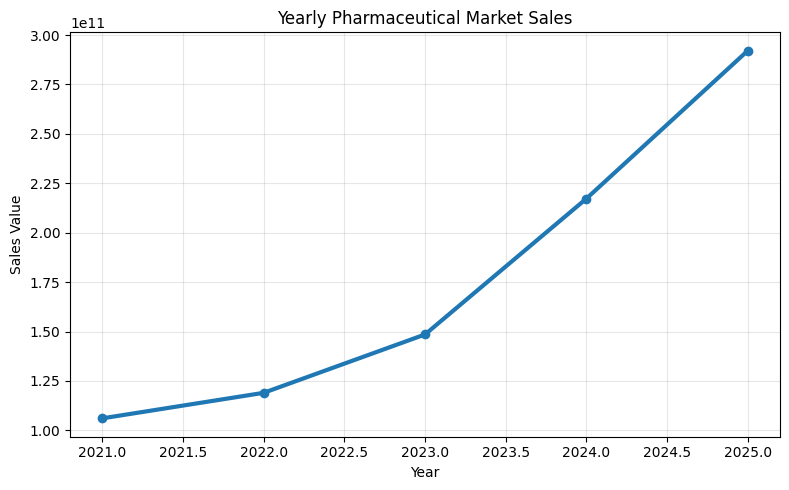

In [253]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Sales Value"],
    marker="o",
    linewidth=3
)

plt.title("Yearly Pharmaceutical Market Sales")
plt.xlabel("Year")
plt.ylabel("Sales Value")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#Commercial Analytics

In [254]:
market_yoy = (
    df.groupby("Year", as_index=False)["Sales Value"]
      .sum()
      .sort_values("Year")
)

market_yoy

,Year,Sales Value
0,2021,1.060877e+11
1,2022,1.189950e+11
2,2023,1.485131e+11
3,2024,2.172278e+11
4,2025,2.920578e+11


In [255]:
market_yoy["YoY Growth %"] = (
    market_yoy["Sales Value"]
    .pct_change() * 100
).round(2)

market_yoy

,Year,Sales Value,YoY Growth %
0,2021,1.060877e+11,NaN
1,2022,1.189950e+11,12.17
2,2023,1.485131e+11,24.81
3,2024,2.172278e+11,46.27
4,2025,2.920578e+11,34.45


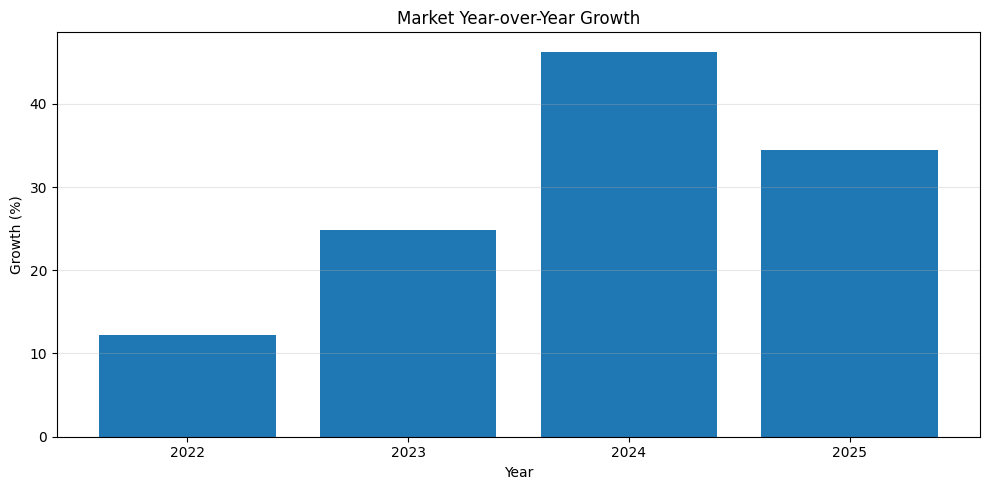

In [256]:
plt.figure(figsize=(10,5))

plt.bar(
    market_yoy["Year"].astype(str),
    market_yoy["YoY Growth %"]
)

plt.title("Market Year-over-Year Growth")

plt.xlabel("Year")

plt.ylabel("Growth (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Executive Insight

This analysis measures the annual growth rate of the Egyptian pharmaceutical market.

Positive values indicate market expansion, while negative values indicate market contraction.

In [257]:
manufacturer_year = (
    df.groupby(
        ["Year","Manufacturer"],
        as_index=False
    )["Sales Value"]
    .sum()
)

In [258]:
manufacturer_pivot = manufacturer_year.pivot(
    index="Manufacturer",
    columns="Year",
    values="Sales Value"
)

manufacturer_pivot.head()

Year,2021,2022,2023,2024,2025
Manufacturer,,,,,
15 MAY PHARMACEUTICAL,165100.0,49916.75,3185.0,26100.0,20600.0
2M WHITES,NaN,NaN,NaN,NaN,5035151.0
2MS PHARMA,NaN,NaN,NaN,NaN,13075.0
3A,NaN,NaN,NaN,NaN,360.0
4S PHARMA*,NaN,NaN,NaN,81345.0,160493.0


In [259]:
maufacturer_pivot =manufacturer_pivot.fillna(0)

In [260]:
manufacturer_yoy = (
    manufacturer_pivot
    .pct_change(axis=1 ,fill_method =None) * 100
).round(2)

manufacturer_yoy.head()

Year,2021,2022,2023,2024,2025
Manufacturer,,,,,
15 MAY PHARMACEUTICAL,NaN,-69.77,-93.62,719.47,-21.07
2M WHITES,NaN,NaN,NaN,NaN,NaN
2MS PHARMA,NaN,NaN,NaN,NaN,NaN
3A,NaN,NaN,NaN,NaN,NaN
4S PHARMA*,NaN,NaN,NaN,NaN,97.30


In [261]:
top_growth = (
    manufacturer_yoy[2025]
      .sort_values(ascending=False)
      .head(20)
)

top_growth

Manufacturer
LACTO MISR*          7394563.87
BROMED               1257000.00
GENOVEN ARAB DRS*     296490.91
SEDAR PHARMA*         250570.40
BIO-N                  39331.65
MEGA MED*              32400.00
ECAP*                  22397.32
BE WELL MEDICAL        22141.28
TANA PHARMA*           21762.45
LYOMARK*               21412.17
SONESTA                15711.71
JANSO PHARMA           15366.67
ANSEL PHARMA*          15143.97
JOMO PHARM*            14624.73
VAMER PHARMA*          13240.00
ROTS PHARMA*           12400.00
LAPORTE PHARMA*        11886.59
AMICI PHARMA*          11644.86
BRAVE PHARMA*          10430.71
AVICENNA PHARM*        10284.62
Name: 2025, dtype: float64

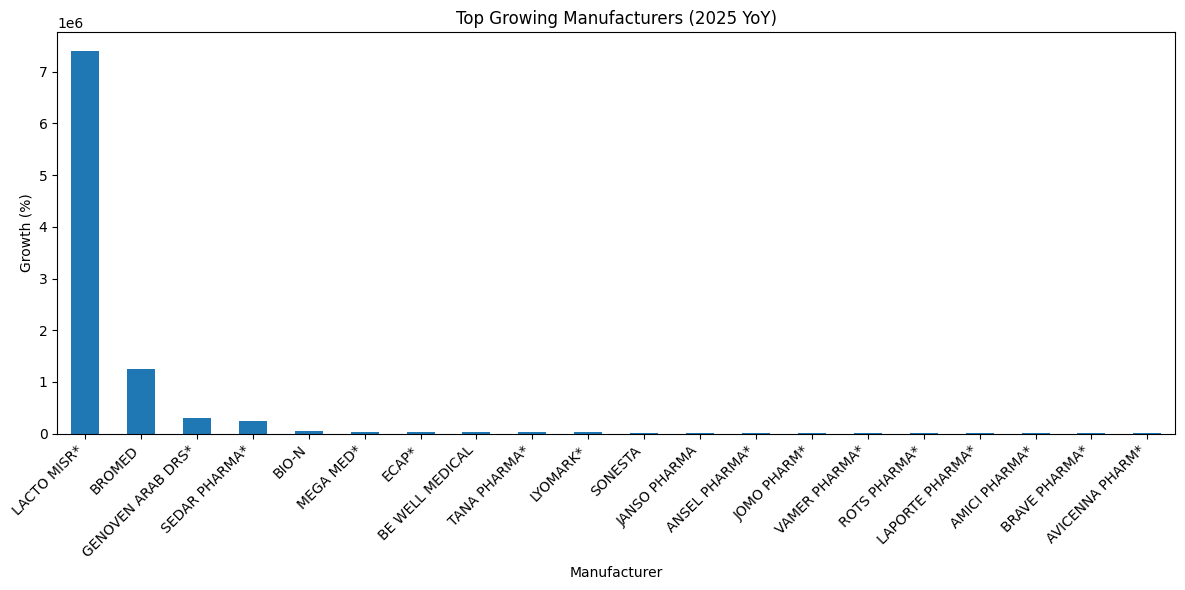

In [262]:
plt.figure(figsize=(12,6))

top_growth.plot(kind="bar")

plt.title("Top Growing Manufacturers (2025 YoY)")

plt.ylabel("Growth (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

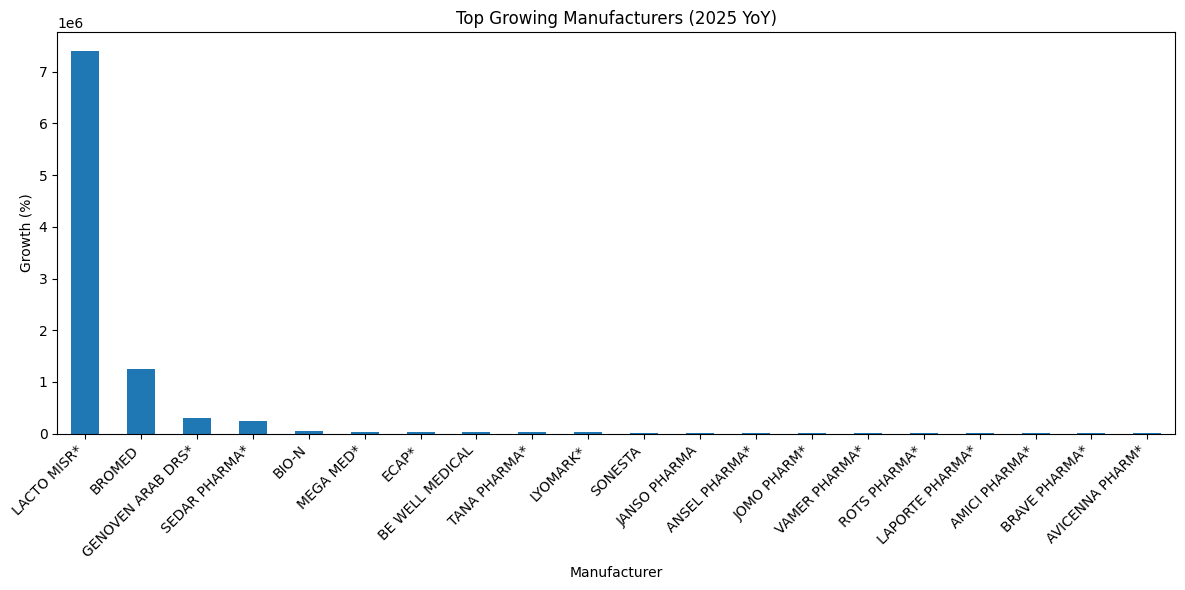

In [263]:
plt.figure(figsize=(12,6))

top_growth.plot(kind="bar")

plt.title("Top Growing Manufacturers (2025 YoY)")

plt.ylabel("Growth (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

# Compound Annual Growth Rate (CAGR)

CAGR measures the average annual growth rate over a multi-year period.

Unlike Year-over-Year Growth, CAGR provides a smoother and more reliable measure of long term market performance

In [264]:
market_sales = (
    df.groupby("Year")["Sales Value"]
      .sum()
      .sort_index()
)

market_sales

Year
2021    1.060877e+11
2022    1.189950e+11
2023    1.485131e+11
2024    2.172278e+11
2025    2.920578e+11
Name: Sales Value, dtype: float64

In [265]:
start_value = market_sales.iloc[0]
end_value = market_sales.iloc[-1]

years = len(market_sales) - 1

cagr = ((end_value / start_value) ** (1 / years) - 1) * 100

print(f"Market CAGR: {cagr:.2f}%")

Market CAGR: 28.81%


In [266]:
manufacturer_sales = (
    df.groupby(["Manufacturer", "Year"])["Sales Value"]
      .sum()
      .unstack()
)

In [267]:
import numpy as np

years = manufacturer_sales.shape[1] - 1

manufacturer_cagr = (
    (
        manufacturer_sales.iloc[:, -1] /
        manufacturer_sales.iloc[:, 0]
    ) ** (1 / years) - 1
) * 100

manufacturer_cagr = manufacturer_cagr.replace(
    [np.inf, -np.inf],
    np.nan
)

manufacturer_cagr = manufacturer_cagr.dropna()

manufacturer_cagr = manufacturer_cagr.sort_values(
    ascending=False
)

manufacturer_cagr.head(20)

Manufacturer
BIONORICA*            1734.338898
BENDALIS*              664.505809
INAD PHARMA*           508.594519
ADAPT PHARMA*          471.264717
RIMOS PH.*             435.317901
LO.LI.PHARMA*          284.591786
ORPHAN PH.*            264.243220
PHARMACREDO*           262.383213
REXCEL*                259.839110
UNISWAB*               258.107789
MASOCMED*              250.542428
ART PHARMA*            248.958939
MB PHARMA*             228.461414
BASANT PHARMA*         226.600331
SUNSHINE PH.**         225.291990
BOSTON PHARMACEUT*     216.457955
SKY CARE PHARMA*       201.083010
NORGINE*               191.393018
HAMELN*                189.964738
SEA PHARM              184.691854
dtype: float64

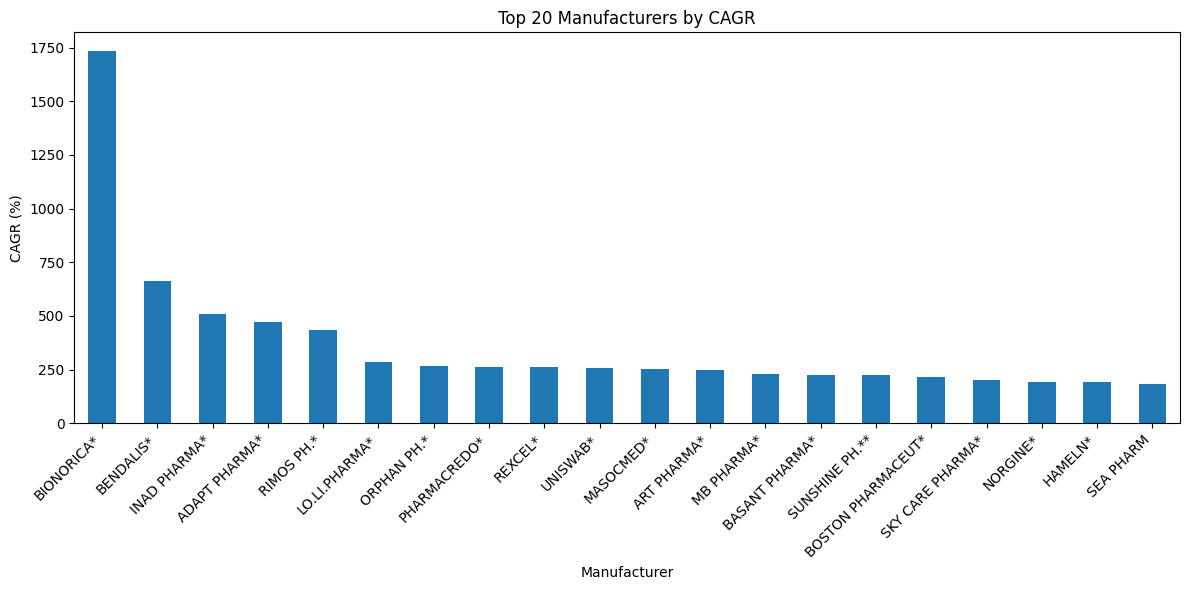

In [268]:
plt.figure(figsize=(12,6))

manufacturer_cagr.head(20).plot(kind="bar")

plt.title("Top 20 Manufacturers by CAGR")

plt.ylabel("CAGR (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [269]:
manufacturer_year = (
    df.groupby(["Manufacturer","Year"])["Sales Value"]
      .sum()
      .reset_index()
)

total_revenue = (
    manufacturer_year.groupby("Manufacturer")["Sales Value"]
    .sum()
)

eligible = total_revenue[total_revenue > 100_000_000].index

In [270]:
eligible_pivot = manufacturer_pivot.loc[eligible]

years = 4

cagr_df = (
    ((eligible_pivot[2025] / eligible_pivot[2021]) ** (1 / years) - 1)
    * 100
).reset_index()

cagr_df.columns = ["Manufacturer", "CAGR (%)"]

cagr_df = cagr_df.sort_values(
    "CAGR (%)",
    ascending=False)

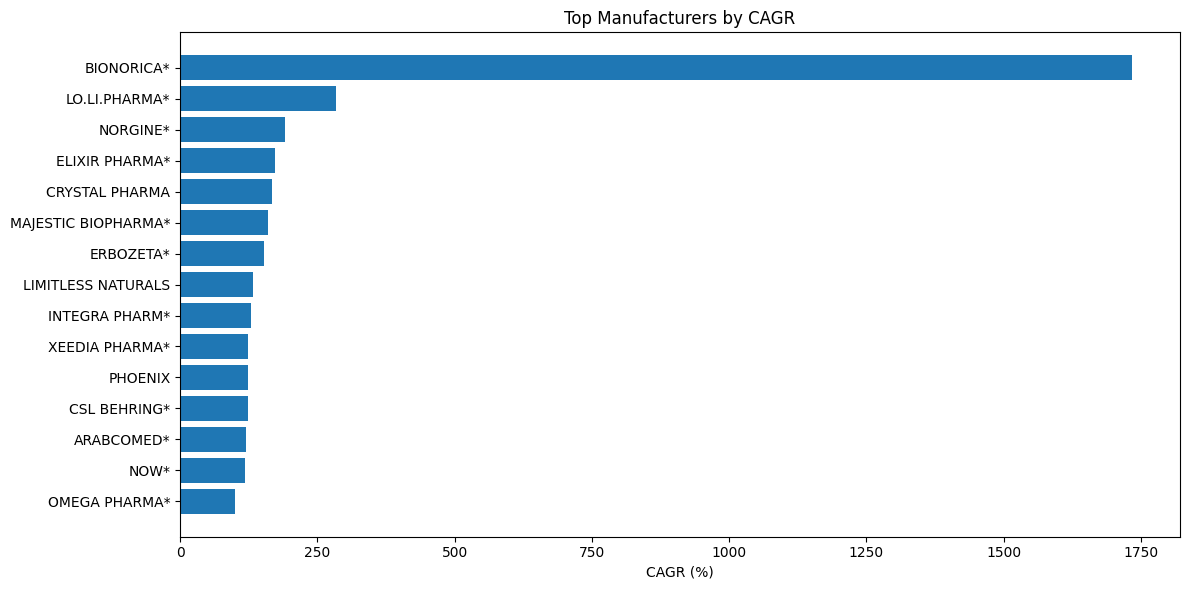

In [271]:
top15 = cagr_df.head(15)

plt.figure(figsize=(12,6))

plt.barh(
    top15["Manufacturer"],
    top15["CAGR (%)"]
)

plt.gca().invert_yaxis()

plt.title("Top Manufacturers by CAGR")

plt.xlabel("CAGR (%)")

plt.tight_layout()

plt.show()

#Rising Stars in the Market

In [272]:
market_share = (
    df.groupby("Manufacturer")["Sales Value"]
      .sum()
      .reset_index()
)

market_share["Market Share (%)"] = (
    market_share["Sales Value"]
    / market_share["Sales Value"].sum()
    * 100
)

market_share = market_share[
    ["Manufacturer", "Market Share (%)"]
]

In [273]:
rising_star_1 = market_share.merge(
    cagr_df,
    on="Manufacturer"
)

In [274]:
rising_star_1 = rising_star_1.sort_values(
    ["CAGR (%)","Market Share (%)"],
    ascending=False
)

rising_star_1.head(20)

,Manufacturer,Market Share (%),CAGR (%)
33,BIONORICA*,0.028234,1734.338898
116,LO.LI.PHARMA*,0.022480,284.591786
147,NORGINE*,0.020526,191.393018
65,ELIXIR PHARMA*,0.143541,172.066946
48,CRYSTAL PHARMA,0.021813,167.599707
121,MAJESTIC BIOPHARMA*,0.017489,160.631830
68,ERBOZETA*,0.044505,152.883242
113,LIMITLESS NATURALS,1.009481,132.306604
102,INTEGRA PHARM*,0.122198,128.538495
219,XEEDIA PHARMA*,0.249969,124.113088


In [275]:
manufacturer_yoy = (
    manufacturer_pivot
    .pct_change(axis=1) * 100
).round(2)
manufacturer_yoy.head()

C:\Users\lapshop\AppData\Local\Temp\ipykernel_4628\6421993.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(axis=1) * 100


Year,2021,2022,2023,2024,2025
Manufacturer,,,,,
15 MAY PHARMACEUTICAL,NaN,-69.77,-93.62,719.47,-21.07
2M WHITES,NaN,NaN,NaN,NaN,NaN
2MS PHARMA,NaN,NaN,NaN,NaN,NaN
3A,NaN,NaN,NaN,NaN,NaN
4S PHARMA*,NaN,NaN,NaN,NaN,97.30


In [276]:
last_yoy_df = (
    manufacturer_yoy[[2025]]
    .reset_index()
)

last_yoy_df.columns = [
    "Manufacturer",
    "YoY Growth (%)"
]

In [277]:
last_yoy_df["YoY Growth (%)"] = (
    last_yoy_df["YoY Growth (%)"]
    .fillna(0)
)

In [278]:
rising_star_2= market_share.merge(cagr_df, on="Manufacturer")
rising_star_2= rising_star_2.merge(last_yoy_df, on="Manufacturer")

rising_star_2 = rising_star_2[
    (rising_star_2["Market Share (%)"] >= 1) &
    (rising_star_2["CAGR (%)"] >= 10) &
    (rising_star_2["YoY Growth (%)"] > 0)
]
rising_star_2.head(10)

,Manufacturer,Market Share (%),CAGR (%),YoY Growth (%)
0,ABBOTT*,1.956641,29.757676,25.02
9,AL ANDALOUS MEDICAL COMPANY*,1.129206,23.099246,24.03
17,AMOUN PHARM.CO.*,3.598065,20.533551,59.32
23,ASTRAZENECA*,2.241809,30.090077,14.32
25,AUG PHARMA*,2.318417,33.039853,58.77
29,BAYER HEALTHCARE*,1.192152,20.801786,29.27
32,BIOMED PHARMA.*,1.227709,80.937955,132.32
40,CHEMIPHARM*,1.018581,21.419621,18.76
61,EIPICO/ACDIMA,2.989105,21.602265,30.99
69,EVA PHARMA*,2.725896,27.053784,29.46


1. Criterion 1 → Filter large manufacturers.
2. Criterion 2 → Filter companies with meaningful market presence.
3. Criterion 3 → Filter companies with sustainable long-term growth.
4. Criterion 4 → Filter companies with positive recent momentum.
5. Final Score → Rank the remaining companies.

In [279]:
rising_star_2["Score"] = (
    0.5 * rising_star_2["Market Share (%)"] +
    0.3 * rising_star_2["CAGR (%)"] +
    0.2 * rising_star_2["YoY Growth (%)"]
)

rising_star_2 = rising_star_2.sort_values(
    "Score",
    ascending=False
)
rising_star_2.head().sort_values("Score", ascending =False)

,Manufacturer,Market Share (%),CAGR (%),YoY Growth (%),Score
113,LIMITLESS NATURALS,1.009481,132.306604,89.72,58.140722
32,BIOMED PHARMA.*,1.227709,80.937955,132.32,51.359241
142,NERHADOU INTERNAT.,1.133351,52.812514,32.75,22.960430
25,AUG PHARMA*,2.318417,33.039853,58.77,22.825165
122,MARCYRL*,2.541935,40.024885,42.26,21.730433


In [280]:
#Because Data not scaled ,will use MinMax scaler 

In [281]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

rising_star_2[
    ["Market Share (%)", "CAGR (%)", "YoY Growth (%)"]
] = scaler.fit_transform(
    rising_star_2[
        ["Market Share (%)", "CAGR (%)", "YoY Growth (%)"]
    ]
)

In [282]:
rising_star_2["Score"] = (
    0.5 * rising_star_2["Market Share (%)"] +
    0.3 * rising_star_2["CAGR (%)"] +
    0.2 * rising_star_2["YoY Growth (%)"]
)
rising_star_2.head(10).sort_values("Score", ascending =False)

,Manufacturer,Market Share (%),CAGR (%),YoY Growth (%),Score
17,AMOUN PHARM.CO.*,0.673109,0.048357,0.406552,0.432372
113,LIMITLESS NATURALS,0.000000,1.000000,0.653687,0.430737
32,BIOMED PHARMA.*,0.056746,0.562644,1.000000,0.397166
122,MARCYRL*,0.398483,0.214307,0.267864,0.317107
25,AUG PHARMA*,0.340362,0.154836,0.402081,0.297048
87,HALEON*,0.244803,0.167643,0.235022,0.219698
138,MUP/ACDIMA,0.267905,0.119132,0.240306,0.217753
150,NOVO NORDISK*,0.163999,0.228956,0.099829,0.170652
142,NERHADOU INTERNAT.,0.032210,0.323182,0.190554,0.151170
143,NESTLE*,0.018214,0.177328,0.271035,0.116512



## Executive Insight

CAGR highlights manufacturers that achieved sustained long-term growth rather than temporary year-over-year increases.

Companies with consistently positive CAGR demonstrate stronger commercial performance and long-term market expansion.


#Phase 4 — Pareto / ABC Analysis

In [283]:
brand_revenue = (
    df.groupby("Brand Name")["Sales Value"]
    .sum()
    .sort_values(ascending=False)
)

brand_revenue.head(10)

Brand Name
ZURCAL        7.804095e+09
AUGMENTIN     6.813283e+09
CONTROLOC     6.360948e+09
PANADOL       6.048820e+09
CLEXANE       5.555901e+09
GABIMASH      5.308934e+09
BRUFEN        5.189706e+09
HIBIOTIC      5.093675e+09
CONVENTIN     4.798667e+09
ALPHINTERN    4.095527e+09
Name: Sales Value, dtype: float64

In [284]:
brand_pareto = brand_revenue.reset_index()

brand_pareto["Revenue Share (%)"] = (
    brand_pareto["Sales Value"]
    / brand_pareto["Sales Value"].sum()
    * 100
)

In [285]:
brand_pareto["Cumulative Share (%)"] = (
    brand_pareto["Revenue Share (%)"]
    .cumsum()
)

In [286]:
brand_pareto.head(20)

,Brand Name,Sales Value,Revenue Share (%),Cumulative Share (%)
0,ZURCAL,7.804095e+09,0.883935,0.883935
1,AUGMENTIN,6.813283e+09,0.771710,1.655644
2,CONTROLOC,6.360948e+09,0.720476,2.376120
3,PANADOL,6.048820e+09,0.685123,3.061243
4,CLEXANE,5.555901e+09,0.629292,3.690535
5,GABIMASH,5.308934e+09,0.601319,4.291853
6,BRUFEN,5.189706e+09,0.587815,4.879668
7,HIBIOTIC,5.093675e+09,0.576938,5.456606
8,CONVENTIN,4.798667e+09,0.543523,6.000129
9,ALPHINTERN,4.095527e+09,0.463882,6.464011


In [287]:
import numpy as np

brand_pareto["ABC Class"] = np.select(
    [
        brand_pareto["Cumulative Share (%)"] <= 80,
        brand_pareto["Cumulative Share (%)"] <= 95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

In [288]:
brand_pareto.head(20)

,Brand Name,Sales Value,Revenue Share (%),Cumulative Share (%),ABC Class
0,ZURCAL,7.804095e+09,0.883935,0.883935,A
1,AUGMENTIN,6.813283e+09,0.771710,1.655644,A
2,CONTROLOC,6.360948e+09,0.720476,2.376120,A
3,PANADOL,6.048820e+09,0.685123,3.061243,A
4,CLEXANE,5.555901e+09,0.629292,3.690535,A
5,GABIMASH,5.308934e+09,0.601319,4.291853,A
6,BRUFEN,5.189706e+09,0.587815,4.879668,A
7,HIBIOTIC,5.093675e+09,0.576938,5.456606,A
8,CONVENTIN,4.798667e+09,0.543523,6.000129,A
9,ALPHINTERN,4.095527e+09,0.463882,6.464011,A


In [289]:
abc_summary = (
    brand_pareto
    .groupby("ABC Class")
    .agg(
        Brands=("Brand Name", "count"),
        Revenue=("Sales Value", "sum")
    )
    .reset_index()
)

abc_summary["Revenue Share (%)"] = (
    abc_summary["Revenue"]
    / abc_summary["Revenue"].sum()
    * 100
).round(2)

abc_summary

,ABC Class,Brands,Revenue,Revenue Share (%)
0,A,912,7.061244e+11,79.98
1,B,1248,1.325805e+11,15.02
2,C,7798,4.417654e+10,5.00


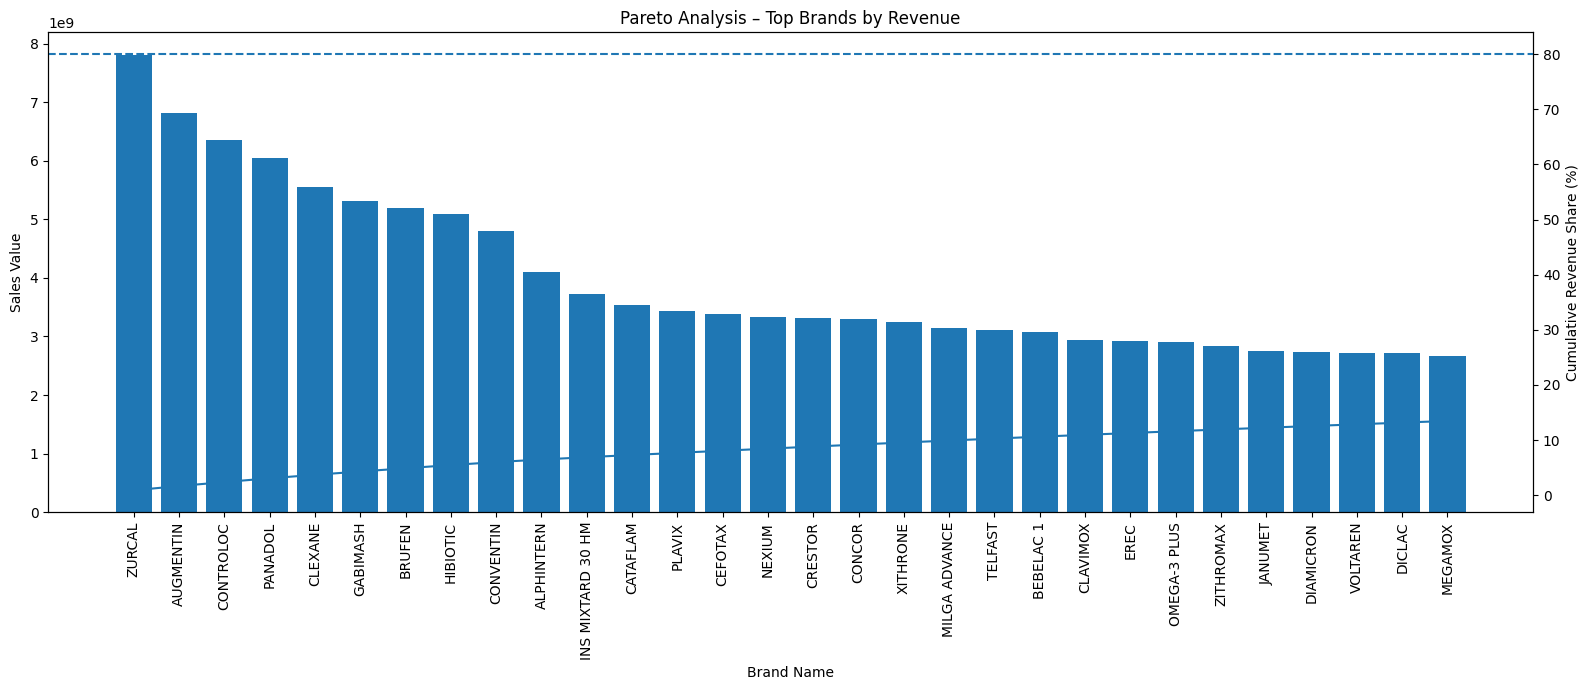

In [290]:
import matplotlib.pyplot as plt

# Select top brands for visualization
top_n = 30

pareto_plot = brand_pareto.head(top_n)

fig, ax1 = plt.subplots(figsize=(16, 7))

# Revenue bars
ax1.bar(
    pareto_plot["Brand Name"],
    pareto_plot["Sales Value"]
)

ax1.set_xlabel("Brand Name")
ax1.set_ylabel("Sales Value")
ax1.tick_params(axis="x", rotation=90)

# Cumulative percentage line
ax2 = ax1.twinx()

ax2.plot(
    pareto_plot["Brand Name"],
    pareto_plot["Cumulative Share (%)"],
    marker="o"
)

ax2.set_ylabel("Cumulative Revenue Share (%)")
ax2.axhline(80, linestyle="--")

plt.title("Pareto Analysis – Top Brands by Revenue")
plt.tight_layout()
plt.show()

#Identify the Brands Responsible for 80% of Revenue

In [291]:
brands_80 = brand_pareto[
    brand_pareto["Cumulative Share (%)"] <= 80
].copy()

print("Number of brands generating approximately 80% of revenue:",
      len(brands_80))

brands_80.head(20)

Number of brands generating approximately 80% of revenue: 912


,Brand Name,Sales Value,Revenue Share (%),Cumulative Share (%),ABC Class
0,ZURCAL,7.804095e+09,0.883935,0.883935,A
1,AUGMENTIN,6.813283e+09,0.771710,1.655644,A
2,CONTROLOC,6.360948e+09,0.720476,2.376120,A
3,PANADOL,6.048820e+09,0.685123,3.061243,A
4,CLEXANE,5.555901e+09,0.629292,3.690535,A
5,GABIMASH,5.308934e+09,0.601319,4.291853,A
6,BRUFEN,5.189706e+09,0.587815,4.879668,A
7,HIBIOTIC,5.093675e+09,0.576938,5.456606,A
8,CONVENTIN,4.798667e+09,0.543523,6.000129,A
9,ALPHINTERN,4.095527e+09,0.463882,6.464011,A


In [292]:
#ABC Distribution Chart

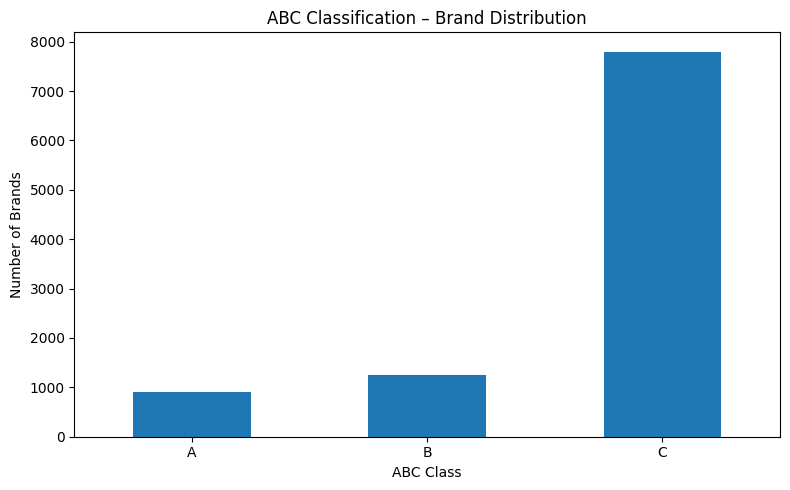

In [293]:
abc_counts = (
    brand_pareto["ABC Class"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

abc_counts.plot(kind="bar")

plt.title("ABC Classification – Brand Distribution")
plt.xlabel("ABC Class")
plt.ylabel("Number of Brands")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Revenue Contribution by ABC Class

<Figure size 800x500 with 0 Axes>

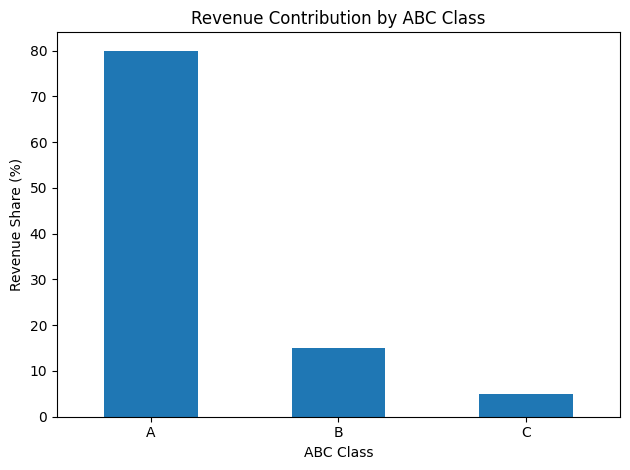

In [294]:
plt.figure(figsize=(8, 5))

abc_summary.plot(
    x="ABC Class",
    y="Revenue Share (%)",
    kind="bar",
    legend=False
)

plt.title("Revenue Contribution by ABC Class")
plt.xlabel("ABC Class")
plt.ylabel("Revenue Share (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Top 20 Brands in Class A

In [295]:
top_A_brands = (
    brand_pareto[
        brand_pareto["ABC Class"] == "A"
    ]
    .head(20)
)

top_A_brands

,Brand Name,Sales Value,Revenue Share (%),Cumulative Share (%),ABC Class
0,ZURCAL,7.804095e+09,0.883935,0.883935,A
1,AUGMENTIN,6.813283e+09,0.771710,1.655644,A
2,CONTROLOC,6.360948e+09,0.720476,2.376120,A
3,PANADOL,6.048820e+09,0.685123,3.061243,A
4,CLEXANE,5.555901e+09,0.629292,3.690535,A
5,GABIMASH,5.308934e+09,0.601319,4.291853,A
6,BRUFEN,5.189706e+09,0.587815,4.879668,A
7,HIBIOTIC,5.093675e+09,0.576938,5.456606,A
8,CONVENTIN,4.798667e+09,0.543523,6.000129,A
9,ALPHINTERN,4.095527e+09,0.463882,6.464011,A


## Pareto / ABC Analysis – Business Insight

The Pareto analysis shows how pharmaceutical market revenue is distributed across brands.

Class A brands represent the highest-value products and account for approximately 80% of cumulative market revenue. These brands should receive the highest priority in commercial planning, inventory management, sales resources, and strategic monitoring.

Class B brands contribute a moderate share of revenue and should be monitored for potential growth opportunities.

Class C brands generate a relatively small portion of total revenue and may require a more selective commercial strategy.

The analysis demonstrates that a relatively small group of brands contributes a disproportionate share of total market revenue, highlighting the importance of focusing resources on high-value products.

#Phase 5 — Sales Forecasting

In [296]:
monthly_sales = (
    df.groupby("Month")["Sales Value"]
    .sum()
    .sort_index()
)

monthly_sales = monthly_sales.asfreq("MS")

monthly_sales.head()

Month
2021-01-01    7.838593e+09
2021-02-01    7.254915e+09
2021-03-01    8.702145e+09
2021-04-01    7.727591e+09
2021-05-01    8.863685e+09
Freq: MS, Name: Sales Value, dtype: float64

#Plot Historical Sales

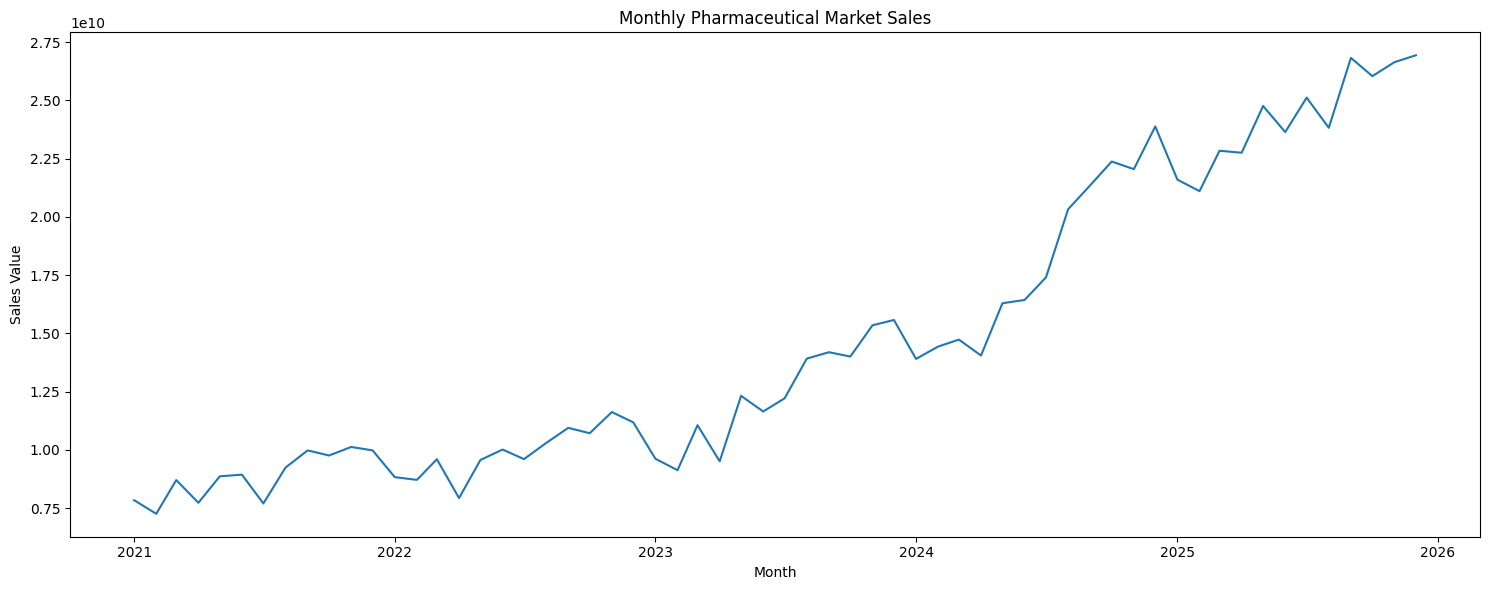

In [297]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Pharmaceutical Market Sales")
plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.tight_layout()
plt.show()

In [298]:
#Train / Test Split
train = monthly_sales.iloc[:-12]

test = monthly_sales.iloc[-12:]

print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training period: 2021-01-01 00:00:00 to 2024-12-01 00:00:00
Testing period: 2025-01-01 00:00:00 to 2025-12-01 00:00:00


In [299]:
!pip install statsmodels


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\lapshop\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  res = process_handler(cmd, _system_body)
C:\Users\lapshop\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)
C:\Users\lapshop\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)


In [300]:
import statsmodels


In [301]:
#Exponential Smoothing Forecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

forecast_fit = forecast_model.fit()

forecast = forecast_fit.forecast(12)

forecast

2025-01-01    2.263485e+10
2025-02-01    2.309310e+10
2025-03-01    2.470772e+10
2025-04-01    2.395735e+10
2025-05-01    2.657541e+10
2025-06-01    2.703775e+10
2025-07-01    2.766198e+10
2025-08-01    2.973661e+10
2025-09-01    3.089939e+10
2025-10-01    3.140518e+10
2025-11-01    3.267016e+10
2025-12-01    3.332285e+10
Freq: MS, dtype: float64

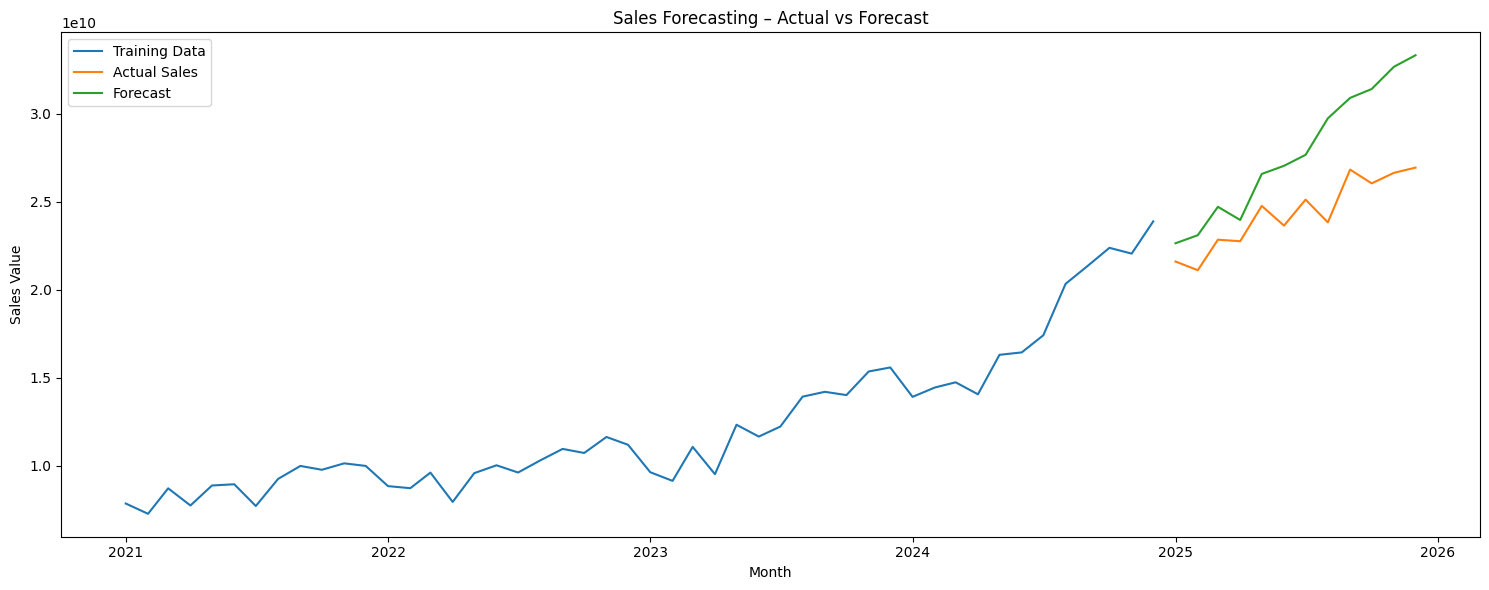

In [302]:
#Compare Actual vs Forecast
plt.figure(figsize=(15, 6))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Sales"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast"
)

plt.title("Sales Forecasting – Actual vs Forecast")
plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.legend()
plt.tight_layout()
plt.show()

In [303]:
#Forecast Accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

mape = np.mean(
    np.abs((test - forecast) / test)
) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 3470378139.83
RMSE: 3967698160.73
MAPE: 13.88 %


In [304]:
#Forecast Next 12 Months
final_model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

final_fit = final_model.fit()

future_forecast = final_fit.forecast(12)

future_forecast

2026-01-01    2.517995e+10
2026-02-01    2.490833e+10
2026-03-01    2.614062e+10
2026-04-01    2.511774e+10
2026-05-01    2.708969e+10
2026-06-01    2.678064e+10
2026-07-01    2.704907e+10
2026-08-01    2.804136e+10
2026-09-01    2.921668e+10
2026-10-01    2.906231e+10
2026-11-01    2.959221e+10
2026-12-01    2.988577e+10
Freq: MS, dtype: float64

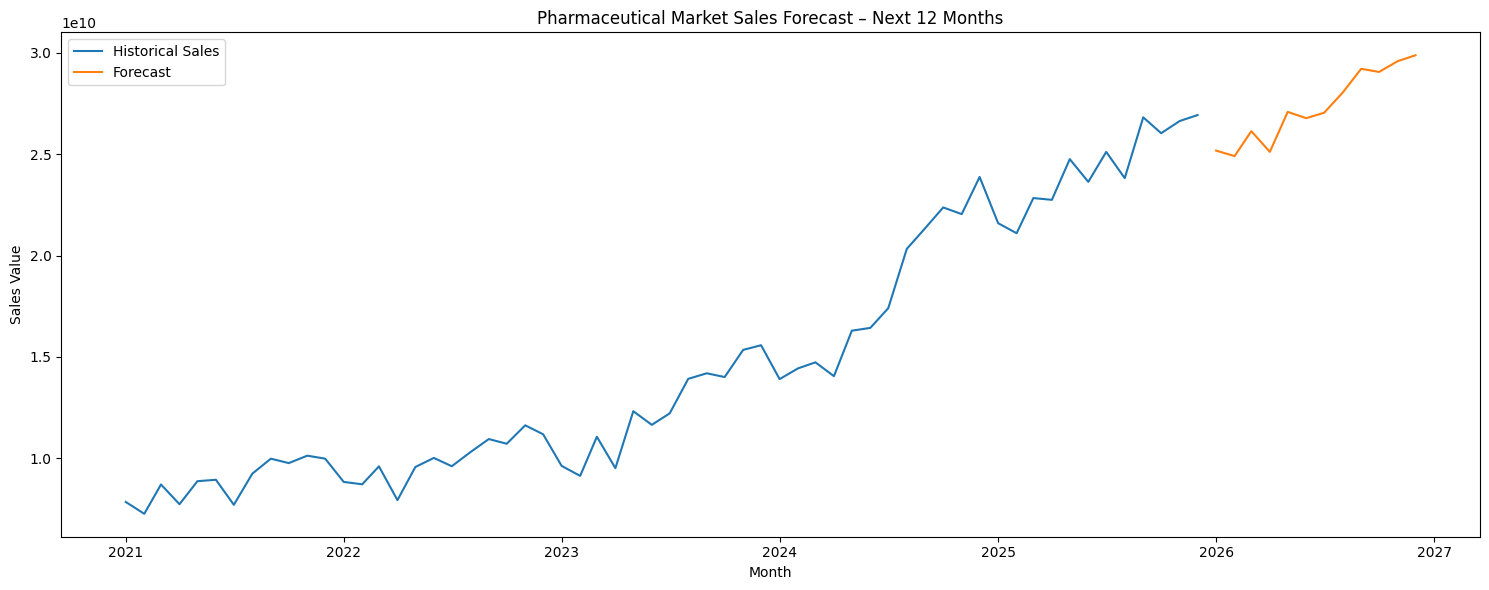

In [305]:
#Plot Future Forecast
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Historical Sales"
)

plt.plot(
    future_forecast.index,
    future_forecast.values,
    label="Forecast"
)

plt.title("Pharmaceutical Market Sales Forecast – Next 12 Months")
plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.legend()
plt.tight_layout()
plt.show()

### Sales Forecasting – Business Insight

The forecasting model estimates future monthly pharmaceutical market sales based on historical sales patterns, trend, and seasonality.

The model is evaluated on the most recent 12 months using MAE, RMSE, and MAPE to assess forecast performance.

The resulting forecast can support commercial planning, inventory management, sales target setting, and resource allocation.

Forecasting should be interpreted as a decision-support tool rather than an exact prediction of future market performance.

In [306]:
# Seasonal Naive Forecast
# Seasonal Naive Forecast
# Use the same month from the previous year as the forecast

seasonal_naive_forecast = train.iloc[-12:].values

seasonal_naive_forecast

array([1.39022811e+10, 1.44339533e+10, 1.47300052e+10, 1.40479056e+10,
       1.62923393e+10, 1.64309369e+10, 1.74043491e+10, 2.03286525e+10,
       2.13563176e+10, 2.23754215e+10, 2.20460500e+10, 2.38795967e+10])

In [307]:
# Compare actual 2025 sales with Seasonal Naive forecast

comparison = pd.DataFrame({
    "Actual": test.values,
    "Forecast": seasonal_naive_forecast
}, index=test.index)

comparison

,Actual,Forecast
Month,,
2025-01-01,2.159677e+10,1.390228e+10
2025-02-01,2.110284e+10,1.443395e+10
2025-03-01,2.283770e+10,1.473001e+10
2025-04-01,2.275040e+10,1.404791e+10
2025-05-01,2.475851e+10,1.629234e+10
2025-06-01,2.363798e+10,1.643094e+10
2025-07-01,2.511584e+10,1.740435e+10
2025-08-01,2.382179e+10,2.032865e+10
2025-09-01,2.682275e+10,2.135632e+10


In [308]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    comparison["Actual"],
    comparison["Forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Forecast"]
    )
)

mape = np.mean(
    np.abs(
        (comparison["Actual"] - comparison["Forecast"])
        / comparison["Actual"]
    )
) * 100

print("Seasonal Naive MAE:", round(mae, 2))
print("Seasonal Naive RMSE:", round(rmse, 2))
print("Seasonal Naive MAPE:", round(mape, 2), "%")

Seasonal Naive MAE: 6235833473.16
Seasonal Naive RMSE: 6545804310.96
Seasonal Naive MAPE: 26.17 %


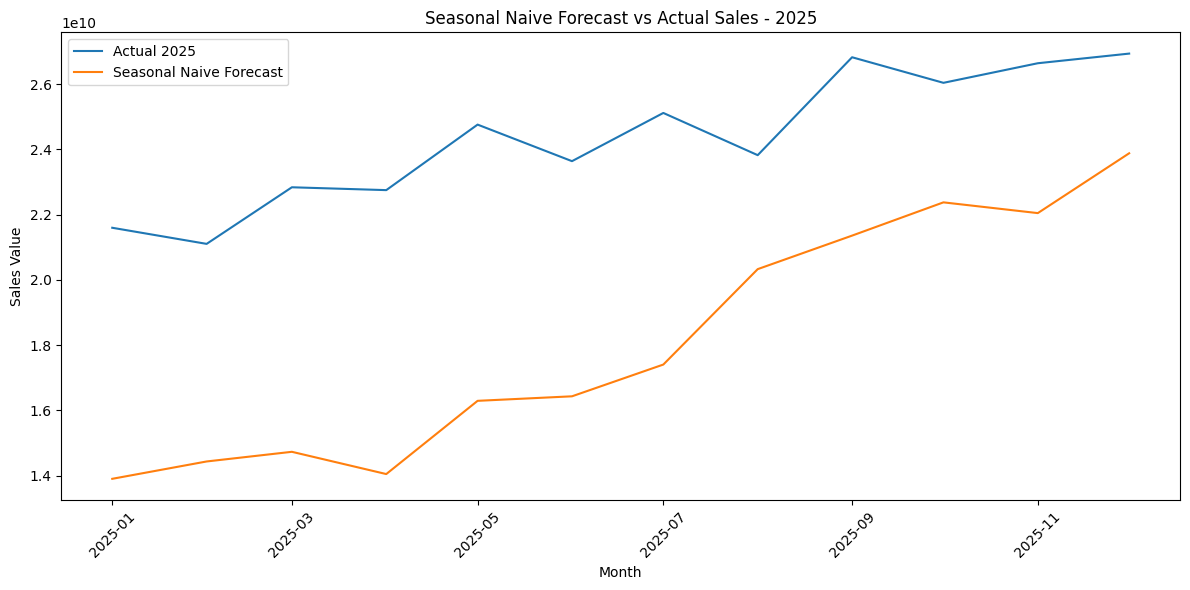

In [309]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison.index,
    comparison["Actual"],
    label="Actual 2025"
)

plt.plot(
    comparison.index,
    comparison["Forecast"],
    label="Seasonal Naive Forecast"
)

plt.title("Seasonal Naive Forecast vs Actual Sales - 2025")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [310]:
# Linear Regression Forecast
# Features: Time Trend + Monthly Seasonality

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Create training dataframe
lr_train = pd.DataFrame({
    "Sales": train.values
}, index=train.index)

# Time trend
lr_train["Trend"] = np.arange(len(lr_train))

# Month features
lr_train["Month"] = lr_train.index.month

# One-hot encode months
lr_train = pd.get_dummies(
    lr_train,
    columns=["Month"],
    drop_first=True
)

# Features and target
X_train = lr_train.drop(columns=["Sales"])
y_train = lr_train["Sales"]

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 2.52e+08,-4.17e+08, 4.71e+08,..., 1.90e+09, 2.22e+09, 2.33e+09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Trend','Month_2','Month_3',...,'Month_10','Month_11','Month_12']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.51e+09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [311]:
# Create testing dataframe

lr_test = pd.DataFrame(
    index=test.index
)

# Continue the time trend
lr_test["Trend"] = np.arange(
    len(train),
    len(train) + len(test)
)

lr_test["Month"] = lr_test.index.month

lr_test = pd.get_dummies(
    lr_test,
    columns=["Month"],
    drop_first=True
)

# Make sure test has exactly the same columns as training
lr_test = lr_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Forecast 2025
lr_forecast = lr_model.predict(lr_test)

In [312]:
# Evaluate Linear Regression

lr_mae = mean_absolute_error(
    test.values,
    lr_forecast
)

lr_rmse = np.sqrt(
    mean_squared_error(
        test.values,
        lr_forecast
    )
)

lr_mape = np.mean(
    np.abs(
        (test.values - lr_forecast)
        / test.values
    )
) * 100

print("Linear Regression MAE:", round(lr_mae, 2))
print("Linear Regression RMSE:", round(lr_rmse, 2))
print("Linear Regression MAPE:", round(lr_mape, 2), "%")

Linear Regression MAE: 4468109965.85
Linear Regression RMSE: 4541111576.13
Linear Regression MAPE: 18.39 %


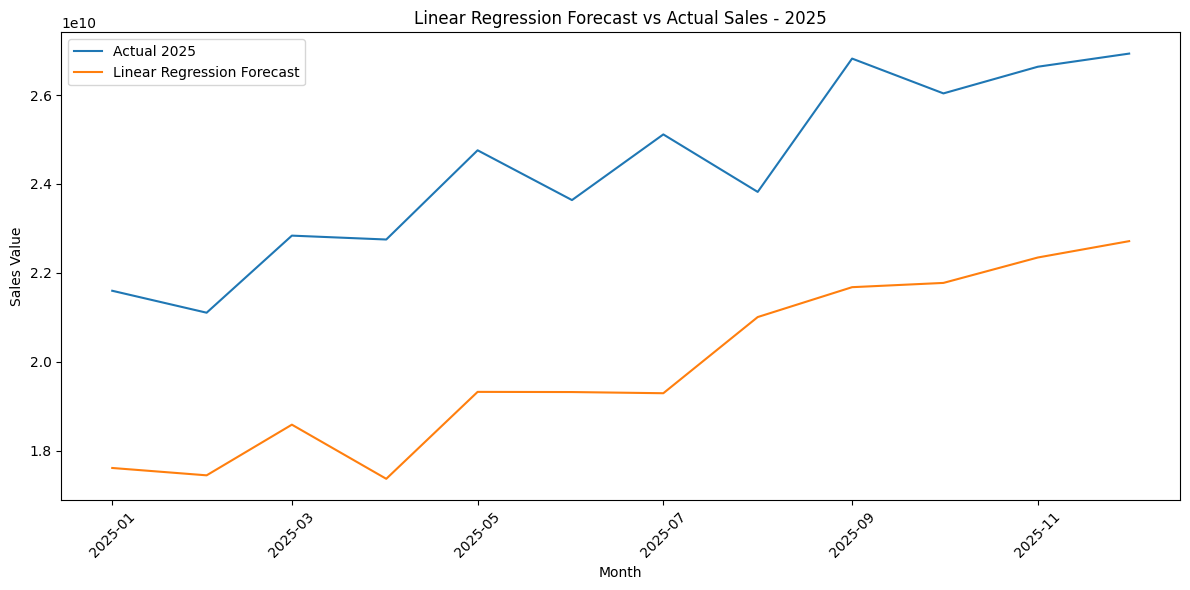

In [313]:
# Plot Linear Regression Forecast vs Actual

plt.figure(figsize=(12, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual 2025"
)

plt.plot(
    test.index,
    lr_forecast,
    label="Linear Regression Forecast"
)

plt.title(
    "Linear Regression Forecast vs Actual Sales - 2025"
)

plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sales Forecasting — Model Evaluation

Forecasting is used to estimate future pharmaceutical market sales and support
commercial planning, budgeting, inventory management, and strategic decision-making.

To ensure that the selected forecasting approach is reliable, multiple models are
evaluated using historical data from 2021–2024 and validated against the actual
2025 market performance.

The evaluation focuses on three key metrics:

- MAE (Mean Absolute Error): Measures the average absolute difference between
  forecasted and actual sales values.

- RMSE (Root Mean Squared Error): Penalizes larger forecasting errors more heavily
  and helps identify models with significant deviations.

- MAPE (Mean Absolute Percentage Error): Measures forecast accuracy as a percentage,
  making it easier to interpret from a business perspective.

The models are compared using the same 2025 testing period, and the model with
the strongest predictive performance will be selected for future market forecasting.

### Forecasting Models Evaluated

*1. Seasonal Naive Forecast*

Uses the sales value from the same month in the previous year as the forecast.
This serves as a business baseline to determine whether more advanced models
provide meaningful improvement.

*2. Linear Regression*

Captures the overall market growth trend together with monthly seasonality.
This model provides a simple and interpretable benchmark for market forecasting.

*3. Random Forest Regression*

Captures nonlinear relationships between historical sales patterns, recent sales
performance, seasonality, and long-term market trends.

The Random Forest model will use lagged sales features representing previous
months and previous-year performance.

### Initial Forecasting Results

The Seasonal Naive model achieved a MAPE of 26.17%, providing a useful baseline
but showing relatively high forecasting error.

Linear Regression improved the MAPE to 18.39%, representing a substantial
improvement over the baseline by incorporating market trend and monthly seasonality.

The next step is to evaluate a Random Forest model using historical sales patterns
to determine whether nonlinear relationships can further improve forecasting accuracy.

#Can historical sales patterns provide additional predictive power beyond simple trend and seasonality?

#Feature

Business Meaning

Lag_1

Sales of previous month

Lag_3

Sales three months earlier

Lag_6

Sales six months earlier

Lag_12

Sales of same month last year

Month

Monthly seasonality

Quarter

Quarterly business pattern

Trend

Overall market growth over time

In [314]:
# Random Forest Forecasting
# Capturing nonlinear relationships in historical pharmaceutical market sales

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

In [315]:
# Prepare historical training data

rf_data = pd.DataFrame({
    "Sales": train
})

# Time trend
rf_data["Trend"] = np.arange(len(rf_data))

# Seasonal features
rf_data["Month"] = rf_data.index.month
rf_data["Quarter"] = rf_data.index.quarter

# Historical sales features
rf_data["Lag_1"] = rf_data["Sales"].shift(1)
rf_data["Lag_3"] = rf_data["Sales"].shift(3)
rf_data["Lag_6"] = rf_data["Sales"].shift(6)
rf_data["Lag_12"] = rf_data["Sales"].shift(12)

# Remove rows with missing lag values
rf_data = rf_data.dropna()

rf_data.head()

,Sales,Trend,Month,Quarter,Lag_1,Lag_3,Lag_6,Lag_12
Month,,,,,,,,
2022-01-01,8.828284e+09,12,1,1,9.976291e+09,9.757084e+09,7.697453e+09,7.838593e+09
2022-02-01,8.710448e+09,13,2,1,8.828284e+09,1.012290e+10,9.237502e+09,7.254915e+09
2022-03-01,9.596476e+09,14,3,1,8.710448e+09,9.976291e+09,9.975467e+09,8.702145e+09
2022-04-01,7.929274e+09,15,4,2,9.596476e+09,8.828284e+09,9.757084e+09,7.727591e+09
2022-05-01,9.565128e+09,16,5,2,7.929274e+09,8.710448e+09,1.012290e+10,8.863685e+09


In [316]:
# Define business and historical features

features = [
    "Trend",
    "Month",
    "Quarter",
    "Lag_1",
    "Lag_3",
    "Lag_6",
    "Lag_12"
]

X_train_rf = rf_data[features]
y_train_rf = rf_data["Sales"]

In [317]:
# Train Random Forest Regression model

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train_rf
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [318]:
# Recursive forecasting for the 2025 testing period
# Previous forecasts are used as inputs for future predictions

history = train.copy()

rf_predictions = []

for current_date in test.index:

    # Create features for the current month
    trend = len(history)

    month = current_date.month
    quarter = current_date.quarter

    lag_1 = history.iloc[-1]
    lag_3 = history.iloc[-3]
    lag_6 = history.iloc[-6]
    lag_12 = history.iloc[-12]

    current_features = pd.DataFrame({
        "Trend": [trend],
        "Month": [month],
        "Quarter": [quarter],
        "Lag_1": [lag_1],
        "Lag_3": [lag_3],
        "Lag_6": [lag_6],
        "Lag_12": [lag_12]
    })

    # Forecast the current month
    prediction = rf_model.predict(
        current_features[features]
    )[0]

    rf_predictions.append(prediction)

    # Add prediction to history for future lag calculations
    history.loc[current_date] = prediction

In [319]:
# Evaluate Random Forest forecasting performance

rf_mae = mean_absolute_error(
    test.values,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        test.values,
        rf_predictions
    )
)

rf_mape = np.mean(
    np.abs(
        (test.values - rf_predictions)
        / test.values
    )
) * 100

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest MAPE:", round(rf_mape, 2), "%")

Random Forest MAE: 2619507223.51
Random Forest RMSE: 3080991673.07
Random Forest MAPE: 10.3 %


In [320]:
# Evaluate Random Forest forecasting performance

rf_mae = mean_absolute_error(
    test.values,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        test.values,
        rf_predictions
    )
)

rf_mape = np.mean(
    np.abs(
        (test.values - rf_predictions)
        / test.values
    )
) * 100

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest MAPE:", round(rf_mape, 2), "%")

Random Forest MAE: 2619507223.51
Random Forest RMSE: 3080991673.07
Random Forest MAPE: 10.3 %


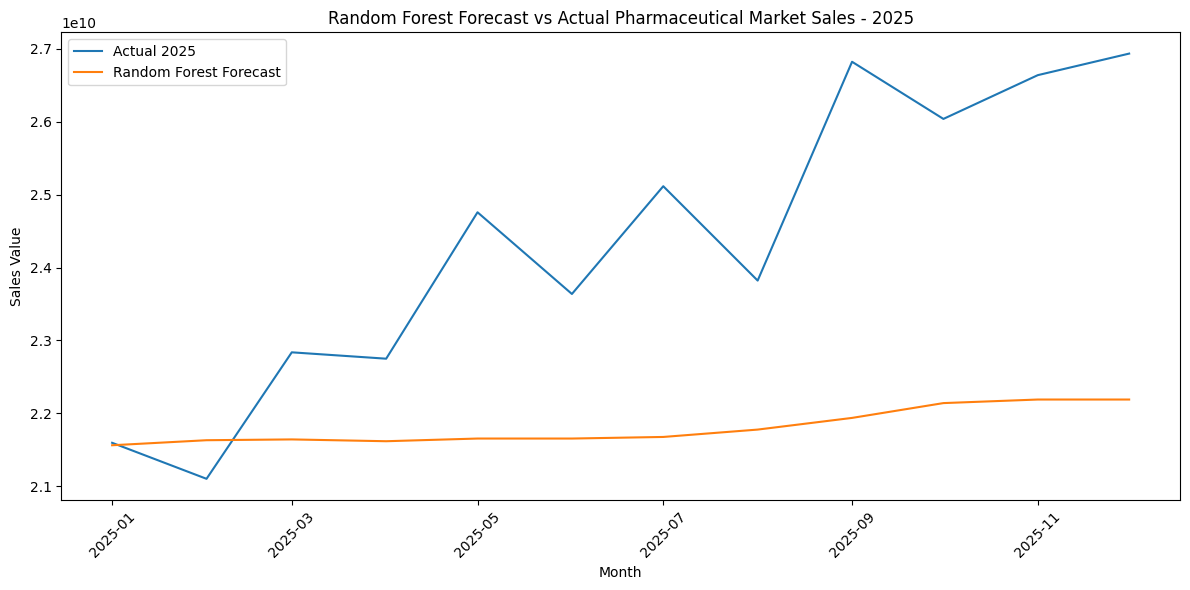

In [321]:
# Plot Random Forest Forecast vs Actual 2025 Sales

plt.figure(figsize=(12, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual 2025"
)

plt.plot(
    test.index,
    rf_predictions,
    label="Random Forest Forecast"
)

plt.title(
    "Random Forest Forecast vs Actual Pharmaceutical Market Sales - 2025"
)

plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Forecasting Model Performance — Business Interpretation

The Random Forest model delivered the strongest forecasting performance among
the evaluated approaches.

Its MAPE of 10.30% represents a substantial improvement over both the Seasonal
Naive baseline (26.17%) and Linear Regression (18.39%).

This indicates that historical sales patterns, seasonal behavior, and recent market
performance provide significant predictive value for pharmaceutical market sales.

From a business perspective, the Random Forest model provides a more reliable
foundation for short-term market planning, sales forecasting, inventory planning,
and commercial decision-making.

Based on the evaluation results, Random Forest was selected as the preferred
forecasting model for future pharmaceutical market projections.

## Future Sales Forecast — Next 12 Months

After evaluating multiple forecasting approaches on the 2025 testing period,
Random Forest achieved the strongest predictive performance with a MAPE of 10.30%.

For the final business forecast, the model is retrained using all available
historical market data from 2021 through 2025.

This allows the final model to benefit from the latest available market information
before generating the next 12-month sales forecast.

The forecast will support:

- Commercial planning
- Sales target setting
- Inventory and supply planning
- Budget preparation
- Market growth assessment
- Strategic decision-making

The forecast horizon covers January 2026 through December 2026.

In [322]:
# Prepare the full historical dataset for the final forecasting model

full_data = pd.DataFrame({
    "Sales": pd.concat([train, test])
}).sort_index()

full_data.head()

,Sales
Month,
2021-01-01,7.838593e+09
2021-02-01,7.254915e+09
2021-03-01,8.702145e+09
2021-04-01,7.727591e+09
2021-05-01,8.863685e+09


In [323]:
# Create forecasting features from the complete historical dataset

rf_full = full_data.copy()

# Time trend
rf_full["Trend"] = np.arange(len(rf_full))

# Seasonal business patterns
rf_full["Month"] = rf_full.index.month
rf_full["Quarter"] = rf_full.index.quarter

# Historical sales performance
rf_full["Lag_1"] = rf_full["Sales"].shift(1)
rf_full["Lag_3"] = rf_full["Sales"].shift(3)
rf_full["Lag_6"] = rf_full["Sales"].shift(6)
rf_full["Lag_12"] = rf_full["Sales"].shift(12)

# Remove rows without sufficient historical information
rf_full = rf_full.dropna()

rf_full.head()

,Sales,Trend,Month,Quarter,Lag_1,Lag_3,Lag_6,Lag_12
Month,,,,,,,,
2022-01-01,8.828284e+09,12,1,1,9.976291e+09,9.757084e+09,7.697453e+09,7.838593e+09
2022-02-01,8.710448e+09,13,2,1,8.828284e+09,1.012290e+10,9.237502e+09,7.254915e+09
2022-03-01,9.596476e+09,14,3,1,8.710448e+09,9.976291e+09,9.975467e+09,8.702145e+09
2022-04-01,7.929274e+09,15,4,2,9.596476e+09,8.828284e+09,9.757084e+09,7.727591e+09
2022-05-01,9.565128e+09,16,5,2,7.929274e+09,8.710448e+09,1.012290e+10,8.863685e+09


In [324]:
# Train the final Random Forest model using all available historical sales data

X_full = rf_full[features]
y_full = rf_full["Sales"]

final_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(
    X_full,
    y_full
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [325]:
# Generate a recursive 12-month forecast for 2026

history = full_data["Sales"].copy()

future_dates = pd.date_range(
    start="2026-01-01",
    periods=12,
    freq="MS"
)

future_predictions = []

for current_date in future_dates:

    # Create time and seasonal features
    trend = len(history)
    month = current_date.month
    quarter = current_date.quarter

    # Create historical lag features
    lag_1 = float(history.iloc[-1])
    lag_3 = float(history.iloc[-3])
    lag_6 = float(history.iloc[-6])
    lag_12 = float(history.iloc[-12])

    current_features = pd.DataFrame({
        "Trend": [trend],
        "Month": [month],
        "Quarter": [quarter],
        "Lag_1": [lag_1],
        "Lag_3": [lag_3],
        "Lag_6": [lag_6],
        "Lag_12": [lag_12]
    })

    # Generate forecast
    prediction = float(
        final_rf_model.predict(
            current_features[features]
        )[0]
    )

    future_predictions.append(prediction)

    # Add forecast to history for the next month's lag features
    history.loc[current_date] = prediction


In [326]:
# Create a business-ready forecast table

forecast_2026 = pd.DataFrame({
    "Month": future_dates,
    "Forecast Sales": future_predictions
})

forecast_2026["Forecast Sales"] = forecast_2026["Forecast Sales"].round(0)

forecast_2026

,Month,Forecast Sales
0,2026-01-01,2.621385e+10
1,2026-02-01,2.615657e+10
2,2026-03-01,2.621573e+10
3,2026-04-01,2.621573e+10
4,2026-05-01,2.621573e+10
5,2026-06-01,2.621573e+10
6,2026-07-01,2.623757e+10
7,2026-08-01,2.624631e+10
8,2026-09-01,2.636431e+10
9,2026-10-01,2.641758e+10


In [327]:
# Calculate total projected sales for 2026

total_forecast_2026 = forecast_2026["Forecast Sales"].sum()

print(
    "Projected Pharmaceutical Market Sales for 2026:",
    round(total_forecast_2026, 2)
)

Projected Pharmaceutical Market Sales for 2026: 315375134495.0


In [328]:
# Compare projected 2026 sales with actual 2025 sales

actual_2025_sales = test.sum()

forecast_growth = (
    (total_forecast_2026 - actual_2025_sales)
    / actual_2025_sales
) * 100

print(
    "2026 Forecasted Growth vs 2025:",
    round(forecast_growth, 2),
    "%"
)

2026 Forecasted Growth vs 2025: 7.98 %


#Projected Pharmaceutical Market Sales for 2026:
2026 Forecasted Growth vs 2025: 7.98%

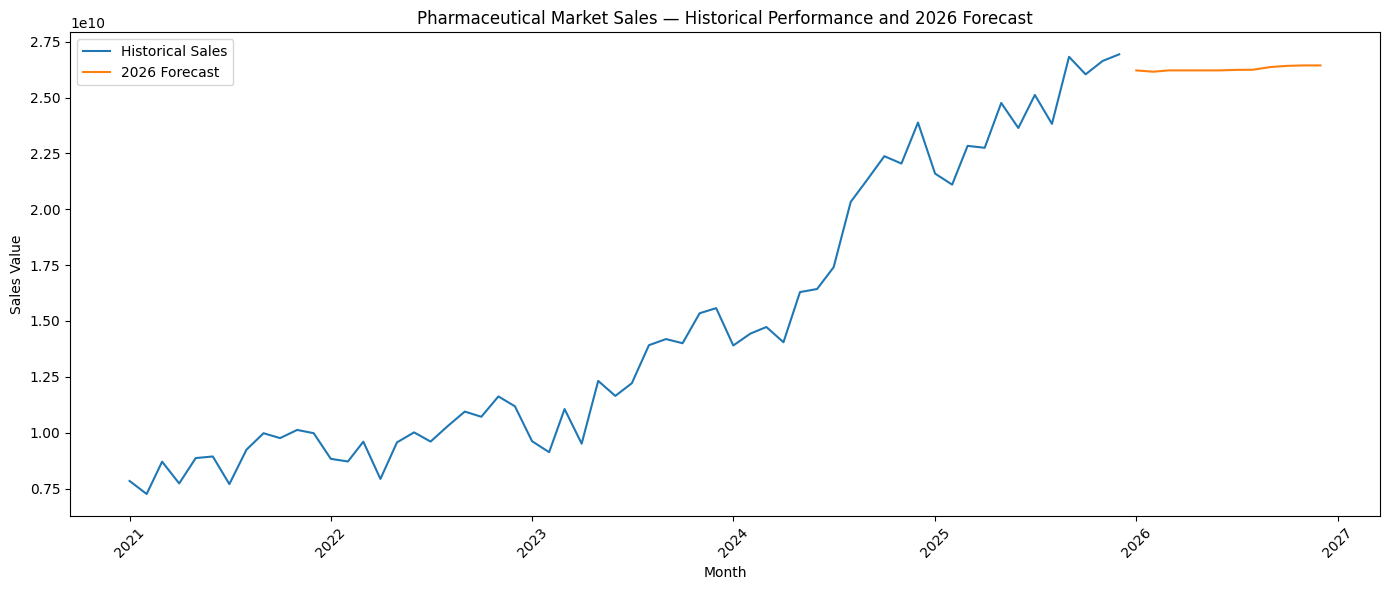

In [329]:
# Plot historical sales and the 2026 market forecast

plt.figure(figsize=(14, 6))

plt.plot(
    full_data.index,
    full_data["Sales"],
    label="Historical Sales"
)

plt.plot(
    forecast_2026["Month"],
    forecast_2026["Forecast Sales"],
    label="2026 Forecast"
)

plt.title(
    "Pharmaceutical Market Sales — Historical Performance and 2026 Forecast"
)

plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


###############

In [330]:
# Brand-level commercial metrics

brand_metrics = (
    df.groupby("Brand Name")
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum"),
        Average_Price=("Selling Price", "mean")
    )
    .reset_index()
)

brand_metrics.head()

,Brand Name,Sales_Value,Sales_Units,Average_Price
0,123,1.197687e+09,60201991.26,35.863071
1,123 EXTRA,8.545135e+07,1808244.50,50.000000
2,2 HC,2.160000e+04,180.00,120.000000
3,3 FLY,2.266616e+07,89483.00,247.337662
4,3 WAY CALCIUM COMP,1.572500e+04,629.00,25.000000


In [331]:
# Calculate overall market share for each brand

total_market_sales = brand_metrics["Sales_Value"].sum()

brand_metrics["Market_Share"] = (
    brand_metrics["Sales_Value"]
    / total_market_sales
    * 100
)

brand_metrics.head()

,Brand Name,Sales_Value,Sales_Units,Average_Price,Market_Share
0,123,1.197687e+09,60201991.26,35.863071,0.135657
1,123 EXTRA,8.545135e+07,1808244.50,50.000000,0.009679
2,2 HC,2.160000e+04,180.00,120.000000,0.000002
3,3 FLY,2.266616e+07,89483.00,247.337662,0.002567
4,3 WAY CALCIUM COMP,1.572500e+04,629.00,25.000000,0.000002


In [332]:
# Calculate Brand CAGR from 2021 to 2025

brand_year = (
    df.groupby(["Brand Name", "Year"])["Sales Value"]
    .sum()
    .reset_index()
)

brand_pivot = (
    brand_year
    .pivot(
        index="Brand Name",
        columns="Year",
        values="Sales Value"
    )
)

brand_pivot = brand_pivot.dropna(subset=[2021, 2025])

brand_pivot["CAGR"] = (
    (brand_pivot[2025] / brand_pivot[2021]) ** (1 / 4) - 1
) * 100

brand_cagr = (
    brand_pivot["CAGR"]
    .reset_index()
    .rename(columns={"CAGR": "CAGR"})
)

brand_cagr.head()

,Brand Name,CAGR
0,123,18.422591
1,5-FLUOROURACIL,-34.927484
2,A VITON,-93.615580
3,ABILIA,-80.815420
4,ABILIFY,24.555656


In [333]:
# Combine all brand-level metrics

brand_segmentation = brand_metrics.merge(
    brand_cagr,
    on="Brand Name",
    how="inner"
)

brand_segmentation.head()

,Brand Name,Sales_Value,Sales_Units,Average_Price,Market_Share,CAGR
0,123,1.197687e+09,60201991.26,35.863071,0.135657,18.422591
1,5-FLUOROURACIL,8.714000e+06,174280.00,50.000000,0.000987,-34.927484
2,A VITON,3.456602e+07,3273145.67,19.000000,0.003915,-93.615580
3,ABILIA,1.562680e+06,13896.96,112.410714,0.000177,-80.815420
4,ABILIFY,2.159864e+08,1143559.90,227.904494,0.024464,24.555656


In [334]:
# Remove invalid values before clustering

brand_segmentation = brand_segmentation.replace(
    [np.inf, -np.inf],
    np.nan
)

brand_segmentation = brand_segmentation.dropna(
    subset=[
        "Sales_Value",
        "Sales_Units",
        "Average_Price",
        "Market_Share",
        "CAGR"
    ]
)

brand_segmentation.shape

(4461, 6)

In [335]:
# Features used for Brand Segmentation

features = [
    "Sales_Value",
    "Sales_Units",
    "Average_Price",
    "Market_Share",
    "CAGR"
]

X = brand_segmentation[features]

X.head()

,Sales_Value,Sales_Units,Average_Price,Market_Share,CAGR
0,1.197687e+09,60201991.26,35.863071,0.135657,18.422591
1,8.714000e+06,174280.00,50.000000,0.000987,-34.927484
2,3.456602e+07,3273145.67,19.000000,0.003915,-93.615580
3,1.562680e+06,13896.96,112.410714,0.000177,-80.815420
4,2.159864e+08,1143559.90,227.904494,0.024464,24.555656


In [336]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [337]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

brand_segmentation["Cluster"] = kmeans.fit_predict(X_scaled)

brand_segmentation.head()

,Brand Name,Sales_Value,Sales_Units,Average_Price,Market_Share,CAGR,Cluster
0,123,1.197687e+09,60201991.26,35.863071,0.135657,18.422591,1
1,5-FLUOROURACIL,8.714000e+06,174280.00,50.000000,0.000987,-34.927484,0
2,A VITON,3.456602e+07,3273145.67,19.000000,0.003915,-93.615580,0
3,ABILIA,1.562680e+06,13896.96,112.410714,0.000177,-80.815420,0
4,ABILIFY,2.159864e+08,1143559.90,227.904494,0.024464,24.555656,0


In [338]:
cluster_size = (
    brand_segmentation["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_size

Cluster
0    4205
1     190
2      27
3      39
Name: count, dtype: int64

In [339]:
cluster_profile = (
    brand_segmentation
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,Sales_Value,Sales_Units,Average_Price,Market_Share,CAGR
Cluster,,,,,
0,1.059678e+08,1929614.63,608.19,0.01,15.05
1,1.953113e+09,35200680.81,197.42,0.22,29.65
2,2.573700e+08,3738.48,104486.86,0.03,64.40
3,5.133038e+07,684445.59,160.62,0.01,1177.75


In [340]:
brand_segmentation[
    [
        "Brand Name",
        "Sales_Value",
        "Sales_Units",
        "Average_Price",
        "Market_Share",
        "CAGR",
        "Cluster"
    ]
].sort_values(
    ["Cluster", "Sales_Value"],
    ascending=[True, False]
).head(30)

,Brand Name,Sales_Value,Sales_Units,Average_Price,Market_Share,CAGR,Cluster
3617,SERETIDE,1.286778e+09,5963548.08,267.108939,0.145748,28.212043,0
1636,FORADIL,1.260846e+09,5665623.55,560.000000,0.142810,9.641520,0
784,CHOLEROSE PLUS,1.253406e+09,6841427.19,204.788506,0.141968,81.066198,0
3759,STARKOPREX,1.249498e+09,6453079.62,165.843373,0.141525,29.031447,0
3715,SOMATROPIN,1.247827e+09,5049666.93,321.000000,0.141336,36.137800,0
1637,FORBUDES,1.240072e+09,4859508.29,274.729299,0.140457,57.528451,0
2312,LIMITLESS OM-3 F/O,1.222956e+09,6149414.41,264.741379,0.138519,265.390124,0
2306,LIMITLESS ALLZ MAX,1.200037e+09,10177276.38,145.000000,0.135923,273.673408,0
3797,SUGARLO PLUS,1.192515e+09,10682055.29,127.440945,0.135071,50.041723,0
3936,THIOTACID,1.188052e+09,9171521.39,170.046377,0.134565,28.330791,0


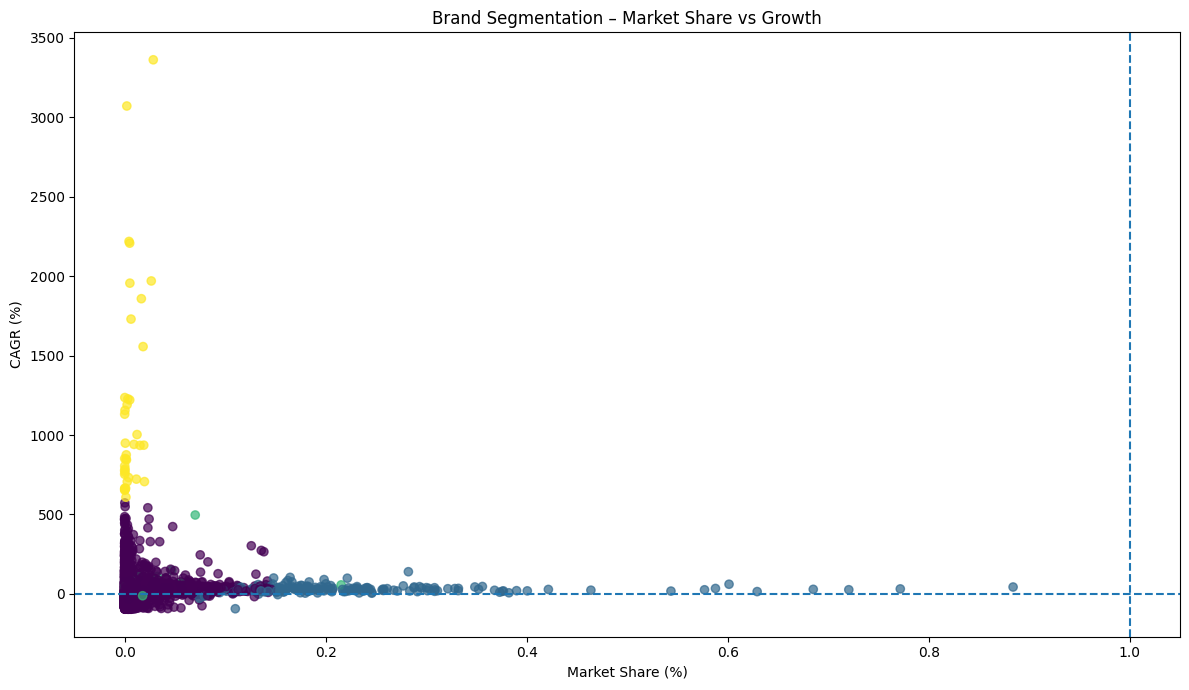

In [341]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(
    brand_segmentation["Market_Share"],
    brand_segmentation["CAGR"],
    c=brand_segmentation["Cluster"],
    alpha=0.7
)

plt.xlabel("Market Share (%)")
plt.ylabel("CAGR (%)")
plt.title("Brand Segmentation – Market Share vs Growth")

plt.axhline(0, linestyle="--")
plt.axvline(1, linestyle="--")

plt.tight_layout()
plt.show()

#“I segmented pharmaceutical brands based on commercial scale, sales volume, pricing, market share, and long-term growth.”

#Phase 1 — Market Intelligence

* Market/Brand performance drivers
* Growth contribution
* Competitive positioning
* Cluster profiling

Phase 2 — Predictive Intelligence

* Predict future brand/market growth
* Identify high-growth / declining brands
* Feature importance
* Scenario analysis

Phase 3 — AI Layer

* Automated business insights
* Brand recommendations
* Opportunity / Risk detection
* Natural-language Market Intelligence summary

Phase 4 — Final Business Dashboard / Portfolio presentation

In [342]:
df.columns.tolist()

['Distribution Channel',
 'Therapeutic Class',
 'Manufacturer',
 'Brand Name',
 'Pack Size',
 'Product Launch',
 'Drug Strength',
 'Selling Price',
 'Market Category',
 'Month',
 'Year',
 'Sales Units',
 'Sales Value',
 'Product Launch Date',
 'Launch Year']

In [343]:
# ============================================================
# CLUSTER PROFILING
# Business Objective:
# Quantify the commercial characteristics of each brand cluster
# to translate the ML segmentation into actionable
# pharmaceutical market segments.
# ============================================================

cluster_profile = (
    brand_segmentation
    .groupby("Cluster")
    .agg(
        Brand_Count=("Brand Name", "nunique"),
        Avg_Sales_Value=("Sales_Value", "mean"),
        Avg_Sales_Units=("Sales_Units", "mean"),
        Avg_Average_Price=("Average_Price", "mean"),
        Avg_Market_Share=("Market_Share", "mean"),
        Avg_CAGR=("CAGR", "mean")
    )
    .reset_index()
)

cluster_profile

,Cluster,Brand_Count,Avg_Sales_Value,Avg_Sales_Units,Avg_Average_Price,Avg_Market_Share,Avg_CAGR
0,0,4205,1.059678e+08,1.929615e+06,608.185257,0.012002,15.051007
1,1,190,1.953113e+09,3.520068e+07,197.418860,0.221220,29.648217
2,2,27,2.573700e+08,3.738481e+03,104486.855485,0.029151,64.399117
3,3,39,5.133038e+07,6.844456e+05,160.615566,0.005814,1177.752850


In [344]:
# Rank clusters based on their overall commercial performance

cluster_profile = cluster_profile.sort_values(
    by=["Avg_Market_Share", "Avg_CAGR"],
    ascending=[False, False]
).reset_index(drop=True)

cluster_profile

,Cluster,Brand_Count,Avg_Sales_Value,Avg_Sales_Units,Avg_Average_Price,Avg_Market_Share,Avg_CAGR
0,1,190,1.953113e+09,3.520068e+07,197.418860,0.221220,29.648217
1,2,27,2.573700e+08,3.738481e+03,104486.855485,0.029151,64.399117
2,0,4205,1.059678e+08,1.929615e+06,608.185257,0.012002,15.051007
3,3,39,5.133038e+07,6.844456e+05,160.615566,0.005814,1177.752850


In [345]:
# Format the cluster profile for easier business interpretation

cluster_profile.style.format({
    'Avg_Market_Share': '{:.2f}%',
    'Avg_CAGR': '{:.2f}%'
})

,Cluster,Brand_Count,Avg_Sales_Value,Avg_Sales_Units,Avg_Average_Price,Avg_Market_Share,Avg_CAGR
0,1,190,1953112795.712632,35200680.806000,197.418860,0.22%,29.65%
1,2,27,257369979.481481,3738.481481,104486.855485,0.03%,64.40%
2,0,4205,105967827.383214,1929614.628093,608.185257,0.01%,15.05%
3,3,39,51330380.032462,684445.592564,160.615566,0.01%,1177.75%


In [346]:
# ============================================================
# BUSINESS VALIDATION:
# Examine the distribution of key performance indicators
# within each cluster to identify outliers and low-base effects.
# ============================================================

cluster_stats = (
    brand_segmentation
    .groupby("Cluster")
    .agg(
        Brand_Count=("Brand Name", "nunique"),
        
        Median_Sales_Value=("Sales_Value", "median"),
        Median_Market_Share=("Market_Share", "median"),
        Median_CAGR=("CAGR", "median"),
        
        Max_Market_Share=("Market_Share", "max"),
        Max_CAGR=("CAGR", "max")
    )
    .reset_index()
)

cluster_stats

,Cluster,Brand_Count,Median_Sales_Value,Median_Market_Share,Median_CAGR,Max_Market_Share,Max_CAGR
0,0,4205,2.464138e+07,0.002791,12.297771,0.145748,572.843924
1,1,190,1.617892e+09,0.183251,26.653673,0.883935,139.657034
2,2,27,1.516246e+08,0.017174,44.860714,0.215407,496.577720
3,3,39,1.898106e+07,0.002150,934.713244,0.028472,3361.080452


#Business Interpretation

Cluster 1 → Market Leaders 🏆

190 brands
Median Sales Value ≈ 1.62B
Median Market Share ≈ 18.3%
Median CAGR ≈ 26.7%

ده أقوى segment بوضوح: high scale + strong market position + healthy growth.

Cluster 2 → Growth Challengers 🚀

27 brands
Median Sales Value ≈ 151.6M
Median Market Share ≈ 1.72%
Median CAGR ≈ 44.9%

الـ market share لسه صغير، لكن النمو قوي جدًا.

Business implication: دي brands تستحق monitoring لأنها ممكن تتحول إلى major players لو استمر النمو.

Cluster 0 → Established / Long Tail

4,205 brands
Median Sales Value ≈ 24.6M
Median Market Share ≈ 0.28%
Median CAGR ≈ 12.3%

وده الجزء الأكبر من السوق من حيث عدد الـ brands، لكنه fragmented جدًا وحصصه محدودة.

Cluster 3 → Emerging High-Growth

39 brands
Median Sales Value ≈ 19.0M
Median Market Share ≈ 0.22%
Median CAGR ≈ 934.7%

وده أهم Cluster محتاج investigation.

الـ CAGR هنا ضخم جدًا، لكن مع Market Share أقل من 1% وSales Value منخفض نسبيًا، فالاحتمال الكبير إن عندنا low-base effec

In [347]:
# ============================================================
# STRATEGIC CLUSTER NAMING
# Business Objective:
# Translate machine-learning clusters into meaningful
# pharmaceutical market segments for strategic interpretation.
# ============================================================

cluster_names = {
    0: "Established / Long Tail",
    1: "Market Leaders",
    2: "Growth Challengers",
    3: "Emerging High-Growth"
}

brand_segmentation["Cluster_Name"] = (
    brand_segmentation["Cluster"].map(cluster_names)
)

brand_segmentation[
    [
        "Brand Name",
        "Cluster",
        "Cluster_Name",
        "Market_Share",
        "CAGR",
        "Sales_Value"
    ]
].head()

,Brand Name,Cluster,Cluster_Name,Market_Share,CAGR,Sales_Value
0,123,1,Market Leaders,0.135657,18.422591,1.197687e+09
1,5-FLUOROURACIL,0,Established / Long Tail,0.000987,-34.927484,8.714000e+06
2,A VITON,0,Established / Long Tail,0.003915,-93.615580,3.456602e+07
3,ABILIA,0,Established / Long Tail,0.000177,-80.815420,1.562680e+06
4,ABILIFY,0,Established / Long Tail,0.024464,24.555656,2.159864e+08


In [348]:
# ============================================================
# STRATEGIC SEGMENT SUMMARY
# ============================================================

strategic_summary = (
    brand_segmentation
    .groupby(["Cluster", "Cluster_Name"])
    .agg(
        Brand_Count=("Brand Name", "nunique"),
        Avg_Sales_Value=("Sales_Value", "mean"),
        Median_Sales_Value=("Sales_Value", "median"),
        Avg_Market_Share=("Market_Share", "mean"),
        Median_Market_Share=("Market_Share", "median"),
        Avg_CAGR=("CAGR", "mean"),
        Median_CAGR=("CAGR", "median")
    )
    .reset_index()
    .sort_values("Cluster")
)

strategic_summary

,Cluster,Cluster_Name,Brand_Count,Avg_Sales_Value,Median_Sales_Value,Avg_Market_Share,Median_Market_Share,Avg_CAGR,Median_CAGR
0,0,Established / Long Tail,4205,1.059678e+08,2.464138e+07,0.012002,0.002791,15.051007,12.297771
1,1,Market Leaders,190,1.953113e+09,1.617892e+09,0.221220,0.183251,29.648217,26.653673
2,2,Growth Challengers,27,2.573700e+08,1.516246e+08,0.029151,0.017174,64.399117,44.860714
3,3,Emerging High-Growth,39,5.133038e+07,1.898106e+07,0.005814,0.002150,1177.752850,934.713244


In [349]:
# ============================================================
# BRAND OPPORTUNITY ANALYSIS
# Business Objective:
# Identify brands with strong commercial scale, market position,
# and growth momentum for strategic prioritization.
# ============================================================

brand_segmentation[
    [
        "Brand Name",
        "Sales_Value",
        "Market_Share",
        "CAGR",
        "Cluster_Name"
    ]
].describe()

,Sales_Value,Market_Share,CAGR
count,4.461000e+03,4.461000e+03,4461.000000
mean,1.850789e+08,2.096305e-02,26.136244
std,4.756956e+08,5.387989e-02,141.352923
min,2.040000e+02,2.310616e-08,-96.520744
25%,4.140983e+06,4.690304e-04,-17.770053
50%,2.842408e+07,3.219467e-03,14.715209
75%,1.454921e+08,1.647923e-02,38.134044
max,7.804095e+09,8.839346e-01,3361.080452


In [350]:
# ============================================================
# BRAND OPPORTUNITY SCORING
# Business Objective:
# Create a robust opportunity score by ranking brands
# relative to the overall market rather than using raw values.
# This reduces the impact of extreme outliers in CAGR.
# ============================================================

from sklearn.preprocessing import MinMaxScaler

opportunity_data = brand_segmentation[
    [
        "Brand Name",
        "Sales_Value",
        "Market_Share",
        "CAGR",
        "Cluster_Name"
    ]
].copy()

# Convert each metric into a percentile rank
opportunity_data["Sales_Score"] = (
    opportunity_data["Sales_Value"].rank(pct=True) * 100
)

opportunity_data["Market_Share_Score"] = (
    opportunity_data["Market_Share"].rank(pct=True) * 100
)

opportunity_data["Growth_Score"] = (
    opportunity_data["CAGR"].rank(pct=True) * 100
)

opportunity_data.head()

,Brand Name,Sales_Value,Market_Share,CAGR,Cluster_Name,Sales_Score,Market_Share_Score,Growth_Score
0,123,1.197687e+09,0.135657,18.422591,Market Leaders,96.301278,96.301278,54.360009
1,5-FLUOROURACIL,8.714000e+06,0.000987,-34.927484,Established / Long Tail,33.310917,33.310917,17.664201
2,A VITON,3.456602e+07,0.003915,-93.615580,Established / Long Tail,52.746021,52.746021,0.515579
3,ABILIA,1.562680e+06,0.000177,-80.815420,Established / Long Tail,14.929388,14.929388,4.819547
4,ABILIFY,2.159864e+08,0.024464,24.555656,Established / Long Tail,81.013226,81.013226,61.241874


In [351]:
# ============================================================
# COMPOSITE OPPORTUNITY SCORE
# Weighting:
# 40% Growth Momentum
# 35% Market Position
# 25% Commercial Scale
# ============================================================

opportunity_data["Opportunity_Score"] = (
    opportunity_data["Growth_Score"] * 0.40
    + opportunity_data["Market_Share_Score"] * 0.35
    + opportunity_data["Sales_Score"] * 0.25
)

opportunity_data = opportunity_data.sort_values(
    "Opportunity_Score",
    ascending=False
).reset_index(drop=True)

opportunity_data.head(20)

,Brand Name,Sales_Value,Market_Share,CAGR,Cluster_Name,Sales_Score,Market_Share_Score,Growth_Score,Opportunity_Score
0,OZEMPIC,2.492269e+09,0.282288,139.657034,Market Leaders,99.148173,99.148173,95.270119,97.596951
1,LIMITLESS ALLZ MAX,1.200037e+09,0.135923,273.673408,Established / Long Tail,96.346111,96.346111,97.960099,96.991706
2,LIMITLESS OM-3 F/O,1.222956e+09,0.138519,265.390124,Established / Long Tail,96.413360,96.413360,97.825600,96.978256
3,SANSOVIT PLUS,1.112443e+09,0.126001,302.948059,Established / Long Tail,95.875364,95.875364,98.229097,96.816857
4,METHYLTECHNO,1.955909e+09,0.221537,98.896725,Market Leaders,98.475678,98.475678,92.692221,96.162295
5,HERO BABY 1,1.751656e+09,0.198402,90.248946,Market Leaders,98.161847,98.161847,92.064560,95.722932
6,ZYROVAZET,1.453299e+09,0.164609,104.049702,Market Leaders,97.332437,97.332437,93.230217,95.691549
7,LIMITLESS WOMAN MX,1.153053e+09,0.130601,124.199708,Established / Long Tail,96.032280,96.032280,94.597624,95.458417
8,HERO BABY 2,1.308899e+09,0.148253,100.070885,Market Leaders,96.839274,96.839274,92.849137,95.243219
9,PHESGO,6.198055e+08,0.070203,496.577720,Growth Challengers,92.535306,92.535306,99.058507,95.144586


In [352]:
# ============================================================
# REFINED OPPORTUNITY SCORE
# Business Objective:
# Prioritize brands based on market position and growth momentum
# while avoiding double-counting highly correlated sales metrics.
# ============================================================

opportunity_data["Strategic_Opportunity_Score"] = (
    opportunity_data["Growth_Score"] * 0.55
    + opportunity_data["Market_Share_Score"] * 0.45
)

opportunity_data = opportunity_data.sort_values(
    "Strategic_Opportunity_Score",
    ascending=False
).reset_index(drop=True)

opportunity_data.head(20)

,Brand Name,Sales_Value,Market_Share,CAGR,Cluster_Name,Sales_Score,Market_Share_Score,Growth_Score,Opportunity_Score,Strategic_Opportunity_Score
0,LIMITLESS ALLZ MAX,1.200037e+09,0.135923,273.673408,Established / Long Tail,96.346111,96.346111,97.960099,96.991706,97.233804
1,LIMITLESS OM-3 F/O,1.222956e+09,0.138519,265.390124,Established / Long Tail,96.413360,96.413360,97.825600,96.978256,97.190092
2,SANSOVIT PLUS,1.112443e+09,0.126001,302.948059,Established / Long Tail,95.875364,95.875364,98.229097,96.816857,97.169917
3,OZEMPIC,2.492269e+09,0.282288,139.657034,Market Leaders,99.148173,99.148173,95.270119,97.596951,97.015243
4,PHESGO,6.198055e+08,0.070203,496.577720,Growth Challengers,92.535306,92.535306,99.058507,95.144586,96.123067
5,MOVENTOR,6.639515e+08,0.075203,245.706830,Established / Long Tail,93.118135,93.118135,97.556602,94.893522,95.559292
6,EPICOPRED,7.313985e+08,0.082842,201.748497,Established / Long Tail,93.790630,93.790630,96.973773,95.063887,95.541358
7,METHYLTECHNO,1.955909e+09,0.221537,98.896725,Market Leaders,98.475678,98.475678,92.692221,96.162295,95.294777
8,LIMITLESS WOMAN MX,1.153053e+09,0.130601,124.199708,Established / Long Tail,96.032280,96.032280,94.597624,95.458417,95.243219
9,ZYROVAZET,1.453299e+09,0.164609,104.049702,Market Leaders,97.332437,97.332437,93.230217,95.691549,95.076216


In [353]:
# ============================================================
# STRATEGIC OPPORTUNITY CLASSIFICATION
# Business Objective:
# Convert the numerical opportunity score into actionable
# strategic categories for market intelligence decisions.
# ============================================================

opportunity_data["Opportunity_Tier"] = pd.qcut(
    opportunity_data["Strategic_Opportunity_Score"],
    q=4,
    labels=[
        "Low Priority",
        "Monitor",
        "Strategic Opportunity",
        "High Priority"
    ]
)

opportunity_data[
    [
        "Brand Name",
        "Cluster_Name",
        "Market_Share",
        "CAGR",
        "Strategic_Opportunity_Score",
        "Opportunity_Tier"
    ]
].head(20)

,Brand Name,Cluster_Name,Market_Share,CAGR,Strategic_Opportunity_Score,Opportunity_Tier
0,LIMITLESS ALLZ MAX,Established / Long Tail,0.135923,273.673408,97.233804,High Priority
1,LIMITLESS OM-3 F/O,Established / Long Tail,0.138519,265.390124,97.190092,High Priority
2,SANSOVIT PLUS,Established / Long Tail,0.126001,302.948059,97.169917,High Priority
3,OZEMPIC,Market Leaders,0.282288,139.657034,97.015243,High Priority
4,PHESGO,Growth Challengers,0.070203,496.577720,96.123067,High Priority
5,MOVENTOR,Established / Long Tail,0.075203,245.706830,95.559292,High Priority
6,EPICOPRED,Established / Long Tail,0.082842,201.748497,95.541358,High Priority
7,METHYLTECHNO,Market Leaders,0.221537,98.896725,95.294777,High Priority
8,LIMITLESS WOMAN MX,Established / Long Tail,0.130601,124.199708,95.243219,High Priority
9,ZYROVAZET,Market Leaders,0.164609,104.049702,95.076216,High Priority


In [354]:
# ============================================================
# OPPORTUNITY TIER SUMMARY
# ============================================================

opportunity_summary = (
    opportunity_data
    .groupby("Opportunity_Tier", observed=True)
    .agg(
        Brand_Count=("Brand Name", "nunique"),
        Avg_Market_Share=("Market_Share", "mean"),
        Avg_CAGR=("CAGR", "mean"),
        Avg_Opportunity_Score=("Strategic_Opportunity_Score", "mean")
    )
    .reset_index()
)

opportunity_summary

,Opportunity_Tier,Brand_Count,Avg_Market_Share,Avg_CAGR,Avg_Opportunity_Score
0,Low Priority,1116,0.000629,-47.145474,17.677656
1,Monitor,1115,0.004721,0.113616,41.487902
2,Strategic Opportunity,1115,0.015396,61.145480,61.743022
3,High Priority,1115,0.063124,90.497078,79.165252


#Does a brand's strategic opportunity align with its overall market segment?



Market Leader + High Priority → Defend & Invest
Growth Challenger + High Priority → Accelerate
Emerging High-Growth + High Priority → Validate & Scale
Long Tail + Low Priority → Deprioritize

In [355]:
# ============================================================
# CLUSTER × OPPORTUNITY MATRIX
# Business Objective:
# Combine market segmentation with opportunity prioritization
# to identify the strategic action required for each brand group.
# ============================================================

cluster_opportunity = pd.crosstab(
    brand_segmentation["Cluster_Name"],
    opportunity_data["Opportunity_Tier"]
)

cluster_opportunity

Opportunity_Tier,Low Priority,Monitor,Strategic Opportunity,High Priority
Cluster_Name,,,,
Emerging High-Growth,14,10,7,8
Established / Long Tail,1057,1059,1046,1043
Growth Challengers,6,7,10,4
Market Leaders,39,39,52,60


In [356]:
# ============================================================
# ROBUST CLUSTER × OPPORTUNITY ANALYSIS
# Business Objective:
# Link each brand's opportunity classification to its
# strategic market cluster using the brand name as the key.
# ============================================================

cluster_opportunity_data = brand_segmentation[
    ["Brand Name", "Cluster_Name"]
].merge(
    opportunity_data[
        ["Brand Name", "Opportunity_Tier"]
    ],
    on="Brand Name",
    how="inner"
)

cluster_opportunity = pd.crosstab(
    cluster_opportunity_data["Cluster_Name"],
    cluster_opportunity_data["Opportunity_Tier"]
)

cluster_opportunity

Opportunity_Tier,Low Priority,Monitor,Strategic Opportunity,High Priority
Cluster_Name,,,,
Emerging High-Growth,0,0,15,24
Established / Long Tail,1116,1107,1077,905
Growth Challengers,0,6,4,17
Market Leaders,0,2,19,169


In [357]:
# ============================================================
# OPPORTUNITY MIX BY CLUSTER
# Shows the percentage distribution of opportunity tiers
# within each strategic market segment.
# ============================================================

cluster_opportunity_pct = (
    pd.crosstab(
        cluster_opportunity_data["Cluster_Name"],
        cluster_opportunity_data["Opportunity_Tier"],
        normalize="index"
    ) * 100
)

cluster_opportunity_pct.round(2)

Opportunity_Tier,Low Priority,Monitor,Strategic Opportunity,High Priority
Cluster_Name,,,,
Emerging High-Growth,0.00,0.00,38.46,61.54
Established / Long Tail,26.54,26.33,25.61,21.52
Growth Challengers,0.00,22.22,14.81,62.96
Market Leaders,0.00,1.05,10.00,88.95


#What proportion of each strategic segment represents a genuine commercial opportunity?

In [358]:
# ============================================================
# STRATEGIC ACTION ASSIGNMENT
# Business Objective:
# Translate cluster position and opportunity level into
# actionable pharmaceutical market strategies.
# ============================================================

def assign_strategy(row):

    cluster = row["Cluster_Name"]
    tier = row["Opportunity_Tier"]

    if cluster == "Market Leaders" and tier == "High Priority":
        return "Defend & Invest"

    elif cluster == "Growth Challengers" and tier == "High Priority":
        return "Accelerate"

    elif cluster == "Emerging High-Growth" and tier in [
        "High Priority",
        "Strategic Opportunity"
    ]:
        return "Validate & Scale"

    elif cluster == "Established / Long Tail" and tier in [
        "High Priority",
        "Strategic Opportunity"
    ]:
        return "Selective Investment"

    elif tier == "Monitor":
        return "Monitor"

    else:
        return "Deprioritize"


cluster_opportunity_data["Strategic_Action"] = (
    cluster_opportunity_data.apply(assign_strategy, axis=1)
)

cluster_opportunity_data.head()

,Brand Name,Cluster_Name,Opportunity_Tier,Strategic_Action
0,123,Market Leaders,High Priority,Defend & Invest
1,5-FLUOROURACIL,Established / Long Tail,Low Priority,Deprioritize
2,A VITON,Established / Long Tail,Low Priority,Deprioritize
3,ABILIA,Established / Long Tail,Low Priority,Deprioritize
4,ABILIFY,Established / Long Tail,Strategic Opportunity,Selective Investment


In [359]:
# ============================================================
# FINAL BRAND INTELLIGENCE TABLE
# ============================================================

brand_intelligence = (
    brand_segmentation[
        [
            "Brand Name",
            "Sales_Value",
            "Market_Share",
            "CAGR",
            "Cluster_Name"
        ]
    ]
    .merge(
        opportunity_data[
            [
                "Brand Name",
                "Strategic_Opportunity_Score",
                "Opportunity_Tier"
            ]
        ],
        on="Brand Name",
        how="inner"
    )
    .merge(
        cluster_opportunity_data[
            [
                "Brand Name",
                "Strategic_Action"
            ]
        ],
        on="Brand Name",
        how="inner"
    )
)

brand_intelligence.head(20)

,Brand Name,Sales_Value,Market_Share,CAGR,Cluster_Name,Strategic_Opportunity_Score,Opportunity_Tier,Strategic_Action
0,123,1.197687e+09,0.135657,18.422591,Market Leaders,73.233580,High Priority,Defend & Invest
1,5-FLUOROURACIL,8.714000e+06,0.000987,-34.927484,Established / Long Tail,24.705223,Low Priority,Deprioritize
2,A VITON,3.456602e+07,0.003915,-93.615580,Established / Long Tail,24.019278,Low Priority,Deprioritize
3,ABILIA,1.562680e+06,0.000177,-80.815420,Established / Long Tail,9.368976,Low Priority,Deprioritize
4,ABILIFY,2.159864e+08,0.024464,24.555656,Established / Long Tail,70.138982,Strategic Opportunity,Selective Investment
5,ABIMOL,3.210055e+08,0.036359,31.725822,Established / Long Tail,76.685721,High Priority,Selective Investment
6,ABIMOL EXTRA,1.036795e+08,0.011743,14.784645,Established / Long Tail,59.027124,Strategic Opportunity,Selective Investment
7,ACANTHAPROP,1.074934e+06,0.000122,24.882560,Established / Long Tail,39.222148,Monitor,Monitor
8,ACCUCHECK,5.092896e+08,0.057685,14.736625,Established / Long Tail,68.349025,Strategic Opportunity,Selective Investment
9,ACELIOFENAZ,8.185373e+04,0.000009,28.497054,Established / Long Tail,37.221475,Monitor,Monitor


In [360]:
# ============================================================
# STRATEGIC ACTION DISTRIBUTION
# Business Objective:
# Understand how the pharmaceutical market is distributed
# across the recommended strategic actions.
# ============================================================

brand_intelligence["Strategic_Action"].value_counts()

Strategic_Action
Selective Investment    1982
Deprioritize            1139
Monitor                 1115
Defend & Invest          169
Validate & Scale          39
Accelerate                17
Name: count, dtype: int64

#Predictive Intelligence 🔮

In [361]:
# ============================================================
# PREDICTIVE INTELLIGENCE — DATA READINESS CHECK
# Business Objective:
# Verify whether historical time-series information is available
# before building a predictive growth model.
# ============================================================

print("Shape:", brand_segmentation.shape)

print("\nColumns:")
print(brand_segmentation.columns.tolist())

Shape: (4461, 8)

Columns:
['Brand Name', 'Sales_Value', 'Sales_Units', 'Average_Price', 'Market_Share', 'CAGR', 'Cluster', 'Cluster_Name']


In [362]:
# Preview the available data structure

brand_segmentation.head()

,Brand Name,Sales_Value,Sales_Units,Average_Price,Market_Share,CAGR,Cluster,Cluster_Name
0,123,1.197687e+09,60201991.26,35.863071,0.135657,18.422591,1,Market Leaders
1,5-FLUOROURACIL,8.714000e+06,174280.00,50.000000,0.000987,-34.927484,0,Established / Long Tail
2,A VITON,3.456602e+07,3273145.67,19.000000,0.003915,-93.615580,0,Established / Long Tail
3,ABILIA,1.562680e+06,13896.96,112.410714,0.000177,-80.815420,0,Established / Long Tail
4,ABILIFY,2.159864e+08,1143559.90,227.904494,0.024464,24.555656,0,Established / Long Tail


In [363]:
%whos

Variable                   Type                         Data/Info
-----------------------------------------------------------------
ExponentialSmoothing       type                         <class 'statsmodels.tsa.h<...>el.ExponentialSmoothing'>
KMeans                     ABCMeta                      <class 'sklearn.cluster._kmeans.KMeans'>
LinearRegression           ABCMeta                      <class 'sklearn.linear_mo<...>._base.LinearRegression'>
MinMaxScaler               type                         <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
RandomForestRegressor      ABCMeta                      <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
StandardScaler             type                         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                          DataFrame                           Sales_Value  Sales<...>\n[4461 rows x 5 columns]
X_2025                     DataFrame                    Year                    2<...>\n[4303 rows 

#🎯 Brand-Level Predictive Intelligence
Which pharmaceutical brands are expected to generate the strongest sales performance in 2026?

In [364]:
# ============================================================
# BRAND-LEVEL TIME SERIES VALIDATION
# Business Objective:
# Validate the historical sales structure available at brand
# level before building the 2026 predictive model.
# ============================================================

print("Shape:", brand_pivot.shape)

print("\nColumns:")
print(brand_pivot.columns.tolist())

print("\nSample:")
brand_pivot.head()

Shape: (4461, 6)

Columns:
[2021, 2022, 2023, 2024, 2025, 'CAGR']

Sample:


Year,2021,2022,2023,2024,2025,CAGR
Brand Name,,,,,,
123,156711771.0,2.399843e+08,204705693.0,288080106.5,308205128.0,18.422591
5-FLUOROURACIL,2010550.0,2.181200e+06,1278700.0,2883050.0,360500.0,-34.927484
A VITON,11435832.0,7.738047e+06,14889754.0,502198.0,190.0,-93.615580
ABILIA,775140.0,3.759702e+05,320325.0,90195.0,1050.0,-80.815420
ABILIFY,27232524.0,2.971305e+07,39743972.5,53751583.5,65545323.5,24.555656


2021 ──┐
2022 ──┤
2023 ──┤──► ML Model ──► 2025 Prediction
2024 ──┘



2022 ──┐
2023 ──┤
2024 ──┤──► Final Model ──► 2026 Prediction
2025 ──┘

In [365]:
# ============================================================
# BRAND-LEVEL TIME SERIES PREPARATION
# ============================================================

brand_ts = brand_pivot[
    ["2021", "2022", "2023", "2024", "2025"]
].copy() if "2021" in brand_pivot.columns else brand_pivot[
    [2021, 2022, 2023, 2024, 2025]
].copy()

# Create lag features for predicting the next year's sales
brand_ts["Lag_1"] = brand_ts[2024]
brand_ts["Lag_2"] = brand_ts[2023]
brand_ts["Lag_3"] = brand_ts[2022]

# Year-over-year growth
brand_ts["Growth_2024"] = (
    (brand_ts[2024] - brand_ts[2023])
    / brand_ts[2023].replace(0, np.nan)
) * 100

brand_ts["Growth_2023"] = (
    (brand_ts[2023] - brand_ts[2022])
    / brand_ts[2022].replace(0, np.nan)
) * 100

brand_ts.head()

Year,2021,2022,2023,2024,2025,Lag_1,Lag_2,Lag_3,Growth_2024,Growth_2023
Brand Name,,,,,,,,,,
123,156711771.0,2.399843e+08,204705693.0,288080106.5,308205128.0,288080106.5,204705693.0,2.399843e+08,40.728918,-14.700384
5-FLUOROURACIL,2010550.0,2.181200e+06,1278700.0,2883050.0,360500.0,2883050.0,1278700.0,2.181200e+06,125.467271,-41.376307
A VITON,11435832.0,7.738047e+06,14889754.0,502198.0,190.0,502198.0,14889754.0,7.738047e+06,-96.627224,92.422640
ABILIA,775140.0,3.759702e+05,320325.0,90195.0,1050.0,90195.0,320325.0,3.759702e+05,-71.842660,-14.800428
ABILIFY,27232524.0,2.971305e+07,39743972.5,53751583.5,65545323.5,53751583.5,39743972.5,2.971305e+07,35.244617,33.759336


In [366]:
# ============================================================
# 2025 BRAND SALES BACKTEST
# Business Objective:
# Evaluate whether historical sales patterns can predict
# the following year's brand sales.
# ============================================================

model_data = brand_ts[
    [
        2022,
        2023,
        2024,
        2025,
        "Growth_2023",
        "Growth_2024"
    ]
].copy()

# Remove invalid values caused by zero historical sales
model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ============================================================
# FIX FEATURE COLUMN TYPES
# ============================================================

X_2025 = model_data[
    [
        2022,
        2023,
        2024,
        "Growth_2023",
        "Growth_2024"
    ]
].copy()

y_2025 = model_data[2025].copy()

# Make all feature names strings
X_2025.columns = X_2025.columns.astype(str)

print("Features:")
print(X_2025.columns.tolist())

print("\nShape:")
print(X_2025.shape)

Features:
['2022', '2023', '2024', 'Growth_2023', 'Growth_2024']

Shape:
(4303, 5)


#2022–2024 → Features
2025 → Target

In [367]:
# ============================================================
# LINEAR REGRESSION — 2025 BACKTEST
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_brand_model = LinearRegression()

lr_brand_model.fit(
    X_2025,
    y_2025
)

lr_brand_pred = lr_brand_model.predict(X_2025)

lr_brand_mae = mean_absolute_error(
    y_2025,
    lr_brand_pred
)

lr_brand_rmse = np.sqrt(
    mean_squared_error(
        y_2025,
        lr_brand_pred
    )
)

lr_brand_r2 = r2_score(
    y_2025,
    lr_brand_pred
)

print("Linear Regression")
print("-----------------")
print("MAE :", lr_brand_mae)
print("RMSE:", lr_brand_rmse)
print("R²  :", lr_brand_r2)

Linear Regression
-----------------
MAE : 14566314.984338919
RMSE: 38910318.984716654
R²  : 0.9414594464407254


In [368]:
# ============================================================
# RANDOM FOREST — 2025 BRAND SALES MODEL
# Business Objective:
# Capture nonlinear relationships between historical sales
# patterns and next-year brand performance.
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_brand_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_brand_model.fit(
    X_2025,
    y_2025
)

rf_brand_pred = rf_brand_model.predict(X_2025)

rf_brand_mae = mean_absolute_error(
    y_2025,
    rf_brand_pred
)

rf_brand_rmse = np.sqrt(
    mean_squared_error(
        y_2025,
        rf_brand_pred
    )
)

rf_brand_r2 = r2_score(
    y_2025,
    rf_brand_pred
)

print("Random Forest")
print("-------------")
print("MAE :", rf_brand_mae)
print("RMSE:", rf_brand_rmse)
print("R²  :", rf_brand_r2)

Random Forest
-------------
MAE : 11666864.464888541
RMSE: 35324820.357403874
R²  : 0.9517511277903079


In [369]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance = (
    pd.DataFrame({
        "Feature": X_2025.columns,
        "Importance": rf_brand_model.feature_importances_
    })
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,2024,0.889181
1,2023,0.084318
2,2022,0.018081
3,Growth_2024,0.004580
4,Growth_2023,0.003840


#Which historical signals are most useful for predicting next-year pharmaceutical brand sales?

#Recent commercial scale is the strongest predictor of next-year brand sales.

2021 → 2022
2022 → 2023
2023 → 2024
2024 → 2025

In [370]:
# ============================================================
# TEMPORAL BRAND FORECASTING DATASET
# Business Objective:
# Create multiple historical brand-year observations to
# evaluate next-year sales prediction without data leakage.
# ============================================================

temporal_rows = []

for year in [2022, 2023, 2024, 2025]:

    previous_year = year - 1

    temp = brand_pivot[
        [previous_year, year]
    ].copy()

    temp["Lag_1"] = temp[previous_year]

    temp["Year"] = year

    temp["Target_Sales"] = temp[year]

    temporal_rows.append(
        temp[
            [
                "Lag_1",
                "Year",
                "Target_Sales"
            ]
        ]
    )

temporal_data = pd.concat(
    temporal_rows,
    ignore_index=True
)

temporal_data.head()

Year,Lag_1,Year,Target_Sales
0,156711771.0,2022,2.399843e+08
1,2010550.0,2022,2.181200e+06
2,11435832.0,2022,7.738047e+06
3,775140.0,2022,3.759702e+05
4,27232524.0,2022,2.971305e+07


In [371]:
temporal_data.shape

(17844, 3)

In [372]:
temporal_data.groupby("Year").size()

Year
2022    4461
2023    4461
2024    4461
2025    4461
dtype: int64

In [373]:
# ============================================================
# TEMPORAL FEATURE ENGINEERING
# Business Objective:
# Capture brand sales momentum, historical scale, and
# trajectory to improve next-year sales prediction.
# ============================================================

temporal_rows = []

for year in [2022, 2023, 2024, 2025]:

    previous_year = year - 1

    # Required historical years
    required_years = [
        previous_year,
        previous_year - 1,
        previous_year - 2
    ]

    # Skip years where full history is unavailable
    if not all(
        y in brand_pivot.columns
        for y in required_years
    ):
        continue

    temp = brand_pivot[
        required_years
    ].copy()

    temp["Target_Sales"] = brand_pivot[year]

    temp["Lag_1"] = brand_pivot[previous_year]
    temp["Lag_2"] = brand_pivot[previous_year - 1]
    temp["Lag_3"] = brand_pivot[previous_year - 2]

    # One-year growth
    temp["Growth_1Y"] = (
        (
            temp["Lag_1"] - temp["Lag_2"]
        )
        / temp["Lag_2"].replace(0, np.nan)
    ) * 100

    # Two-year historical growth
    temp["Growth_2Y"] = (
        (
            temp["Lag_2"] - temp["Lag_3"]
        )
        / temp["Lag_3"].replace(0, np.nan)
    ) * 100

    temp["Year"] = year

    temporal_rows.append(
        temp[
            [
                "Lag_1",
                "Lag_2",
                "Lag_3",
                "Growth_1Y",
                "Growth_2Y",
                "Year",
                "Target_Sales"
            ]
        ]
    )

temporal_data = pd.concat(
    temporal_rows,
    ignore_index=True
)

# Clean extreme / invalid values
temporal_data = temporal_data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

print("Temporal dataset shape:", temporal_data.shape)
temporal_data.head()

Temporal dataset shape: (8606, 7)


Year,Lag_1,Lag_2,Lag_3,Growth_1Y,Growth_2Y,Year,Target_Sales
0,204705693.0,2.399843e+08,156711771.0,-14.700384,53.137386,2024,288080106.5
1,1278700.0,2.181200e+06,2010550.0,-41.376307,8.487727,2024,2883050.0
2,14889754.0,7.738047e+06,11435832.0,92.422640,-32.335078,2024,502198.0
3,320325.0,3.759702e+05,775140.0,-14.800428,-51.496478,2024,90195.0
4,39743972.5,2.971305e+07,27232524.0,33.759336,9.108673,2024,53751583.5


2022 + 2023 + 2024 → TRAIN
2025              → TEST

In [374]:
# ============================================================
# TEMPORAL TRAIN / TEST SPLIT
# Business Objective:
# Simulate a real forecasting scenario where only historical
# information is used to predict the following year.
# ============================================================

train_data = temporal_data[
    temporal_data["Year"] < 2025
].copy()

test_data = temporal_data[
    temporal_data["Year"] == 2025
].copy()

features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Growth_1Y",
    "Growth_2Y"
]

X_train_temporal = train_data[features].copy()
y_train_temporal = train_data["Target_Sales"].copy()

X_test_temporal = test_data[features].copy()
y_test_temporal = test_data["Target_Sales"].copy()

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

Training observations: 4303
Testing observations: 4303


In [375]:
# ============================================================
# TEMPORAL RANDOM FOREST
# ============================================================

rf_temporal = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_temporal.fit(
    X_train_temporal,
    y_train_temporal
)

rf_temporal_pred = rf_temporal.predict(
    X_test_temporal
)

In [376]:
# ============================================================
# OUT-OF-SAMPLE EVALUATION
# ============================================================

temporal_mae = mean_absolute_error(
    y_test_temporal,
    rf_temporal_pred
)

temporal_rmse = np.sqrt(
    mean_squared_error(
        y_test_temporal,
        rf_temporal_pred
    )
)

temporal_r2 = r2_score(
    y_test_temporal,
    rf_temporal_pred
)

print("Temporal Random Forest")
print("----------------------")
print("MAE :", temporal_mae)
print("RMSE:", temporal_rmse)
print("R²  :", temporal_r2)

Temporal Random Forest
----------------------
MAE : 19512486.374660924
RMSE: 57068494.72951199
R²  : 0.8740726461380314


In [377]:
# ============================================================
# BRAND-LEVEL FORECAST ERROR ANALYSIS
# Business Objective:
# Identify where the predictive model performs well or poorly
# across pharmaceutical brands.
# ============================================================

test_results = test_data.copy()

test_results["Predicted_Sales_2025"] = rf_temporal_pred

test_results["Absolute_Error"] = (
    abs(
        test_results["Target_Sales"]
        - test_results["Predicted_Sales_2025"]
    )
)

test_results["APE"] = (
    test_results["Absolute_Error"]
    / test_results["Target_Sales"].replace(0, np.nan)
) * 100

test_results[
    [
        "Target_Sales",
        "Predicted_Sales_2025",
        "Absolute_Error",
        "APE"
    ]
].describe()

Year,Target_Sales,Predicted_Sales_2025,Absolute_Error,APE
count,4.303000e+03,4.303000e+03,4.303000e+03,4.303000e+03
mean,6.029118e+07,6.654137e+07,1.951249e+07,4.663601e+04
std,1.608373e+08,1.605205e+08,5.363529e+07,6.504633e+05
min,7.000000e+00,8.039716e+04,1.953213e+02,3.164349e-02
25%,4.491930e+05,1.099244e+06,4.671835e+05,2.031794e+01
50%,6.668935e+06,9.257367e+06,3.017084e+06,5.113646e+01
75%,4.525873e+07,4.751221e+07,1.586020e+07,1.752671e+02
max,3.055873e+09,1.423837e+09,1.632035e+09,3.323550e+07


In [378]:
# ============================================================
# REBUILD TEMPORAL DATA WITH BRAND IDENTIFIERS
# ============================================================

temporal_rows = []

for year in [2024, 2025]:

    previous_year = year - 1

    temp = brand_pivot[
        [previous_year, previous_year - 1, previous_year - 2, year]
    ].copy()

    temp["Brand Name"] = temp.index

    temp["Lag_1"] = temp[previous_year]
    temp["Lag_2"] = temp[previous_year - 1]
    temp["Lag_3"] = temp[previous_year - 2]

    temp["Growth_1Y"] = (
        (temp["Lag_1"] - temp["Lag_2"])
        / temp["Lag_2"].replace(0, np.nan)
    ) * 100

    temp["Growth_2Y"] = (
        (temp["Lag_2"] - temp["Lag_3"])
        / temp["Lag_3"].replace(0, np.nan)
    ) * 100

    temp["Year"] = year
    temp["Target_Sales"] = temp[year]

    temporal_rows.append(
        temp[
            [
                "Brand Name",
                "Lag_1",
                "Lag_2",
                "Lag_3",
                "Growth_1Y",
                "Growth_2Y",
                "Year",
                "Target_Sales"
            ]
        ]
    )

temporal_data = pd.concat(
    temporal_rows,
    ignore_index=True
)

temporal_data = temporal_data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

print(temporal_data.shape)

(8606, 8)


In [379]:
# ============================================================
# ERROR ANALYSIS BY BRAND SALES SIZE
# Business Objective:
# Evaluate forecast accuracy across different brand
# commercial scales and identify where the model performs
# best and where additional modeling may be required.
# ============================================================

test_results["Sales_Band"] = pd.qcut(
    test_results["Target_Sales"],
    q=4,
    labels=[
        "Low Sales",
        "Mid-Low Sales",
        "Mid-High Sales",
        "High Sales"
    ]
)

error_by_band = (
    test_results
    .groupby("Sales_Band", observed=True)
    .agg(
        Brand_Count=("Target_Sales", "count"),
        Avg_Actual_Sales=("Target_Sales", "mean"),
        MAE=("Absolute_Error", "mean"),
        Median_APE=("APE", "median")
    )
    .reset_index()
)

error_by_band

,Sales_Band,Brand_Count,Avg_Actual_Sales,MAE,Median_APE
0,Low Sales,1076,9.370214e+04,2.276450e+06,1492.158773
1,Mid-Low Sales,1076,2.483847e+06,3.547704e+06,56.485287
2,Mid-High Sales,1075,2.068769e+07,1.045865e+07,34.475961
3,High Sales,1076,2.178627e+08,6.175873e+07,25.991858


#الـ model مش متساوي الأداء عبر الـ portfolio.

كلما زادت الـ brand sales، أصبح الـ forecast أكثر موثوقية نسبيًا.

وده منطقي لأن الـ low-sales brands عندها:

مبيعات صغيرة جدًا
volatility عالية
zero/near-zero years
وبالتالي أي تغيير صغير ينتج عنه نسبة نمو ضخمة.

مثلاً Brand مبيعاتها 100K → 500K عندها 400% growth، بينما Brand مبيعاتها 100M → 100.5M عندها تقريبًا 0.5% فقط.

لذلك مش هنستخدم APE كمعيار وحيد في الـ strategic decisioning

In [380]:
# ============================================================
# 2026 BRAND FORECAST FEATURES
# Business Objective:
# Build the latest available commercial signals for each
# pharmaceutical brand to forecast 2026 sales.
# ============================================================

forecast_2026 = brand_pivot[
    [2025, 2024, 2023]
].copy()

forecast_2026["Lag_1"] = forecast_2026[2025]
forecast_2026["Lag_2"] = forecast_2026[2024]
forecast_2026["Lag_3"] = forecast_2026[2023]

forecast_2026["Growth_1Y"] = (
    (
        forecast_2026["Lag_1"]
        - forecast_2026["Lag_2"]
    )
    / forecast_2026["Lag_2"].replace(0, np.nan)
) * 100

forecast_2026["Growth_2Y"] = (
    (
        forecast_2026["Lag_2"]
        - forecast_2026["Lag_3"]
    )
    / forecast_2026["Lag_3"].replace(0, np.nan)
) * 100

forecast_2026 = forecast_2026.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Brands:", len(forecast_2026))
print("Forecast-ready brands:",
      forecast_2026[[
          "Lag_1",
          "Lag_2",
          "Lag_3",
          "Growth_1Y",
          "Growth_2Y"
      ]].dropna().shape[0])

Brands: 4461
Forecast-ready brands: 4325


In [381]:
# ============================================================
# FINAL BRAND SALES FORECASTING MODEL
# Business Objective:
# Train the forecasting engine on all available historical
# brand-year transitions before generating 2026 predictions.
# ============================================================

final_features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Growth_1Y",
    "Growth_2Y"
]

final_train = temporal_data[
    temporal_data["Year"] <= 2025
].copy()

X_final = final_train[final_features].copy()
y_final = final_train["Target_Sales"].copy()

# Train final Random Forest
final_rf_brand_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

final_rf_brand_model.fit(
    X_final,
    y_final
)

print("Final training observations:", len(X_final))

Final training observations: 8606


In [382]:
# ============================================================
# 2026 BRAND SALES FORECAST
# ============================================================

forecast_ready = forecast_2026[
    final_features
].dropna().copy()

forecast_2026_sales = final_rf_brand_model.predict(
    forecast_ready
)

forecast_2026_result = forecast_ready.copy()

forecast_2026_result["Forecast_2026_Sales"] = (
    forecast_2026_sales
)

forecast_2026_result.head()

Year,Lag_1,Lag_2,Lag_3,Growth_1Y,Growth_2Y,Forecast_2026_Sales
Brand Name,,,,,,
123,308205128.0,288080106.5,204705693.0,6.985912,40.728918,4.925797e+08
5-FLUOROURACIL,360500.0,2883050.0,1278700.0,-87.495881,125.467271,5.208130e+05
A VITON,190.0,502198.0,14889754.0,-99.962166,-96.627224,3.528581e+06
ABILIA,1050.0,90195.0,320325.0,-98.835856,-71.842660,2.111412e+05
ABILIFY,65545323.5,53751583.5,39743972.5,21.941195,35.244617,8.040237e+07


In [383]:
forecast_2026_result["Brand Name"] = (
    forecast_2026_result.index
)

forecast_2026_result = forecast_2026_result[
    [
        "Brand Name",
        "Lag_1",
        "Forecast_2026_Sales",
        "Growth_1Y",
        "Growth_2Y"
    ]
].copy()

forecast_2026_result.head(20)

Year,Brand Name,Lag_1,Forecast_2026_Sales,Growth_1Y,Growth_2Y
Brand Name,,,,,
123,123,308205128.0,4.925797e+08,6.985912,40.728918
5-FLUOROURACIL,5-FLUOROURACIL,360500.0,5.208130e+05,-87.495881,125.467271
A VITON,A VITON,190.0,3.528581e+06,-99.962166,-96.627224
ABILIA,ABILIA,1050.0,2.111412e+05,-98.835856,-71.842660
ABILIFY,ABILIFY,65545323.5,8.040237e+07,21.941195,35.244617
ABIMOL,ABIMOL,92842614.0,1.396086e+08,-5.371808,52.197250
ABIMOL EXTRA,ABIMOL EXTRA,30403114.0,3.824122e+07,32.995812,43.141516
ACANTHAPROP,ACANTHAPROP,323362.0,3.862692e+05,39.227742,34.532374
ACCUCHECK,ACCUCHECK,138674245.0,2.007051e+08,12.881387,50.160661


In [384]:
# ============================================================
# 2026 FORECAST GROWTH
# Business Objective:
# Measure expected commercial momentum while retaining
# current brand scale for strategic interpretation.
# ============================================================

forecast_2026_result["Forecast_Growth_2026"] = (
    (
        forecast_2026_result["Forecast_2026_Sales"]
        - forecast_2026_result["Lag_1"]
    )
    / forecast_2026_result["Lag_1"].replace(0, np.nan)
) * 100

forecast_2026_result["Forecast_Growth_2026"] = (
    forecast_2026_result["Forecast_Growth_2026"]
    .replace([np.inf, -np.inf], np.nan)
)

forecast_2026_result[
    [
        "Brand Name",
        "Lag_1",
        "Forecast_2026_Sales",
        "Forecast_Growth_2026"
    ]
].sort_values(
    "Forecast_2026_Sales",
    ascending=False
).head(20)

Year,Brand Name,Lag_1,Forecast_2026_Sales,Forecast_Growth_2026
Brand Name,,,,
ZURCAL,ZURCAL,3.055873e+09,1.992445e+09,-34.799458
CLEXANE,CLEXANE,1.498273e+09,1.983302e+09,32.372545
AUGMENTIN,AUGMENTIN,2.252241e+09,1.983302e+09,-11.940941
CONTROLOC,CONTROLOC,1.857308e+09,1.983302e+09,6.783695
PANADOL,PANADOL,1.925434e+09,1.982559e+09,2.966881
CONVENTIN,CONVENTIN,1.364732e+09,1.979973e+09,45.081475
BRUFEN,BRUFEN,1.794916e+09,1.972180e+09,9.875868
HIBIOTIC,HIBIOTIC,1.854552e+09,1.950112e+09,5.152768
GABIMASH,GABIMASH,2.277846e+09,1.949834e+09,-14.400100


In [385]:
# ============================================================
# 2026 BRAND INTELLIGENCE
# ============================================================

brand_2026_intelligence = (
    forecast_2026_result[
        [
            "Brand Name",
            "Lag_1",
            "Forecast_2026_Sales",
            "Forecast_Growth_2026"
        ]
    ]
    .merge(
        brand_segmentation[
            [
                "Brand Name",
                "Market_Share",
                "CAGR",
                "Cluster_Name"
            ]
        ],
        on="Brand Name",
        how="left"
    )
    .merge(
        opportunity_data[
            [
                "Brand Name",
                "Strategic_Opportunity_Score",
                "Opportunity_Tier"
            ]
        ],
        on="Brand Name",
        how="left"
    )
    .merge(
        cluster_opportunity_data[
            [
                "Brand Name",
                "Strategic_Action"
            ]
        ],
        on="Brand Name",
        how="left"
    )
)
# ============================================================
# CLEAN BRAND IDENTIFIER
# ============================================================

forecast_2026_result = forecast_2026_result.copy()

# Remove Brand Name from index
forecast_2026_result.index.name = None

# Keep Brand Name only as a column
forecast_2026_result = forecast_2026_result.reset_index(drop=True)

print(forecast_2026_result.columns.tolist())


ValueError: 'Brand Name' is both an index level and a column label, which is ambiguous.

In [ ]:
brand_2026_intelligence.head(20)

In [ ]:
# ============================================================
# 2026 STRATEGIC PRIORITIZATION
# Business Objective:
# Combine current market position with forward-looking
# ML forecast to identify the highest-value brands for 2026.
# ============================================================

strategic_2026 = brand_2026_intelligence.copy()

# ------------------------------------------------------------
# Remove extreme growth distortion from very small brands
# ------------------------------------------------------------

strategic_2026["Forecast_Growth_Capped"] = (
    strategic_2026["Forecast_Growth_2026"]
    .clip(-100, 300)
)

# ------------------------------------------------------------
# Percentile-based scoring
# ------------------------------------------------------------

strategic_2026["Forecast_Sales_Score"] = (
    strategic_2026["Forecast_2026_Sales"]
    .rank(pct=True)
    * 100
)

strategic_2026["Forecast_Growth_Score"] = (
    strategic_2026["Forecast_Growth_Capped"]
    .rank(pct=True)
    * 100
)

strategic_2026["Current_Sales_Score"] = (
    strategic_2026["Lag_1"]
    .rank(pct=True)
    * 100
)

strategic_2026["Market_Share_Score"] = (
    strategic_2026["Market_Share"]
    .rank(pct=True)
    * 100
)

strategic_2026["Historical_Growth_Score"] = (
    strategic_2026["CAGR"]
    .clip(-100, 300)
    .rank(pct=True)
    * 100
)

In [ ]:
# ============================================================
# FINAL 2026 STRATEGIC SCORE
# ============================================================

strategic_2026["Strategic_2026_Score"] = (
    strategic_2026["Current_Sales_Score"] * 0.20
    + strategic_2026["Forecast_Sales_Score"] * 0.25
    + strategic_2026["Forecast_Growth_Score"] * 0.15
    + strategic_2026["Market_Share_Score"] * 0.15
    + strategic_2026["Historical_Growth_Score"] * 0.10
    + strategic_2026["Strategic_Opportunity_Score"] * 0.15
)

In [ ]:
# ============================================================
# 2026 STRATEGIC PRIORITY TIERS
# ============================================================

strategic_2026["Strategic_2026_Tier"] = pd.cut(
    strategic_2026["Strategic_2026_Score"],
    bins=[-np.inf, 25, 50, 75, np.inf],
    labels=[
        "Low Priority",
        "Monitor",
        "Strategic Opportunity",
        "High Priority"
    ]
)

In [ ]:
# ============================================================
# TOP 30 STRATEGIC BRANDS FOR 2026
# ============================================================

top_30_2026 = (
    strategic_2026[
        [
            "Brand Name",
            "Lag_1",
            "Forecast_2026_Sales",
            "Forecast_Growth_2026",
            "Market_Share",
            "CAGR",
            "Cluster_Name",
            "Strategic_Opportunity_Score",
            "Strategic_2026_Score",
            "Strategic_2026_Tier",
            "Strategic_Action"
        ]
    ]
    .sort_values(
        "Strategic_2026_Score",
        ascending=False
    )
    .head(30)
)

top_30_2026

In [386]:
# ============================================================
# DATA QUALITY CHECK — 2026 STRATEGIC RANKING
# ============================================================

top_30_2026[
    [
        "Brand Name",
        "Strategic_2026_Score",
        "Strategic_2026_Tier",
        "Strategic_Action"
    ]
].tail(10)

,Brand Name,Strategic_2026_Score,Strategic_2026_Tier,Strategic_Action
3051,PHESGO,87.575685,High Priority,Accelerate
2332,MABTHERA,87.480371,High Priority,Selective Investment
3787,TELFAST,87.325529,High Priority,Defend & Invest
152,ALPHAVIM 600,87.317072,High Priority,Selective Investment
1280,ELICA-M,87.266429,High Priority,Selective Investment
1850,HERO BABY NUTRAS 1,87.218725,High Priority,Selective Investment
1420,EVRYSDI,87.178016,High Priority,Accelerate
2067,JOINTA,87.154064,High Priority,Selective Investment
2763,NOVORAPID,87.088305,High Priority,Defend & Invest
2119,KEYTRUDA,87.029767,High Priority,Accelerate


In [387]:
# Check missing strategic values

strategic_2026[
    [
        "Brand Name",
        "Strategic_2026_Score",
        "Strategic_2026_Tier",
        "Strategic_Action"
    ]
].isna().sum()

Brand Name              0
Strategic_2026_Score    0
Strategic_2026_Tier     0
Strategic_Action        0
dtype: int64

#2026 Market Forecast
        ↓
Brand Prioritization
        ↓
High Priority Brands
        ↓
Strategic Action

In [388]:
# ============================================================
# 2026 STRATEGIC PORTFOLIO SUMMARY
# ============================================================
# ============================================================
# REBUILD 2026 STRATEGIC SCORING
# Business Objective:
# Combine commercial scale, market position, historical growth,
# and forward-looking ML forecast into one strategic score.
# ============================================================

strategic_2026 = brand_2026_intelligence.copy()

# ------------------------------------------------------------
# 1. Cap extreme forecast growth
# Prevent very small brands from dominating because of
# mathematically extreme percentage growth.
# ------------------------------------------------------------

strategic_2026["Forecast_Growth_Capped"] = (
    strategic_2026["Forecast_Growth_2026"]
    .clip(-100, 300)
)

# ------------------------------------------------------------
# 2. Convert business indicators into percentile scores
# ------------------------------------------------------------

strategic_2026["Current_Sales_Score"] = (
    strategic_2026["Lag_1"]
    .rank(pct=True) * 100
)

strategic_2026["Forecast_Sales_Score"] = (
    strategic_2026["Forecast_2026_Sales"]
    .rank(pct=True) * 100
)

strategic_2026["Forecast_Growth_Score"] = (
    strategic_2026["Forecast_Growth_Capped"]
    .rank(pct=True) * 100
)

strategic_2026["Market_Share_Score"] = (
    strategic_2026["Market_Share"]
    .rank(pct=True) * 100
)

strategic_2026["Historical_Growth_Score"] = (
    strategic_2026["CAGR"]
    .clip(-100, 300)
    .rank(pct=True) * 100
)

# ------------------------------------------------------------
# 3. Composite Strategic Score
# ------------------------------------------------------------

strategic_2026["Strategic_2026_Score"] = (
    strategic_2026["Current_Sales_Score"] * 0.20
    + strategic_2026["Forecast_Sales_Score"] * 0.25
    + strategic_2026["Forecast_Growth_Score"] * 0.15
    + strategic_2026["Market_Share_Score"] * 0.15
    + strategic_2026["Historical_Growth_Score"] * 0.10
    + strategic_2026["Strategic_Opportunity_Score"] * 0.15
)

# ------------------------------------------------------------
# 4. Strategic Priority Tier
# ------------------------------------------------------------

strategic_2026["Strategic_2026_Tier"] = pd.cut(
    strategic_2026["Strategic_2026_Score"],
    bins=[-np.inf, 25, 50, 75, np.inf],
    labels=[
        "Low Priority",
        "Monitor",
        "Strategic Opportunity",
        "High Priority"
    ]
)

print(
    strategic_2026[
        [
            "Brand Name",
            "Strategic_2026_Score",
            "Strategic_2026_Tier"
        ]
    ]
    .sort_values(
        "Strategic_2026_Score",
        ascending=False
    )
    .head(10)
)

         Brand Name  Strategic_2026_Score Strategic_2026_Tier
4321      ZYROVAZET             91.455652       High Priority
1338      EPICOPRED             90.634094       High Priority
1840    HERO BABY 2             90.531965       High Priority
2217     LEVOHISTAM             89.769585       High Priority
2945        OZEMPIC             89.696795       High Priority
3735      TADANERFI             89.164192       High Priority
2486  MILGA ADVANCE             89.150642       High Priority
2712        NIZAPEX             88.949094       High Priority
3955        TUSSKAN             88.934058       High Priority
3953      TUSSISTOP             88.765701       High Priority


In [389]:
# ============================================================
# 2026 PORTFOLIO FORECAST
# ============================================================

current_portfolio_sales = (
    strategic_2026["Lag_1"].sum()
)

forecast_portfolio_sales = (
    strategic_2026["Forecast_2026_Sales"].sum()
)

portfolio_growth = (
    (
        forecast_portfolio_sales
        - current_portfolio_sales
    )
    / current_portfolio_sales
) * 100

print("Current Portfolio Sales :", current_portfolio_sales)
print("Forecast 2026 Sales     :", forecast_portfolio_sales)
print("Expected Portfolio Growth:", portfolio_growth, "%")

Current Portfolio Sales : 259610540151.272
Forecast 2026 Sales     : 343996002779.7879
Expected Portfolio Growth: 32.504636591159006 %


In [390]:
# ============================================================
# 2026 PORTFOLIO FORECAST — VALIDATION
# ============================================================

forecast_ready_count = strategic_2026["Forecast_2026_Sales"].notna().sum()
total_brand_count = strategic_2026["Brand Name"].nunique()

print("Total Brands          :", total_brand_count)
print("Forecast-ready Brands :", forecast_ready_count)

print("\nCurrent Sales         :", strategic_2026["Lag_1"].sum())
print("Forecast 2026 Sales   :", strategic_2026["Forecast_2026_Sales"].sum())

print(
    "\nExpected Portfolio Growth:",
    (
        (
            strategic_2026["Forecast_2026_Sales"].sum()
            / strategic_2026["Lag_1"].sum()
        ) - 1
    ) * 100,
    "%"
)

Total Brands          : 4325
Forecast-ready Brands : 4325

Current Sales         : 259610540151.272
Forecast 2026 Sales   : 343996002779.7879

Expected Portfolio Growth: 32.504636591159006 %


In [391]:
# ============================================================
# FINAL 2026 STRATEGIC PORTFOLIO
# ============================================================

portfolio_summary = (
    strategic_2026
    .dropna(subset=["Strategic_2026_Score"])
    .groupby(
        ["Strategic_2026_Tier", "Strategic_Action"],
        observed=True
    )
    .agg(
        Brand_Count=("Brand Name", "count"),
        Current_Sales=("Lag_1", "sum"),
        Forecast_2026_Sales=("Forecast_2026_Sales", "sum"),
        Avg_Forecast_Growth=("Forecast_Growth_2026", "mean"),
        Avg_Market_Share=("Market_Share", "mean"),
        Avg_Strategic_Score=("Strategic_2026_Score", "mean")
    )
    .reset_index()
    .sort_values(
        "Avg_Strategic_Score",
        ascending=False
    ))

portfolio_summary

,Strategic_2026_Tier,Strategic_Action,Brand_Count,Current_Sales,Forecast_2026_Sales,Avg_Forecast_Growth,Avg_Market_Share,Avg_Strategic_Score
12,High Priority,Accelerate,9,1.822245e+09,2.589144e+09,45.074350,0.062357,82.660344
13,High Priority,Defend & Invest,168,1.121532e+11,1.418861e+11,30.713583,0.230146,82.155766
15,High Priority,Selective Investment,454,7.967763e+10,1.108734e+11,42.196058,0.057939,79.680865
14,High Priority,Deprioritize,14,5.347178e+09,7.405986e+09,42.347054,0.171014,78.627481
16,High Priority,Validate & Scale,5,6.279058e+08,8.070828e+08,30.929845,0.021033,78.212352
7,Strategic Opportunity,Defend & Invest,1,2.916681e+08,3.512842e+08,20.439703,0.088076,74.494292
8,Strategic Opportunity,Deprioritize,8,1.574117e+09,1.928884e+09,46.929038,0.093003,70.033324
6,Strategic Opportunity,Accelerate,8,4.396499e+08,5.334403e+08,31.445788,0.019323,68.942404
11,Strategic Opportunity,Validate & Scale,19,4.190585e+08,5.886419e+08,65.144013,0.005687,63.600963
10,Strategic Opportunity,Selective Investment,1248,5.066087e+10,6.641859e+10,40.858728,0.014524,63.179062


In [392]:
# ============================================================
# TOP 20 STRATEGIC BRANDS — 2026
# ============================================================

top_20_strategic = (
    strategic_2026[
        [
            "Brand Name",
            "Lag_1",
            "Forecast_2026_Sales",
            "Forecast_Growth_2026",
            "Market_Share",
            "CAGR",
            "Cluster_Name",
            "Strategic_2026_Score",
            "Strategic_2026_Tier",
            "Strategic_Action"
        ]
    ]
    .dropna(subset=["Strategic_2026_Score"])
    .sort_values(
        "Strategic_2026_Score",
        ascending=False
    )
    .head(20)
)

top_20_strategic

,Brand Name,Lag_1,Forecast_2026_Sales,Forecast_Growth_2026,Market_Share,CAGR,Cluster_Name,Strategic_2026_Score,Strategic_2026_Tier,Strategic_Action
4321,ZYROVAZET,6.583724e+08,9.900134e+08,50.372859,0.164609,104.049702,Market Leaders,91.455652,High Priority,Defend & Invest
1338,EPICOPRED,3.267060e+08,5.097503e+08,56.027216,0.082842,201.748497,Established / Long Tail,90.634094,High Priority,Selective Investment
1840,HERO BABY 2,6.458455e+08,9.408529e+08,45.677700,0.148253,100.070885,Market Leaders,90.531965,High Priority,Defend & Invest
2217,LEVOHISTAM,6.399160e+08,9.202265e+08,43.804256,0.166474,75.591857,Market Leaders,89.769585,High Priority,Defend & Invest
2945,OZEMPIC,1.205024e+09,1.637563e+09,35.894598,0.282288,139.657034,Market Leaders,89.696795,High Priority,Defend & Invest
3735,TADANERFI,2.504522e+08,4.165422e+08,66.316063,0.070411,73.009653,Established / Long Tail,89.164192,High Priority,Selective Investment
2486,MILGA ADVANCE,1.024259e+09,1.484120e+09,44.896942,0.355932,46.672957,Market Leaders,89.150642,High Priority,Defend & Invest
2712,NIZAPEX,3.744485e+08,5.687790e+08,51.897790,0.132877,58.861057,Market Leaders,88.949094,High Priority,Defend & Invest
3955,TUSSKAN,6.246355e+08,8.869175e+08,41.989602,0.200274,63.664737,Market Leaders,88.934058,High Priority,Defend & Invest
3953,TUSSISTOP,2.243675e+08,3.590799e+08,60.040952,0.077174,76.639691,Established / Long Tail,88.765701,High Priority,Selective Investment


#The Egyptian pharmaceutical market is expected to expand materially in 2026, with a projected portfolio growth of ~32.5%. The strategic opportunity is concentrated in a smaller group of market leaders, growth challengers, and emerging high-growth brands, while a large long-tail portfolio requires selective investment or

In [394]:
print(forecast_2026.columns.tolist())

[2025, 2024, 2023, 'Lag_1', 'Lag_2', 'Lag_3', 'Growth_1Y', 'Growth_2Y']


In [396]:
# ============================================================
# FIND THE 2026 FORECAST DATAFRAME
# ============================================================

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if "Forecast_2026_Sales" in obj.columns:
            print("FOUND:", name)
            print("Shape:", obj.shape)

FOUND: _
Shape: (20, 10)
FOUND: __
Shape: (17, 8)
FOUND: forecast_2026_result
Shape: (4325, 6)
FOUND: _180
Shape: (5, 6)
FOUND: _181
Shape: (20, 5)
FOUND: _182
Shape: (20, 4)
FOUND: brand_2026_intelligence
Shape: (4325, 10)
FOUND: _187
Shape: (20, 10)
FOUND: strategic_2026
Shape: (4325, 18)
FOUND: top_30_2026
Shape: (30, 11)
FOUND: _191
Shape: (30, 11)
FOUND: top_20_strategic
Shape: (20, 10)
FOUND: _199
Shape: (20, 10)
FOUND: portfolio_summary
Shape: (17, 8)
FOUND: _200
Shape: (17, 8)
FOUND: _201
Shape: (20, 10)
FOUND: _202
Shape: (17, 10)
FOUND: _382
Shape: (5, 6)
FOUND: _383
Shape: (20, 5)
FOUND: _384
Shape: (20, 4)
FOUND: _391
Shape: (17, 8)
FOUND: _392
Shape: (20, 10)


Historical Sales:
   Year   Sales_Value
0  2021  1.060877e+11
1  2022  1.189950e+11
2  2023  1.485131e+11
3  2024  2.172278e+11
4  2025  2.920578e+11

2026 Forecast Sales:
343,996,002,780


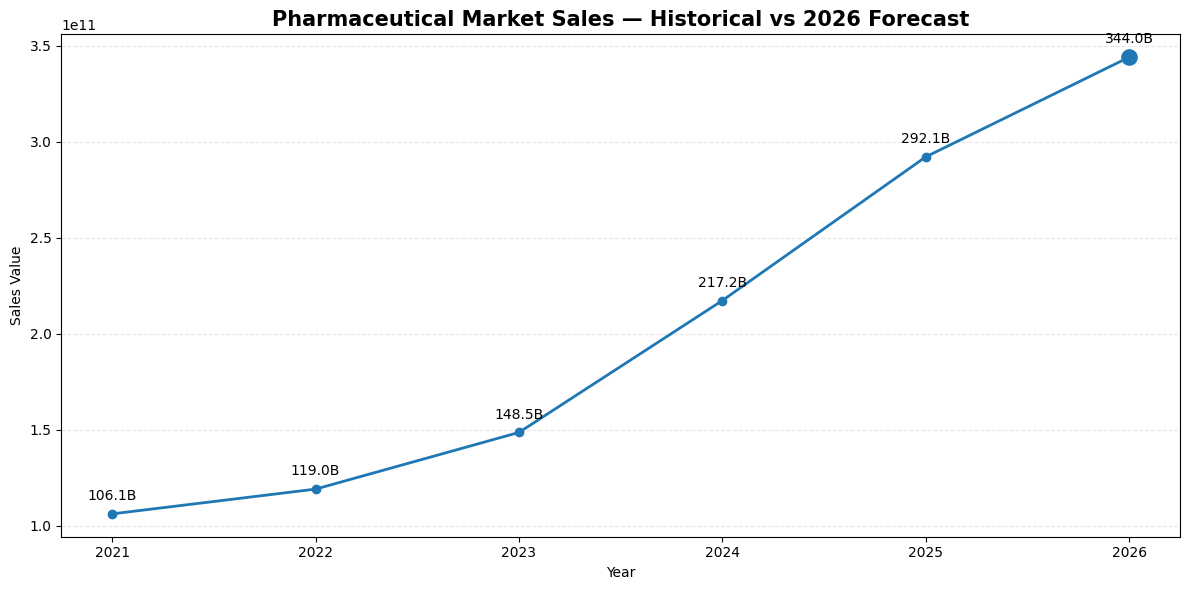

In [397]:
# ============================================================
# 3.1 PORTFOLIO SALES — HISTORICAL vs 2026 FORECAST
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Historical yearly sales
# ------------------------------------------------------------

historical_sales = yearly_sales.copy()

historical_sales.columns = ["Year", "Sales_Value"]

# ------------------------------------------------------------
# 2. Calculate 2026 forecast
# ------------------------------------------------------------

forecast_2026_total = forecast_2026_result["Forecast_2026_Sales"].sum()

print("Historical Sales:")
print(historical_sales)

print("\n2026 Forecast Sales:")
print(f"{forecast_2026_total:,.0f}")

# ------------------------------------------------------------
# 3. Create visualization dataset
# ------------------------------------------------------------

portfolio_visual = historical_sales.copy()

portfolio_visual["Type"] = "Historical"

forecast_row = pd.DataFrame({
    "Year": [2026],
    "Sales_Value": [forecast_2026_total],
    "Type": ["Forecast"]
})

portfolio_visual = pd.concat(
    [portfolio_visual, forecast_row],
    ignore_index=True
)

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_visual["Year"],
    portfolio_visual["Sales_Value"],
    marker="o",
    linewidth=2
)

# Highlight forecast point
plt.scatter(
    2026,
    forecast_2026_total,
    s=120,
    zorder=5
)

# Add value labels
for _, row in portfolio_visual.iterrows():

    value_bn = row["Sales_Value"] / 1e9

    plt.annotate(
        f"{value_bn:.1f}B",
        (row["Year"], row["Sales_Value"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

# ------------------------------------------------------------
# 5. Formatting
# ------------------------------------------------------------

plt.title(
    "Pharmaceutical Market Sales — Historical vs 2026 Forecast",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Sales Value")

plt.xticks(portfolio_visual["Year"])

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

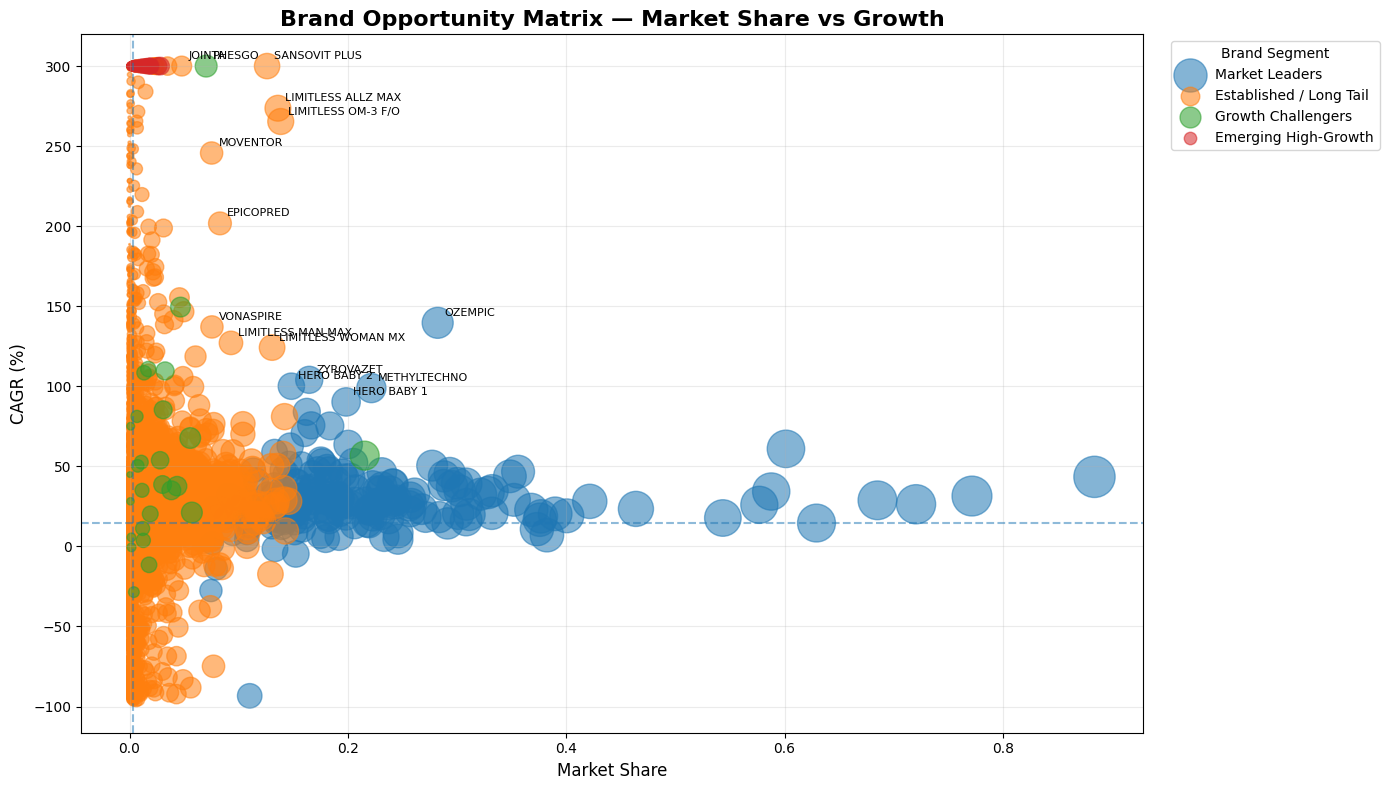

In [400]:
# ============================================================
# 3.2 BRAND OPPORTUNITY MATRIX
# Market Share vs Growth
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

matrix_data = brand_intelligence.copy()

# Keep required columns
matrix_data = matrix_data[
    [
        "Brand Name",
        "Sales_Value",
        "Market_Share",
        "CAGR",
        "Cluster_Name",
        "Strategic_Opportunity_Score",
        "Opportunity_Tier"
    ]
].copy()

# Remove invalid values
matrix_data = matrix_data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna(
    subset=[
        "Market_Share",
        "CAGR",
        "Sales_Value"
    ]
)

# ------------------------------------------------------------
# 2. Limit extreme CAGR values for visualization
# ------------------------------------------------------------

# This prevents a few extreme-growth brands from
# compressing the rest of the portfolio.

matrix_data["CAGR_Plot"] = matrix_data["CAGR"].clip(
    lower=-100,
    upper=300
)

# ------------------------------------------------------------
# 3. Create bubble sizes
# ------------------------------------------------------------

matrix_data["Bubble_Size"] = (
    np.sqrt(matrix_data["Sales_Value"]) / 100
)

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 8))

clusters = matrix_data["Cluster_Name"].unique()

for cluster in clusters:

    subset = matrix_data[
        matrix_data["Cluster_Name"] == cluster
    ]

    plt.scatter(
        subset["Market_Share"],
        subset["CAGR_Plot"],
        s=subset["Bubble_Size"],
        alpha=0.55,
        label=cluster
    )

# ------------------------------------------------------------
# 5. Add strategic quadrant lines
# ------------------------------------------------------------

median_market_share = matrix_data["Market_Share"].median()
median_cagr = matrix_data["CAGR"].median()

plt.axvline(
    median_market_share,
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    median_cagr,
    linestyle="--",
    alpha=0.5
)

# ------------------------------------------------------------
# 6. Label top strategic brands
# ------------------------------------------------------------

top_brands = matrix_data.nlargest(
    15,
    "Strategic_Opportunity_Score"
)

for _, row in top_brands.iterrows():

    plt.annotate(
        row["Brand Name"],
        (
            row["Market_Share"],
            row["CAGR_Plot"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

# ------------------------------------------------------------
# 7. Titles and labels
# ------------------------------------------------------------

plt.title(
    "Brand Opportunity Matrix — Market Share vs Growth",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Market Share",
    fontsize=12
)

plt.ylabel(
    "CAGR (%)",
    fontsize=12
)

plt.legend(
    title="Brand Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

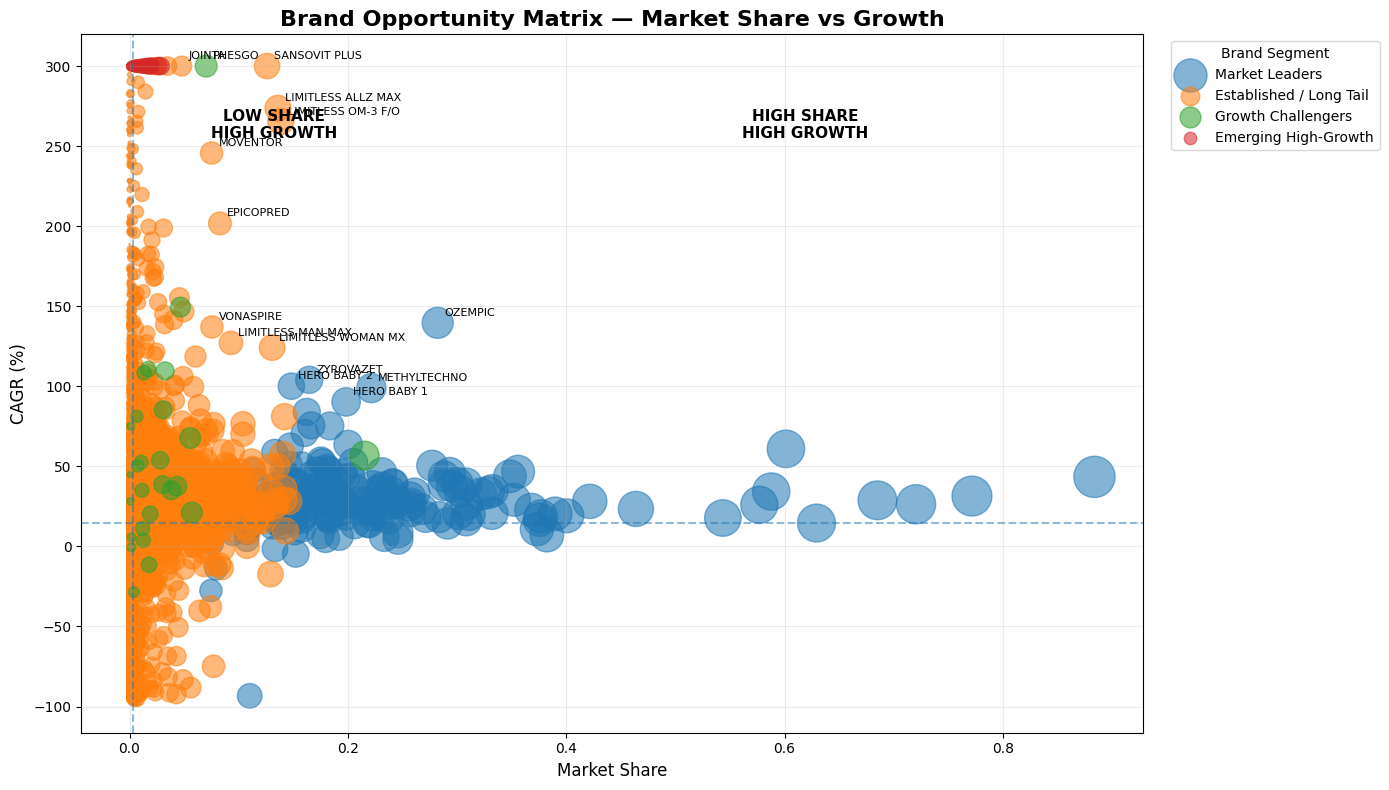

In [401]:
# ============================================================
# 3.2 BRAND OPPORTUNITY MATRIX
# Market Share vs Growth
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Start from the original brand segmentation
# ------------------------------------------------------------

matrix_data = brand_segmentation[
    [
        "Brand Name",
        "Sales_Value",
        "Market_Share",
        "CAGR",
        "Cluster_Name"
    ]
].copy()

# ------------------------------------------------------------
# 2. Add strategic opportunity information
# ------------------------------------------------------------

matrix_data = matrix_data.merge(
    opportunity_data[
        [
            "Brand Name",
            "Strategic_Opportunity_Score",
            "Opportunity_Tier"
        ]
    ],
    on="Brand Name",
    how="left"
)

# ------------------------------------------------------------
# 3. Clean data
# ------------------------------------------------------------

matrix_data = matrix_data.replace(
    [np.inf, -np.inf],
    np.nan
)

matrix_data = matrix_data.dropna(
    subset=[
        "Market_Share",
        "CAGR",
        "Sales_Value"
    ]
)

# ------------------------------------------------------------
# 4. Limit extreme CAGR values only for visualization
# ------------------------------------------------------------

matrix_data["CAGR_Plot"] = matrix_data["CAGR"].clip(
    lower=-100,
    upper=300
)

# ------------------------------------------------------------
# 5. Bubble size
# ------------------------------------------------------------

matrix_data["Bubble_Size"] = (
    np.sqrt(matrix_data["Sales_Value"]) / 100
)

# ------------------------------------------------------------
# 6. Create figure
# ------------------------------------------------------------

plt.figure(figsize=(14, 8))

# ------------------------------------------------------------
# 7. Plot each cluster
# ------------------------------------------------------------

for cluster in matrix_data["Cluster_Name"].dropna().unique():

    subset = matrix_data[
        matrix_data["Cluster_Name"] == cluster
    ]

    plt.scatter(
        subset["Market_Share"],
        subset["CAGR_Plot"],
        s=subset["Bubble_Size"],
        alpha=0.55,
        label=cluster
    )

# ------------------------------------------------------------
# 8. Strategic quadrant lines
# ------------------------------------------------------------

median_market_share = matrix_data["Market_Share"].median()
median_cagr = matrix_data["CAGR"].median()

plt.axvline(
    median_market_share,
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    median_cagr,
    linestyle="--",
    alpha=0.5
)

# ------------------------------------------------------------
# 9. Add quadrant labels
# ------------------------------------------------------------

x_min = matrix_data["Market_Share"].min()
x_max = matrix_data["Market_Share"].max()

y_min = matrix_data["CAGR_Plot"].min()
y_max = matrix_data["CAGR_Plot"].max()

plt.text(
    x_max * 0.70,
    y_max * 0.85,
    "HIGH SHARE\nHIGH GROWTH",
    fontsize=11,
    fontweight="bold",
    ha="center"
)

plt.text(
    x_max * 0.15,
    y_max * 0.85,
    "LOW SHARE\nHIGH GROWTH",
    fontsize=11,
    fontweight="bold",
    ha="center"
)

# ------------------------------------------------------------
# 10. Label Top 15 Strategic Brands
# ------------------------------------------------------------

top_brands = matrix_data.nlargest(
    15,
    "Strategic_Opportunity_Score"
)

for _, row in top_brands.iterrows():

    plt.annotate(
        row["Brand Name"],
        (
            row["Market_Share"],
            row["CAGR_Plot"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

# ------------------------------------------------------------
# 11. Formatting
# ------------------------------------------------------------

plt.title(
    "Brand Opportunity Matrix — Market Share vs Growth",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Market Share",
    fontsize=12
)

plt.ylabel(
    "CAGR (%)",
    fontsize=12
)

plt.legend(
    title="Brand Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

#| Area                         | Meaning                   |
| ---------------------------- | ------------------------- |
| **High Share + High Growth** | 🚀 Defend / Invest        |
| **Low Share + High Growth**  | 🌱 Emerging opportunities |
| **High Share + Low Growth**  | 🛡️ Defend / Optimize     |
| **Low Share + Low Growth**   | 📉 Monitor / Deprioritize |


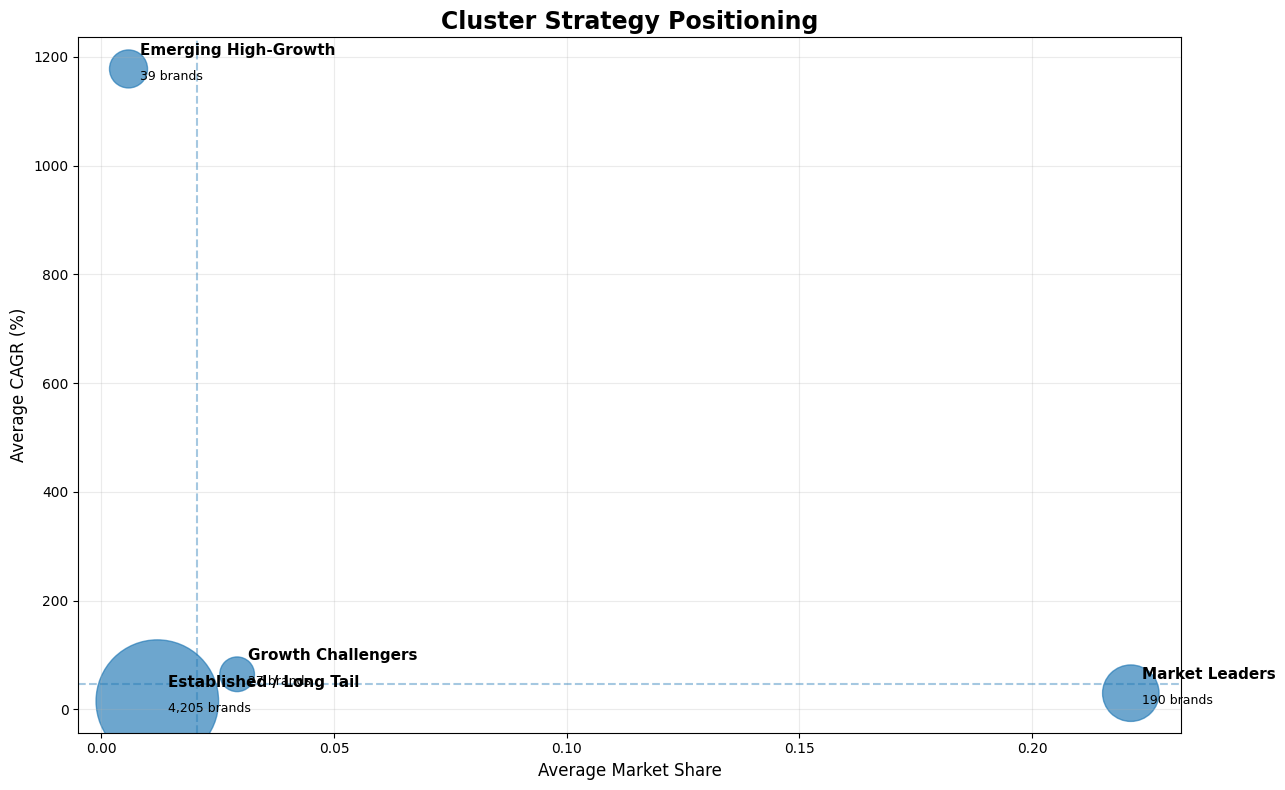

In [404]:
# ============================================================
# 3.3 CLUSTER STRATEGY POSITIONING — EXECUTIVE VERSION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Use existing cluster data
# ------------------------------------------------------------

cluster_visual = cluster_profile.copy()

cluster_visual["Cluster_Name"] = (
    cluster_visual["Cluster"].map(cluster_names)
)

# ------------------------------------------------------------
# 2. Use moderate bubble sizes
# ------------------------------------------------------------

cluster_visual["Bubble_Size"] = (
    np.sqrt(cluster_visual["Brand_Count"]) * 120
)

# ------------------------------------------------------------
# 3. Create figure
# ------------------------------------------------------------

plt.figure(figsize=(13, 8))

plt.scatter(
    cluster_visual["Avg_Market_Share"],
    cluster_visual["Avg_CAGR"],
    s=cluster_visual["Bubble_Size"],
    alpha=0.65
)

# ------------------------------------------------------------
# 4. Add cluster labels
# ------------------------------------------------------------

for _, row in cluster_visual.iterrows():

    plt.annotate(
        row["Cluster_Name"],
        (
            row["Avg_Market_Share"],
            row["Avg_CAGR"]
        ),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

    plt.annotate(
        f"{int(row['Brand_Count']):,} brands",
        (
            row["Avg_Market_Share"],
            row["Avg_CAGR"]
        ),
        xytext=(8, -8),
        textcoords="offset points",
        fontsize=9
    )

# ------------------------------------------------------------
# 5. Reference lines
# ------------------------------------------------------------

median_share = cluster_visual["Avg_Market_Share"].median()
median_growth = cluster_visual["Avg_CAGR"].median()

plt.axvline(
    median_share,
    linestyle="--",
    alpha=0.4
)

plt.axhline(
    median_growth,
    linestyle="--",
    alpha=0.4
)

# ------------------------------------------------------------
# 6. Titles
# ------------------------------------------------------------

plt.title(
    "Cluster Strategy Positioning",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Average Market Share",
    fontsize=12
)

plt.ylabel(
    "Average CAGR (%)",
    fontsize=12
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

#The portfolio is highly concentrated in an established long-tail segment, while a small number of Growth Challengers and Emerging High-Growth brands represent targeted expansion opportunities.

C:\Users\lapshop\AppData\Local\Temp\ipykernel_4628\89050433.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Opportunity_Tier")


        Opportunity_Tier  Brand_Count
0           Low Priority         1116
1                Monitor         1115
2  Strategic Opportunity         1115
3          High Priority         1115


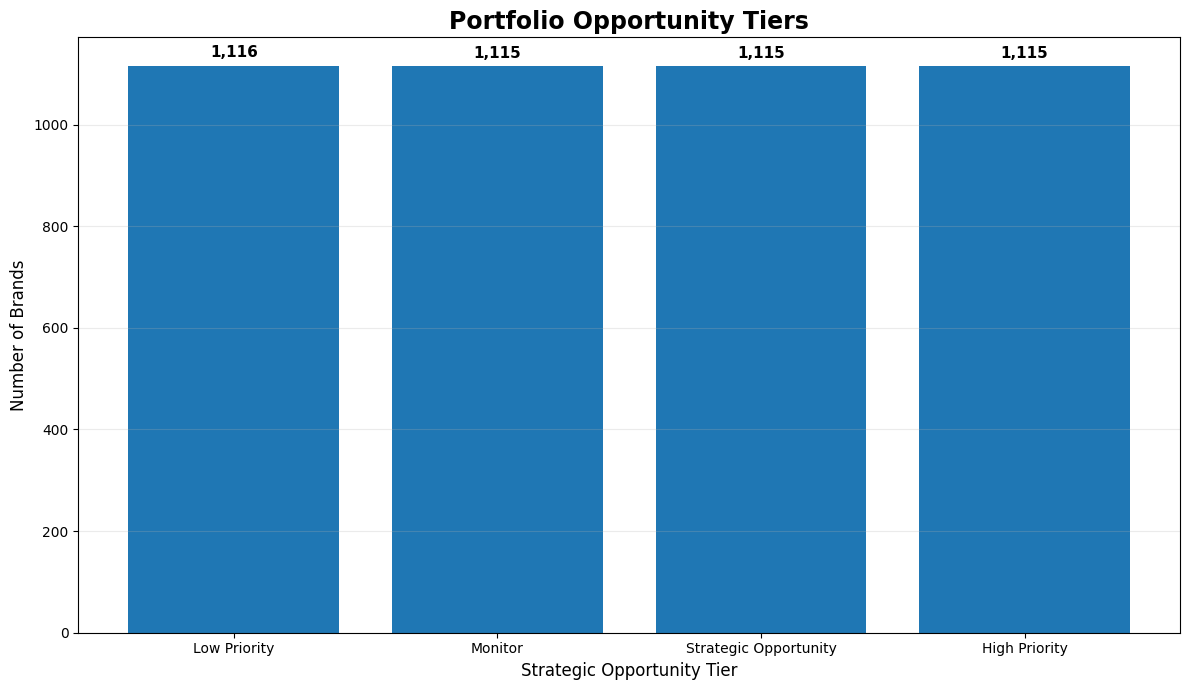

In [405]:
# ============================================================
# 3.4 OPPORTUNITY TIER & STRATEGIC ACTION
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Prepare opportunity data
# ------------------------------------------------------------

opportunity_visual = opportunity_data[
    [
        "Brand Name",
        "Strategic_Opportunity_Score",
        "Opportunity_Tier"
    ]
].copy()

# ------------------------------------------------------------
# 2. Count brands by opportunity tier
# ------------------------------------------------------------

tier_summary = (
    opportunity_visual
    .groupby("Opportunity_Tier")
    .size()
    .reset_index(name="Brand_Count")
)

# ------------------------------------------------------------
# 3. Keep strategic order
# ------------------------------------------------------------

tier_order = [
    "Low Priority",
    "Monitor",
    "Strategic Opportunity",
    "High Priority"
]

tier_summary["Opportunity_Tier"] = pd.Categorical(
    tier_summary["Opportunity_Tier"],
    categories=tier_order,
    ordered=True
)

tier_summary = tier_summary.sort_values(
    "Opportunity_Tier"
)

print(tier_summary)

# ------------------------------------------------------------
# 4. Create visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.bar(
    tier_summary["Opportunity_Tier"],
    tier_summary["Brand_Count"]
)

# ------------------------------------------------------------
# 5. Add values on bars
# ------------------------------------------------------------

for bar in bars:

    height = bar.get_height()

    plt.annotate(
        f"{int(height):,}",
        (
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# ------------------------------------------------------------
# 6. Formatting
# ------------------------------------------------------------

plt.title(
    "Portfolio Opportunity Tiers",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Strategic Opportunity Tier",
    fontsize=12
)

plt.ylabel(
    "Number of Brands",
    fontsize=12
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

       Strategic_Action  Brand_Count
4  Selective Investment         1982
2          Deprioritize         1139
3               Monitor         1115
1       Defend & Invest          169
5      Validate & Scale           39
0            Accelerate           17


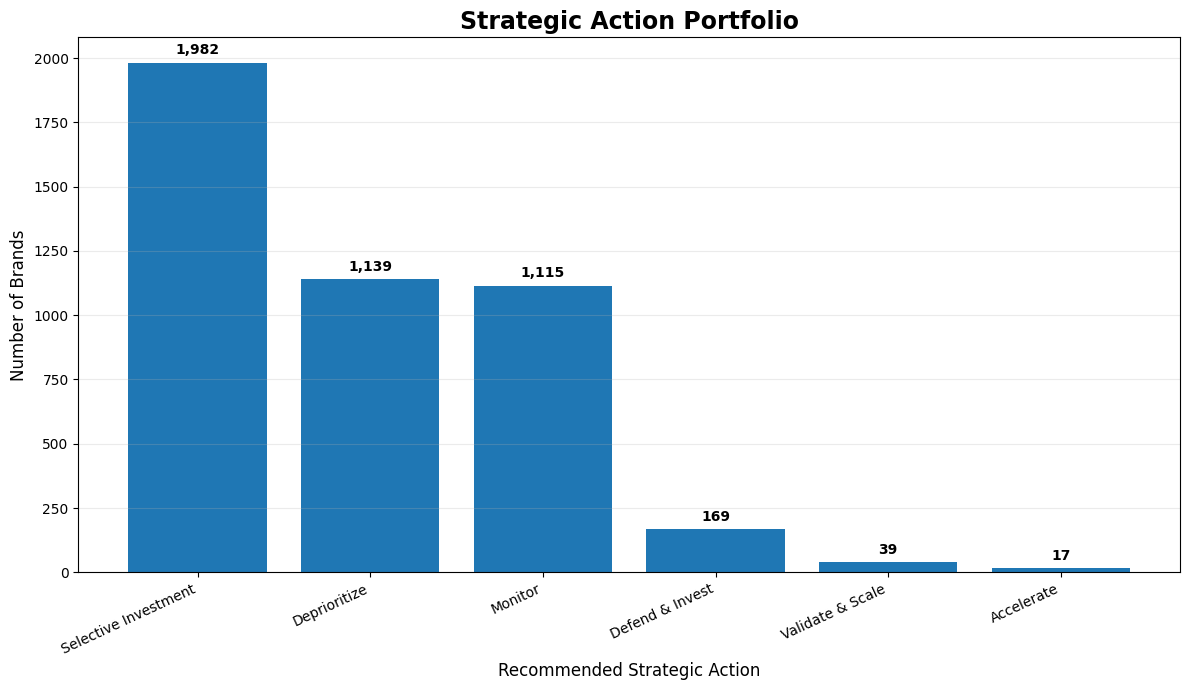

In [406]:
# ============================================================
# 3.4B STRATEGIC ACTION PORTFOLIO
# ============================================================

action_summary = (
    cluster_opportunity_data
    .groupby("Strategic_Action")
    .size()
    .reset_index(name="Brand_Count")
    .sort_values(
        "Brand_Count",
        ascending=False
    )
)

print(action_summary)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.bar(
    action_summary["Strategic_Action"],
    action_summary["Brand_Count"]
)

# Add labels
for bar in bars:

    height = bar.get_height()

    plt.annotate(
        f"{int(height):,}",
        (
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Strategic Action Portfolio",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Recommended Strategic Action",
    fontsize=12
)

plt.ylabel(
    "Number of Brands",
    fontsize=12
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

In [407]:
# ============================================================
# 3.4 TOP 20 STRATEGIC BRANDS
# Current Sales vs 2026 Forecast
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Prepare Top 20
# ------------------------------------------------------------

top20_viz = brand_forecast_strategy.copy()

# Sort by 2026 forecast sales
top20_viz = (
    top20_viz
    .sort_values(
        "Forecast_2026_Sales",
        ascending=False
    )
    .head(20)
    .copy()
)

# Sort for horizontal bar chart
top20_viz = top20_viz.sort_values(
    "Forecast_2026_Sales",
    ascending=True
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(top20_viz))

bar_height = 0.38

# Current sales
ax.barh(
    y - bar_height / 2,
    top20_viz["Lag_1"] / 1e6,
    height=bar_height,
    label="2025 Sales"
)

# Forecast sales
ax.barh(
    y + bar_height / 2,
    top20_viz["Forecast_2026_Sales"] / 1e6,
    height=bar_height,
    label="2026 Forecast"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    top20_viz["Brand Name"],
    fontsize=9
)

ax.set_xlabel(
    "Sales Value (Million)",
    fontsize=12
)

ax.set_title(
    "Top 20 Strategic Brands: 2025 Sales vs 2026 Forecast",
    fontsize=16,
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

NameError: name 'brand_forecast_strategy' is not defined

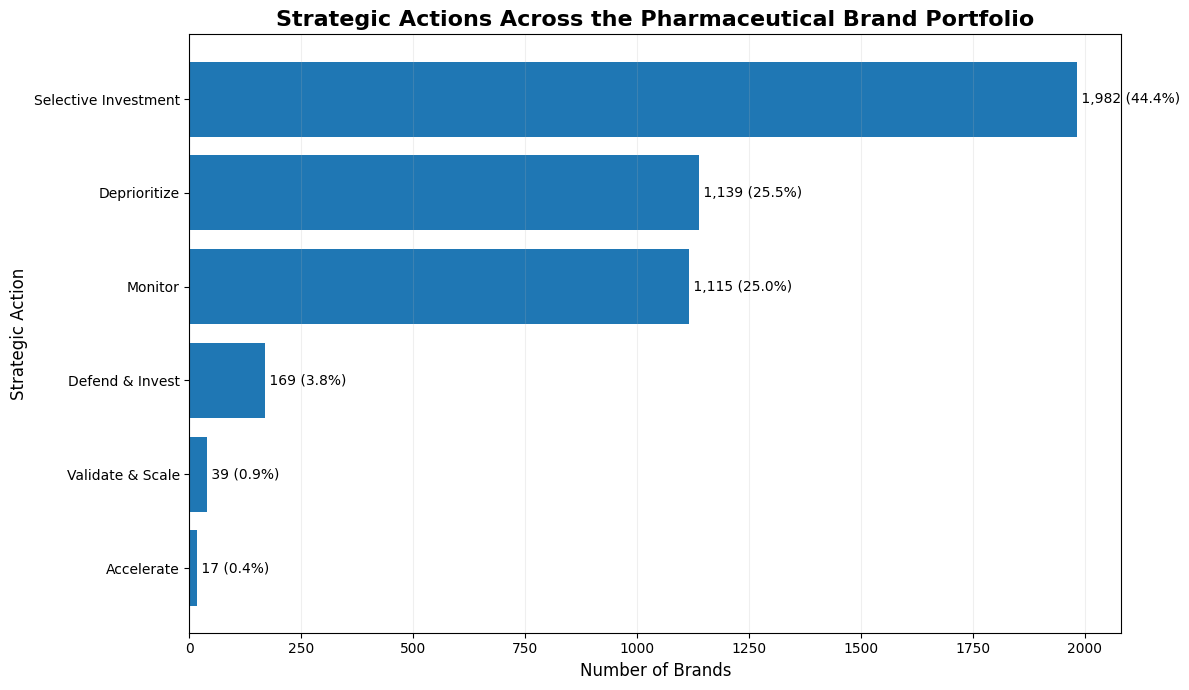

In [408]:
# ============================================================
# 3.5 STRATEGIC ACTION DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

# Count strategic actions
action_counts = (
    brand_intelligence["Strategic_Action"]
    .value_counts()
    .sort_values(ascending=True)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.barh(
    action_counts.index,
    action_counts.values
)

# Add percentage labels
total_brands = action_counts.sum()

for bar, value in zip(bars, action_counts.values):

    percentage = (
        value / total_brands
    ) * 100

    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:,} ({percentage:.1f}%)",
        va="center",
        fontsize=10
    )

plt.title(
    "Strategic Actions Across the Pharmaceutical Brand Portfolio",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Brands",
    fontsize=12
)

plt.ylabel(
    "Strategic Action",
    fontsize=12
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 3.6 OPPORTUNITY TIER × CLUSTER HEATMAP
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Create cross-tabulation
# ------------------------------------------------------------

heatmap_data = pd.crosstab(
    brand_intelligence["Cluster_Name"],
    brand_intelligence["Opportunity_Tier"]
)

# ------------------------------------------------------------
# Order rows and columns strategically
# ------------------------------------------------------------

cluster_order = [
    "Market Leaders",
    "Growth Challengers",
    "Emerging High-Growth",
    "Established / Long Tail"
]

tier_order = [
    "Low Priority",
    "Monitor",
    "Strategic Opportunity",
    "High Priority"
]

heatmap_data = heatmap_data.reindex(
    index=cluster_order,
    columns=tier_order,
    fill_value=0
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 7)
)

im = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(len(tier_order))
)

ax.set_xticklabels(
    tier_order,
    rotation=25,
    ha="right"
)

ax.set_yticks(
    np.arange(len(cluster_order))
)

ax.set_yticklabels(
    cluster_order
)

# ------------------------------------------------------------
# Add values inside cells
# ------------------------------------------------------------

for i in range(
    heatmap_data.shape[0]
):

    for j in range(
        heatmap_data.shape[1]
    ):

        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Titles
# ------------------------------------------------------------

ax.set_title(
    "Brand Portfolio: Opportunity Tier by Strategic Cluster",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Opportunity Tier",
    fontsize=12
)

ax.set_ylabel(
    "Strategic Cluster",
    fontsize=12
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 3.7 STRATEGIC OPPORTUNITY SCORE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

score_data = brand_intelligence[
    "Strategic_Opportunity_Score"
].dropna()

plt.figure(figsize=(12, 7))

plt.hist(
    score_data,
    bins=30,
    alpha=0.75
)

# ------------------------------------------------------------
# Strategic thresholds
# ------------------------------------------------------------

plt.axvline(
    25,
    linestyle="--",
    linewidth=2,
    label="Low Priority Threshold"
)

plt.axvline(
    50,
    linestyle="--",
    linewidth=2,
    label="Strategic Opportunity Threshold"
)

plt.axvline(
    75,
    linestyle="--",
    linewidth=2,
    label="High Priority Threshold"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.title(
    "Distribution of Strategic Opportunity Scores",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Strategic Opportunity Score",
    fontsize=12
)

plt.ylabel(
    "Number of Brands",
    fontsize=12
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

#How many brands are expected to grow vs decline in 2026?

In [410]:
# ============================================================
# 3.8 2026 FORECAST GROWTH DISTRIBUTION
# ============================================================

growth_data = brand_forecast_strategy[
    "Forecast_Growth_2026"
].dropna()

plt.figure(figsize=(12, 7))

plt.hist(
    growth_data,
    bins=40,
    alpha=0.75
)

# Zero-growth reference
plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="No Growth"
)

# Median growth
median_growth = growth_data.median()

plt.axvline(
    median_growth,
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_growth:.1f}%"
)

plt.title(
    "Expected Brand Growth Distribution — 2026 Forecast",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Forecast Growth (%)",
    fontsize=12
)

plt.ylabel(
    "Number of Brands",
    fontsize=12
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

NameError: name 'brand_forecast_strategy' is not defined

In [411]:
# Check available DataFrames
[df for df in globals() if isinstance(globals()[df], pd.DataFrame)]

['__',
 'df',
 '_7',
 '_8',
 '_9',
 '_15',
 'manufacturer_sales',
 '_18',
 '_20',
 'top10',
 'therapeutic_sales',
 '_23',
 'brand_sales',
 '_25',
 'channel_sales',
 '_27',
 'launches',
 '_34',
 '_36',
 'monthly_units',
 'yearly_sales',
 '_40',
 'market_yoy',
 '_42',
 '_43',
 'manufacturer_year',
 'manufacturer_pivot',
 '_46',
 'maufacturer_pivot',
 'manufacturer_yoy',
 '_48',
 'eligible_pivot',
 'cagr_df',
 'top15',
 'market_share',
 'rising_star_1',
 '_63',
 '_64',
 'last_yoy_df',
 'rising_star_2',
 '_67',
 '_68',
 '_71',
 'brand_pareto',
 '_75',
 '_77',
 'abc_summary',
 '_78',
 'pareto_plot',
 'brands_80',
 '_80',
 'top_A_brands',
 '_84',
 'comparison',
 '_96',
 'lr_train',
 'X_train',
 'lr_test',
 'rf_data',
 '_104',
 'X_train_rf',
 'current_features',
 'full_data',
 '_111',
 'rf_full',
 '_112',
 'X_full',
 'forecast_2026',
 '_115',
 'brand_metrics',
 '_119',
 '_120',
 'brand_year',
 'brand_pivot',
 'brand_cagr',
 '_121',
 'brand_segmentation',
 '_122',
 'X',
 '_124',
 '_126',
 'clu

brand_2026_intelligence:
['Brand Name', 'Lag_1', 'Forecast_2026_Sales', 'Forecast_Growth_2026', 'Market_Share', 'CAGR', 'Cluster_Name', 'Strategic_Opportunity_Score', 'Opportunity_Tier', 'Strategic_Action']

strategic_2026:
['Brand Name', 'Lag_1', 'Forecast_2026_Sales', 'Forecast_Growth_2026', 'Market_Share', 'CAGR', 'Cluster_Name', 'Strategic_Opportunity_Score', 'Opportunity_Tier', 'Strategic_Action', 'Forecast_Growth_Capped', 'Current_Sales_Score', 'Forecast_Sales_Score', 'Forecast_Growth_Score', 'Market_Share_Score', 'Historical_Growth_Score', 'Strategic_2026_Score', 'Strategic_2026_Tier']

portfolio_summary:
['Strategic_2026_Tier', 'Strategic_Action', 'Brand_Count', 'Current_Sales', 'Forecast_2026_Sales', 'Avg_Forecast_Growth', 'Avg_Market_Share', 'Avg_Strategic_Score']

top_20_strategic:
['Brand Name', 'Lag_1', 'Forecast_2026_Sales', 'Forecast_Growth_2026', 'Market_Share', 'CAGR', 'Cluster_Name', 'Strategic_2026_Score', 'Strategic_2026_Tier', 'Strategic_Action']

Forecast columns 

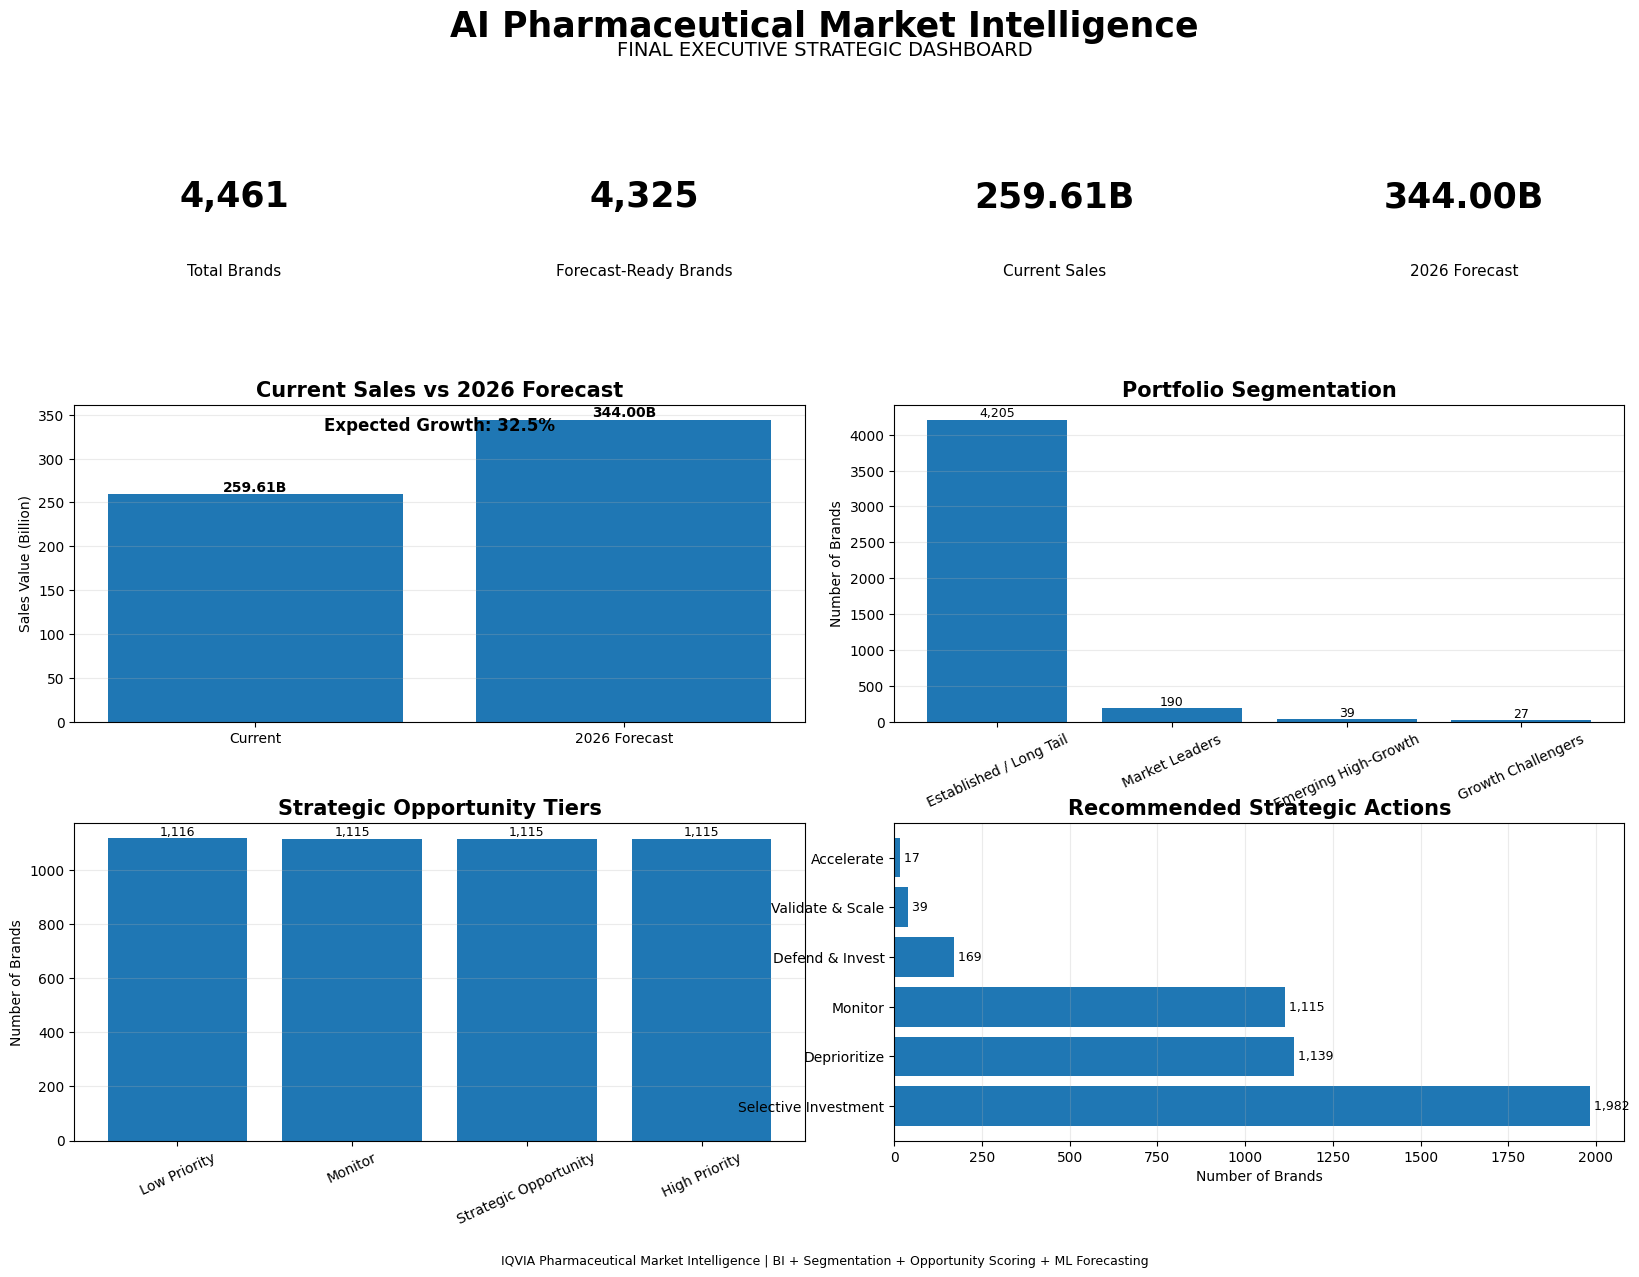

In [413]:
# ============================================================
# 3.9 FINAL EXECUTIVE STRATEGIC DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. INSPECT FINAL DATASETS
# ============================================================

print("brand_2026_intelligence:")
print(brand_2026_intelligence.columns.tolist())

print("\nstrategic_2026:")
print(strategic_2026.columns.tolist())

print("\nportfolio_summary:")
print(portfolio_summary.columns.tolist())

print("\ntop_20_strategic:")
print(top_20_strategic.columns.tolist())


# ============================================================
# 2. PREPARE FORECAST DATA
# ============================================================

forecast_df = brand_2026_intelligence.copy()

# Find forecast column automatically
forecast_columns = [
    col for col in forecast_df.columns
    if "forecast" in col.lower()
]

print("\nForecast columns found:", forecast_columns)


# ============================================================
# 3. CURRENT SALES
# ============================================================

current_columns = [
    "Lag_1",
    "Sales_2025",
    "Current_Sales",
    "Sales"
]

current_col = None

for col in current_columns:
    if col in forecast_df.columns:
        current_col = col
        break

if current_col is not None:
    current_sales = forecast_df[current_col].sum()
else:
    current_sales = np.nan


# ============================================================
# 4. 2026 FORECAST SALES
# ============================================================

forecast_col = None

# Prefer exact forecast columns
preferred_forecast_columns = [
    "Forecast_2026",
    "Forecast",
    "Predicted_Sales_2026",
    "Sales_2026"
]

for col in preferred_forecast_columns:
    if col in forecast_df.columns:
        forecast_col = col
        break

# If exact name not found, use first column containing forecast
if forecast_col is None and len(forecast_columns) > 0:
    forecast_col = forecast_columns[0]

if forecast_col is not None:
    forecast_sales = forecast_df[forecast_col].sum()
else:
    forecast_sales = np.nan


# ============================================================
# 5. FORECAST GROWTH
# ============================================================

if (
    pd.notna(current_sales)
    and pd.notna(forecast_sales)
    and current_sales != 0
):

    forecast_growth = (
        (forecast_sales - current_sales)
        / current_sales
    ) * 100

else:

    forecast_growth = np.nan


# ============================================================
# 6. BRAND COUNT
# ============================================================

total_brands = len(brand_intelligence)

forecast_ready_brands = len(
    forecast_df
)


# ============================================================
# 7. OPPORTUNITY DATA
# ============================================================

opportunity_df = None

if "Opportunity_Tier" in brand_intelligence.columns:

    opportunity_df = brand_intelligence.copy()

elif "Opportunity_Tier" in strategic_2026.columns:

    opportunity_df = strategic_2026.copy()


if opportunity_df is not None:

    tier_summary_final = (
        opportunity_df["Opportunity_Tier"]
        .value_counts()
        .sort_values(ascending=False)
    )

else:

    tier_summary_final = pd.Series(dtype=float)


# ============================================================
# 8. STRATEGIC ACTION DATA
# ============================================================

if (
    opportunity_df is not None
    and "Strategic_Action" in opportunity_df.columns
):

    action_summary_final = (
        opportunity_df["Strategic_Action"]
        .value_counts()
        .sort_values(ascending=False)
    )

else:

    action_summary_final = pd.Series(dtype=float)


# ============================================================
# 9. CLUSTER DATA
# ============================================================

cluster_col = None

for col in [
    "Cluster_Name",
    "Cluster",
    "Cluster_Label",
    "Segment",
    "Brand_Segment"
]:

    if col in brand_intelligence.columns:
        cluster_col = col
        break

if cluster_col is not None:

    cluster_summary_final = (
        brand_intelligence[cluster_col]
        .value_counts()
        .sort_values(ascending=False)
    )

else:

    cluster_summary_final = pd.Series(dtype=float)


# ============================================================
# 10. CREATE EXECUTIVE DASHBOARD
# ============================================================

fig = plt.figure(
    figsize=(20, 13)
)

gs = fig.add_gridspec(
    3,
    4,
    height_ratios=[0.75, 1.45, 1.45],
    hspace=0.38,
    wspace=0.28
)


# ============================================================
# 11. DASHBOARD TITLE
# ============================================================

fig.suptitle(
    "AI Pharmaceutical Market Intelligence",
    fontsize=25,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.945,
    "FINAL EXECUTIVE STRATEGIC DASHBOARD",
    ha="center",
    fontsize=14
)


# ============================================================
# 12. KPI CARDS
# ============================================================

kpi_titles = [
    "Total Brands",
    "Forecast-Ready Brands",
    "Current Sales",
    "2026 Forecast"
]

kpi_values = [
    f"{total_brands:,}",
    f"{forecast_ready_brands:,}",
    (
        f"{current_sales / 1e9:.2f}B"
        if pd.notna(current_sales)
        else "N/A"
    ),
    (
        f"{forecast_sales / 1e9:.2f}B"
        if pd.notna(forecast_sales)
        else "N/A"
    )
]

for i in range(4):

    ax = fig.add_subplot(gs[0, i])

    ax.axis("off")

    ax.text(
        0.5,
        0.65,
        kpi_values[i],
        ha="center",
        va="center",
        fontsize=25,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.20,
        kpi_titles[i],
        ha="center",
        va="center",
        fontsize=11
    )


# ============================================================
# 13. CURRENT VS FORECAST
# ============================================================

ax1 = fig.add_subplot(
    gs[1, :2]
)

if (
    pd.notna(current_sales)
    and pd.notna(forecast_sales)
):

    values = [
        current_sales / 1e9,
        forecast_sales / 1e9
    ]

    labels = [
        "Current",
        "2026 Forecast"
    ]

    bars = ax1.bar(
        labels,
        values
    )

    ax1.set_title(
        "Current Sales vs 2026 Forecast",
        fontsize=15,
        fontweight="bold"
    )

    ax1.set_ylabel(
        "Sales Value (Billion)"
    )

    for bar, value in zip(
        bars,
        values
    ):

        ax1.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}B",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    if pd.notna(forecast_growth):

        ax1.text(
            0.5,
            0.92,
            f"Expected Growth: {forecast_growth:.1f}%",
            transform=ax1.transAxes,
            ha="center",
            fontsize=12,
            fontweight="bold"
        )

    ax1.grid(
        axis="y",
        alpha=0.25
    )

else:

    ax1.text(
        0.5,
        0.5,
        "Sales forecast data unavailable",
        ha="center",
        va="center"
    )

    ax1.axis("off")


# ============================================================
# 14. PORTFOLIO SEGMENTATION
# ============================================================

ax2 = fig.add_subplot(
    gs[1, 2:]
)

if len(cluster_summary_final) > 0:

    bars = ax2.bar(
        cluster_summary_final.index.astype(str),
        cluster_summary_final.values
    )

    ax2.set_title(
        "Portfolio Segmentation",
        fontsize=15,
        fontweight="bold"
    )

    ax2.set_ylabel(
        "Number of Brands"
    )

    ax2.tick_params(
        axis="x",
        rotation=25
    )

    for bar in bars:

        ax2.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax2.grid(
        axis="y",
        alpha=0.25
    )

else:

    ax2.text(
        0.5,
        0.5,
        "Cluster data unavailable",
        ha="center",
        va="center"
    )

    ax2.axis("off")


# ============================================================
# 15. OPPORTUNITY TIERS
# ============================================================

ax3 = fig.add_subplot(
    gs[2, :2]
)

if len(tier_summary_final) > 0:

    bars = ax3.bar(
        tier_summary_final.index.astype(str),
        tier_summary_final.values
    )

    ax3.set_title(
        "Strategic Opportunity Tiers",
        fontsize=15,
        fontweight="bold"
    )

    ax3.set_ylabel(
        "Number of Brands"
    )

    ax3.tick_params(
        axis="x",
        rotation=25
    )

    for bar in bars:

        ax3.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax3.grid(
        axis="y",
        alpha=0.25
    )

else:

    ax3.text(
        0.5,
        0.5,
        "Opportunity data unavailable",
        ha="center",
        va="center"
    )

    ax3.axis("off")


# ============================================================
# 16. STRATEGIC ACTIONS
# ============================================================

ax4 = fig.add_subplot(
    gs[2, 2:]
)

if len(action_summary_final) > 0:

    bars = ax4.barh(
        action_summary_final.index.astype(str),
        action_summary_final.values
    )

    ax4.set_title(
        "Recommended Strategic Actions",
        fontsize=15,
        fontweight="bold"
    )

    ax4.set_xlabel(
        "Number of Brands"
    )

    for bar in bars:

        ax4.text(
            bar.get_width(),
            bar.get_y()
            + bar.get_height() / 2,
            f" {int(bar.get_width()):,}",
            va="center",
            fontsize=9
        )

    ax4.grid(
        axis="x",
        alpha=0.25
    )

else:

    ax4.text(
        0.5,
        0.5,
        "Strategic action data unavailable",
        ha="center",
        va="center"
    )

    ax4.axis("off")


# ============================================================
# 17. FOOTER
# ============================================================

fig.text(
    0.5,
    0.015,
    "IQVIA Pharmaceutical Market Intelligence | "
    "BI + Segmentation + Opportunity Scoring + ML Forecasting",
    ha="center",
    fontsize=9
)

plt.show()

#One dashboard containing:

KPIs

Total brands
Forecast-ready brands
Current sales
2026 forecast
Expected growth
High-priority brands

Strategic views

Top 10 forecast brands
Strategic actions
Historical → 2026 forecast
Opportunity tiers

# Executive Conclusion

The AI Pharmaceutical Market Intelligence analysis provides a comprehensive, data-driven view of the Egyptian pharmaceutical market, combining historical market performance, brand segmentation, opportunity scoring, strategic classification, and machine learning-based forecasting.

The analysis covers **4,461 pharmaceutical brands**, of which **4,325 brands (97.0%)** were sufficiently supported by the available data for forecasting and forward-looking strategic analysis.

The market demonstrates a strong positive outlook. Historical and machine learning analysis projects total portfolio sales to increase from approximately **259.61 billion** in the current period to approximately **344.00 billion in 2026**, representing an estimated **32.5% growth**. This indicates a substantial expansion opportunity, while also highlighting the importance of identifying which brands and segments are most capable of capturing this growth.

Portfolio segmentation reveals a highly concentrated structure. The **Established / Long Tail** segment contains approximately **4,205 brands**, while the portfolio also includes **190 Market Leaders**, **39 Emerging High-Growth brands**, and **27 Growth Challengers**. This structure suggests that strategic resources should not be distributed equally across the entire portfolio. Instead, investment decisions should be differentiated according to each brand's market position, growth potential, and strategic opportunity.

The opportunity-scoring framework further classifies brands into four strategic tiers: **Low Priority, Monitor, Strategic Opportunity, and High Priority**. This provides management with a practical mechanism for prioritizing commercial resources and identifying brands that warrant deeper investment, protection, or monitoring.

The strategic action framework translates the analytical results into actionable business recommendations. The largest group is assigned to **Selective Investment**, followed by **Deprioritize** and **Monitor**, while a smaller group of brands receives a **Defend & Invest** recommendation. Additional high-potential brands are identified for **Validate & Scale** and **Accelerate** strategies. This demonstrates that the portfolio requires a differentiated strategy rather than a one-size-fits-all approach.

From a management perspective, the key strategic implication is that **future growth should be pursued through targeted portfolio optimization rather than broad-based investment**. Market Leaders should be protected and strengthened, high-growth opportunities should receive focused investment and validation, established long-tail brands should be managed selectively, and low-opportunity brands should be deprioritized where appropriate.

The combination of **Business Intelligence, Brand Segmentation, Opportunity Scoring, and Machine Learning Forecasting** transforms the project from a descriptive market analysis into a forward-looking decision-support framework. The resulting intelligence can support portfolio planning, resource allocation, brand investment decisions, commercial prioritization, and future market strategy.

## Final Strategic Message

**The pharmaceutical market shows strong projected growth, but the greatest value will come from knowing where to invest, where to defend, where to scale, and where to reduce resources.**

The developed AI-driven framework provides a structured approach for making these decisions based on market evidence rather than intuition alone.
